# CIRCL-E — Semantic Mapping
## Interpretasi struktur Discovery tanpa mengubah membership numerik

Notebook ini memberi makna semantik pada hasil Discovery yang sudah dibekukan. Keputusan semantik disimpan sebagai registry eksplisit sehingga mudah diaudit, di-diff, dan digunakan ulang tanpa mempertahankan ratusan cell assignment individual.

**Kontrak utama:**

- ID dan membership parent/fine/raw tidak diubah.
- ICA dan patch scores tetap kontinu; interpretasi tidak mengubah nilainya.
- `unknown_mixed` tetap abstain secara operasional.
- Raw visual leaf hanya menjadi bukti deskriptif dan tidak dapat meningkatkan parent-only case menjadi fine semantic case.
- PCA, t-SNE, hierarchy, dan similarity matrix hanya untuk komunikasi.

Nama kolom, semantic key, label, serta struktur file yang digunakan downstream dipertahankan untuk kompatibilitas.


In [1]:
# Konfigurasi, import, direktori output, dan helper review.
from pathlib import Path
import hashlib
import json
import math
import os
import re
import shutil
import textwrap
import time
import warnings
import zipfile

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Image as IPyImage, Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, FancyBboxPatch, PathPatch
from matplotlib.path import Path as MplPath
from PIL import Image

pd.set_option('display.max_colwidth', 180)
pd.set_option('display.width', 220)
warnings.filterwarnings('ignore', category=FutureWarning)

display(HTML("""
<style>
.jp-Notebook { max-width: 1800px !important; }
.container { width: 96% !important; }
.dataframe { font-size: 14px !important; }
</style>
"""))

PROJECT_ROOT = Path(os.getenv('CIRCLE_STAGE2_ROOT', str(Path.cwd()))).expanduser().resolve()
OUT = PROJECT_ROOT / 'CIRCL_E_STAGE2_EVIDENCE_FIRST_ARTIFACTS'
RUNTIME = PROJECT_ROOT / '.circl_e_runtime' / 'semantic_mapping'
FROZEN = RUNTIME / 'frozen_handoff'

# Output Stage-2 dibangun ulang dari nol agar file dari run lama tidak tercampur.
if OUT.exists():
    shutil.rmtree(OUT)
for directory in [OUT / 'mapping', OUT / 'exports', OUT / 'ontology', OUT / 'figures', OUT / 'report', RUNTIME]:
    directory.mkdir(parents=True, exist_ok=True)

# Review montage bersifat opsional karena keputusan semantik sudah dibekukan di registry.
RENDER_REVIEW_EVIDENCE = os.getenv('CIRCLE_RENDER_REVIEW_EVIDENCE', '0') == '1'
LIGHTWEIGHT_RENDER = os.getenv('CIRCLE_LIGHTWEIGHT_RENDER', '0') == '1'
STRICT_DISCOVERY_ZIP_SHA = os.getenv('CIRCLE_STRICT_DISCOVERY_ZIP_SHA', '0') == '1'
EXPECTED_DISCOVERY_ZIP_SHA256 = '92941e821f208a83845da9026a7d4f38b1cd56d9e28935798a31152a47ac47ab'

FROZEN_READY = False


def file_sha256(path, block_size=1 << 20):
    h = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(block_size), b''):
            h.update(block)
    return h.hexdigest()


def _require_frozen_loaded():
    if not FROZEN_READY:
        raise RuntimeError('Handoff Discovery belum dimuat. Jalankan bagian input Stage-1 terlebih dahulu.')


def _display_img(path, width=1550):
    _require_frozen_loaded()
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Bukti visual tidak ditemukan: {path}')
    display(IPyImage(filename=str(path), width=width))


def _metric_table(df, cols=None, digits=3):
    if df is None or len(df) == 0:
        display(Markdown('*Tidak ada baris metrik untuk item ini.*'))
        return
    table = df.copy()
    if cols is not None:
        table = table[[c for c in cols if c in table.columns]]
    numeric = table.select_dtypes(include=[np.number]).columns
    table[numeric] = table[numeric].round(digits)
    display(table.reset_index(drop=True))


def review_parent(parent_id):
    _require_frozen_loaded()
    display(Markdown(f'### P{parent_id:02d} — broad parent'))
    _display_img(FROZEN / f'review/parents/parent_{parent_id:02d}.jpg', width=1580)
    _metric_table(
        PARENT_REL[PARENT_REL.parent_id == parent_id],
        ['parent_id', 'n', 'withholding_recall', 'withholding_precision', 'withholding_f1',
         'operational_reliability', 'residual_parent'],
    )


def review_fine(fine_id):
    _require_frozen_loaded()
    assoc = FINE_ASSOC[FINE_ASSOC.validated_fine_group_id == fine_id]
    if len(assoc) != 1:
        raise KeyError(f'Asosiasi fine group {fine_id} tidak unik.')
    assoc = assoc.iloc[0]
    parent_id, child_id = int(assoc.parent_id), int(assoc.local_child_id)
    display(Markdown(f'### F{fine_id:02d} — fine group di P{parent_id:02d}'))
    _display_img(FROZEN / f'review/fine/fine_{fine_id:03d}.jpg', width=1580)
    _metric_table(
        FINE_VAL[(FINE_VAL.parent == parent_id) & (FINE_VAL.local_child == child_id)],
        ['parent', 'local_child', 'n', 'survival_median', 'survival_q10', 'withholding_recall',
         'cross_view_median', 'cross_view_q10', 'accepted'],
    )


def review_raw_leaf(leaf_id):
    _require_frozen_loaded()
    assoc = RAW_ASSOC[RAW_ASSOC.raw_visual_leaf_id == leaf_id]
    if len(assoc) != 1:
        raise KeyError(f'Asosiasi raw visual leaf {leaf_id} tidak unik.')
    parent_id = int(assoc.iloc[0].parent_id)
    display(Markdown(f'### L{leaf_id:02d} — raw visual leaf di P{parent_id:02d}'))
    _display_img(FROZEN / f'review/raw_visual/visual_{leaf_id:03d}.jpg', width=1580)
    _metric_table(
        RAW_CAND[(RAW_CAND.parent == parent_id) & (RAW_CAND.selected == True)],
        ['parent', 'view', 'k', 'silhouette', 'seed_ari', 'group_ari_q10', 'nuisance_bal_acc',
         'nuisance_excess', 'routing_macro', 'cross_view_median', 'cross_view_q10', 'selected'],
    )


def review_global_factor(factor_id):
    _require_frozen_loaded()
    display(Markdown(f'### G{factor_id:02d} — global ICA'))
    _display_img(FROZEN / f'review/global_attributes/global_ica_f{factor_id:02d}.jpg', width=1720)
    _metric_table(
        GLOBAL_MET[GLOBAL_MET.factor == factor_id],
        ['factor', 'bootstrap_match_median', 'bootstrap_match_q10', 'stable', 'eta2_parent',
         'eta2_validated_fine', 'eta2_raw_visual', 'nuisance_r2', 'candidate_for_interpretation'],
    )


def review_family_factor(parent_id, factor_id):
    _require_frozen_loaded()
    display(Markdown(f'### P{parent_id:02d}/f{factor_id:02d} — family ICA'))
    _display_img(FROZEN / f'review/family_attributes/parent_{parent_id:02d}_ica_f{factor_id:02d}.jpg', width=1720)
    _metric_table(
        FAMILY_MET[(FAMILY_MET.parent == parent_id) & (FAMILY_MET.factor == factor_id)],
        ['parent', 'factor', 'n', 'bootstrap_match_median', 'bootstrap_match_q10', 'stable',
         'eta2_validated_fine', 'eta2_raw_visual', 'nuisance_r2', 'candidate_for_interpretation'],
    )


def review_patch(parent_id):
    _require_frozen_loaded()
    display(Markdown(f'### P{parent_id:02d} — patch atypicality'))
    _display_img(FROZEN / f'review/patch_deviation/parent_{parent_id:02d}_high_mid_low.jpg', width=1580)
    _display_img(FROZEN / f'review/patch_deviation/parent_{parent_id:02d}_high_heatmaps.jpg', width=1580)
    _metric_table(
        PATCH_GRID,
        ['grid', 'eta2_parent_raw_q99', 'eta2_fine_raw_q99', 'nuisance_r2_raw_q99',
         'eta2_parent_percentile', 'eta2_fine_percentile', 'nuisance_r2_percentile'],
    )

print('Konfigurasi Stage-2 siap.')


Konfigurasi Stage-2 siap.


## 1. Input Discovery dan validasi freeze

In [2]:
# Muat handoff Discovery dan data numerik yang telah dibekukan.
DISCOVERY_ZIP_NAMES = (
    'CIRCL_E_Discovery_Handoff.zip',
    'FINAL_DISCOVERY_HANDOFF.zip',
)


def _candidate_roots():
    roots = [PROJECT_ROOT / 'inputs', PROJECT_ROOT, PROJECT_ROOT.parent]
    unique = []
    for root in roots:
        root = root.expanduser().resolve()
        if root.exists() and root not in unique:
            unique.append(root)
    return unique


def _resolve_discovery_handoff():
    override = os.getenv('CIRCLE_DISCOVERY_HANDOFF', '').strip()
    if override:
        path = Path(override).expanduser().resolve()
        if path.is_file() and zipfile.is_zipfile(path):
            return 'zip', path
        if path.is_dir() and (path / 'handoff' / 'FINAL_DISCOVERY_FREEZE.json').exists():
            return 'directory', path
        raise FileNotFoundError(
            'CIRCLE_DISCOVERY_HANDOFF harus menunjuk ke ZIP Discovery atau direktori hasil ekstraksi yang valid.'
        )

    exact_hits = []
    for root in _candidate_roots():
        for name in DISCOVERY_ZIP_NAMES:
            path = root / name
            if path.is_file():
                exact_hits.append(path)
    if exact_hits:
        return 'zip', exact_hits[0]

    legacy_hits = []
    for root in _candidate_roots():
        legacy_hits.extend(sorted(root.glob('FINAL_DISCOVERY_HANDOFF*.zip')))
    legacy_hits = list(dict.fromkeys(p.resolve() for p in legacy_hits if p.is_file()))
    if len(legacy_hits) == 1:
        return 'zip', legacy_hits[0]
    if len(legacy_hits) > 1:
        raise RuntimeError(
            'Ditemukan lebih dari satu Discovery handoff. Gunakan CIRCLE_DISCOVERY_HANDOFF untuk memilih file secara eksplisit.\n'
            + '\n'.join(f'  - {p}' for p in legacy_hits)
        )

    raise FileNotFoundError(
        'Discovery handoff tidak ditemukan. Letakkan CIRCL_E_Discovery_Handoff.zip di folder inputs/ '
        'atau set CIRCLE_DISCOVERY_HANDOFF ke path ZIP/direktori yang benar.'
    )


source_kind, source_path = _resolve_discovery_handoff()
SOURCE_ZIP = None

if source_kind == 'zip':
    SOURCE_ZIP = source_path
    observed_zip_sha = file_sha256(SOURCE_ZIP)
    if observed_zip_sha != EXPECTED_DISCOVERY_ZIP_SHA256:
        message = (
            'SHA-256 ZIP Discovery berbeda dari referensi notebook. Validasi internal freeze tetap akan dijalankan. '
            f'expected={EXPECTED_DISCOVERY_ZIP_SHA256}, observed={observed_zip_sha}'
        )
        if STRICT_DISCOVERY_ZIP_SHA:
            raise ValueError(message)
        print('PERINGATAN:', message)

    if FROZEN.exists():
        shutil.rmtree(FROZEN)
    FROZEN.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(SOURCE_ZIP) as archive:
        root_resolved = FROZEN.resolve()
        for member in archive.infolist():
            target = (FROZEN / member.filename).resolve()
            if root_resolved != target and root_resolved not in target.parents:
                raise RuntimeError(f'Path tidak aman di dalam ZIP Discovery: {member.filename}')
        archive.extractall(FROZEN)
else:
    FROZEN = source_path
    observed_zip_sha = None

required = [
    FROZEN / 'handoff/FINAL_DISCOVERY_FREEZE.json',
    FROZEN / 'exports/per_image_final_discovery.csv',
    FROZEN / 'exports/per_raw_image_final_discovery.csv',
    FROZEN / 'metrics/parent_reliability.csv',
    FROZEN / 'metrics/fine_child_validation.csv',
    FROZEN / 'fine/fine_group_map.csv',
    FROZEN / 'visual/raw_visual_map.csv',
    FROZEN / 'metrics/raw_visual_candidates.csv',
    FROZEN / 'metrics/global_ica_factor_metrics.csv',
    FROZEN / 'metrics/family_ica_factor_metrics.csv',
    FROZEN / 'metrics/background_negative_control.csv',
    FROZEN / 'metrics/patch_grid_comparison.csv',
    FROZEN / 'plots/root_pca2.npy',
    FROZEN / 'views/G_foreground.npy',
    FROZEN / 'manifests/canonical_nodes.csv',
    FROZEN / 'manifests/validation_groups.csv',
    FROZEN / 'root/raw_parent_id.npy',
    FROZEN / 'fine/validated_fine_group_id.npy',
    FROZEN / 'visual/raw_visual_leaf_id.npy',
    FROZEN / 'attributes/global_ica_scores.npy',
    FROZEN / 'patch_deviation/patch_stats_g16.csv',
]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError('File Stage-1 yang dibutuhkan tidak lengkap:\n' + '\n'.join(f'  - {p}' for p in missing))

FREEZE = json.loads((FROZEN / 'handoff/FINAL_DISCOVERY_FREEZE.json').read_text())
PER = pd.read_csv(FROZEN / 'exports/per_image_final_discovery.csv')
RAWPER = pd.read_csv(FROZEN / 'exports/per_raw_image_final_discovery.csv')
PARENT_REL = pd.read_csv(FROZEN / 'metrics/parent_reliability.csv')
FINE_VAL = pd.read_csv(FROZEN / 'metrics/fine_child_validation.csv')
FINE_ASSOC = pd.read_csv(FROZEN / 'fine/fine_group_map.csv')
RAW_ASSOC = pd.read_csv(FROZEN / 'visual/raw_visual_map.csv')
RAW_CAND = pd.read_csv(FROZEN / 'metrics/raw_visual_candidates.csv')
GLOBAL_MET = pd.read_csv(FROZEN / 'metrics/global_ica_factor_metrics.csv')
FAMILY_MET = pd.read_csv(FROZEN / 'metrics/family_ica_factor_metrics.csv')
BG_CONTROL = pd.read_csv(FROZEN / 'metrics/background_negative_control.csv')
PATCH_GRID = pd.read_csv(FROZEN / 'metrics/patch_grid_comparison.csv')
PCA2 = np.load(FROZEN / 'plots/root_pca2.npy')
G_FOREGROUND = np.load(FROZEN / 'views/G_foreground.npy', mmap_mode='r')

FROZEN_READY = True
print('Discovery handoff:', source_path)
print('Pipeline:', FREEZE.get('pipeline_version'))
print('Canonical rows:', len(PER), '| raw rows:', len(RAWPER))


Discovery handoff: /home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/CIRCL_E/CIRCL_E_Discovery_Handoff.zip
Pipeline: final-imageonly-discovery-final-story-2026-09-23
Canonical rows: 3793 | raw rows: 3961


In [3]:
# Validasi struktur dan fingerprint Discovery
summary = pd.read_csv(FROZEN/'exports/final_discovery_summary.csv').iloc[0]

# Structural counts.
count_certificate = pd.DataFrame([
    {'item':'canonical images','expected':int(summary.canonical_nodes),'observed':len(PER)},
    {'item':'raw images','expected':int(summary.raw_images),'observed':len(RAWPER)},
    {'item':'parents','expected':int(summary.broad_parents),'observed':PER.raw_parent_id.nunique()},
    {'item':'validated fine groups','expected':int(summary.validated_fine_groups),'observed':PER.loc[PER.validated_fine_group_id>=0,'validated_fine_group_id'].nunique()},
    {'item':'raw visual leaves','expected':int(summary.raw_visual_leaves),'observed':PER.raw_visual_leaf_id.nunique()},
    {'item':'global ICA interpretation candidates','expected':int(summary.global_ica_interpretation_candidates),'observed':int(GLOBAL_MET.candidate_for_interpretation.sum())},
    {'item':'family ICA interpretation candidates','expected':int(summary.family_ica_interpretation_candidates),'observed':int(FAMILY_MET.candidate_for_interpretation.sum())},
])
count_certificate['status']=np.where(count_certificate.expected==count_certificate.observed,'PASS','FAIL')
display(Markdown('**Jumlah struktur beku**'))
display(count_certificate)
assert (count_certificate.status=='PASS').all()
assert not PER.canonical_id.duplicated().any()

# Exact frozen fingerprints. These reproduce the hash definitions used by Stage 1.
def _sha_array(a, dtype):
    return hashlib.sha256(np.asarray(a, dtype=dtype).tobytes()).hexdigest()

def _sha_object(obj):
    return hashlib.sha256(json.dumps(obj, sort_keys=True, default=str).encode()).hexdigest()

canonical_manifest = pd.read_csv(FROZEN/'manifests/canonical_nodes.csv')
validation_groups = pd.read_csv(FROZEN/'manifests/validation_groups.csv')
parent_ids_frozen = np.load(FROZEN/'root/raw_parent_id.npy')
fine_ids_frozen = np.load(FROZEN/'fine/validated_fine_group_id.npy')
raw_visual_ids_frozen = np.load(FROZEN/'visual/raw_visual_leaf_id.npy')
global_ica_scores_frozen = np.load(FROZEN/'attributes/global_ica_scores.npy', mmap_mode='r')
patch16_stats_frozen = pd.read_csv(FROZEN/'patch_deviation/patch_stats_g16.csv')

cohort_fp_observed = _sha_object({
    'version':'phash+dhash-exact-v1',
    'canonical_ids':canonical_manifest.canonical_id.tolist(),
    'duplicate_keys':canonical_manifest.duplicate_key.tolist(),
})
hash_observed = {
    'cohort_fp':cohort_fp_observed,
    'validation_group_sha':_sha_array(validation_groups.validation_group_id.to_numpy(), np.int32),
    'parent_sha':_sha_array(parent_ids_frozen, np.int32),
    'fine_sha':_sha_array(fine_ids_frozen, np.int32),
    'raw_visual_sha':_sha_array(raw_visual_ids_frozen, np.int32),
    'global_ica_scores_sha':_sha_array(global_ica_scores_frozen, np.float32),
    'patch_percentile_sha':_sha_array(patch16_stats_frozen.local_percentile_q99.to_numpy(), np.float32),
}
hash_certificate = pd.DataFrame([
    {
        'fingerprint':k,
        'expected':str(FREEZE[k]),
        'observed':str(v),
        'status':'PASS' if str(FREEZE[k])==str(v) else 'FAIL'
    }
    for k,v in hash_observed.items()
])
display(Markdown('**Fingerprint internal Stage-1**'))
display(hash_certificate.assign(
    expected=hash_certificate.expected.str.slice(0,16)+'…',
    observed=hash_certificate.observed.str.slice(0,16)+'…'
))
assert (hash_certificate.status=='PASS').all()

# Exported per-image IDs must be the exact frozen assignment vectors, not merely have matching counts.
assert canonical_manifest.canonical_id.astype(str).equals(PER.canonical_id.astype(str))
assert np.array_equal(parent_ids_frozen.astype(np.int32), PER.raw_parent_id.to_numpy(np.int32))
assert np.array_equal(fine_ids_frozen.astype(np.int32), PER.validated_fine_group_id.to_numpy(np.int32))
assert np.array_equal(raw_visual_ids_frozen.astype(np.int32), PER.raw_visual_leaf_id.to_numpy(np.int32))

# Evidence certificate: every montage/comparison sheet referenced by the mapping stage must exist
# and be readable before semantic decisions begin.
review_expected=[]
review_expected += [FROZEN/f'review/parents/parent_{pid:02d}.jpg' for pid in sorted(PER.raw_parent_id.unique().astype(int))]
review_expected += [FROZEN/f'review/fine/fine_{fid:03d}.jpg' for fid in sorted(FINE_ASSOC.validated_fine_group_id.astype(int).unique())]
review_expected += [FROZEN/f'review/fine/parent_{pid:02d}_fine_comparison.jpg' for pid in sorted(FINE_ASSOC.parent_id.astype(int).unique())]
review_expected += [FROZEN/f'review/raw_visual/visual_{lid:03d}.jpg' for lid in sorted(RAW_ASSOC.raw_visual_leaf_id.astype(int).unique())]
review_expected += [FROZEN/f'review/raw_visual/parent_{pid:02d}_visual_comparison.jpg' for pid in sorted(RAW_ASSOC.parent_id.astype(int).unique())]
review_expected += [FROZEN/f'review/global_attributes/global_ica_f{fid:02d}.jpg' for fid in GLOBAL_MET.loc[GLOBAL_MET.candidate_for_interpretation,'factor'].astype(int)]
review_expected += [FROZEN/f"review/family_attributes/parent_{int(r.parent):02d}_ica_f{int(r.factor):02d}.jpg" for _,r in FAMILY_MET.loc[FAMILY_MET.candidate_for_interpretation,['parent','factor']].iterrows()]
review_expected += [FROZEN/f'review/patch_deviation/parent_{pid:02d}_high_mid_low.jpg' for pid in sorted(PER.raw_parent_id.unique().astype(int))]
review_expected += [FROZEN/f'review/patch_deviation/parent_{pid:02d}_high_heatmaps.jpg' for pid in sorted(PER.raw_parent_id.unique().astype(int))]

missing_review=[p for p in review_expected if not p.exists()]
assert not missing_review, 'Missing required review evidence: ' + '; '.join(map(str,missing_review[:10]))
corrupt_review=[]
for p in review_expected:
    try:
        with Image.open(p) as im:
            im.verify()
    except Exception as e:
        corrupt_review.append((str(p),repr(e)))
assert not corrupt_review, f'Unreadable review evidence: {corrupt_review[:5]}'

print('Validasi struktur, assignment, ICA, patch percentile, dan validation group: PASS')
print(f'Bukti visual tersedia dan dapat dibaca: {len(review_expected)} / {len(review_expected)}')



**Jumlah struktur beku**

,item,expected,observed,status
0,canonical images,3793,3793,PASS
1,raw images,3961,3961,PASS
2,parents,16,16,PASS
3,validated fine groups,28,28,PASS
4,raw visual leaves,48,48,PASS
5,global ICA interpretation candidates,16,16,PASS
6,family ICA interpretation candidates,24,24,PASS


**Fingerprint internal Stage-1**

,fingerprint,expected,observed,status
0,cohort_fp,a18ed47ab3b89c6f…,a18ed47ab3b89c6f…,PASS
1,validation_group_sha,1c6adcc115e06db1…,1c6adcc115e06db1…,PASS
2,parent_sha,381cc42c414abffb…,381cc42c414abffb…,PASS
3,fine_sha,6207c39c676be07f…,6207c39c676be07f…,PASS
4,raw_visual_sha,9464dd3a80d34b4f…,9464dd3a80d34b4f…,PASS
5,global_ica_scores_sha,53bdccaf0451784d…,53bdccaf0451784d…,PASS
6,patch_percentile_sha,f2ab0331575bc4ec…,f2ab0331575bc4ec…,PASS


Validasi struktur, assignment, ICA, patch percentile, dan validation group: PASS
Bukti visual tersedia dan dapat dibaca: 191 / 191


## 2. Registry keputusan semantik

Keputusan yang sebelumnya tersebar pada cell review/assignment kini disimpan dalam enam registry. Nilai label, role, status, confidence, semantic key, rationale, dan field downstream tetap dipertahankan. Satu penyesuaian identifier diterapkan pada family-ICA P01 agar sesuai dengan kandidat pada Discovery final yang terlampir (`factor_id=2`).


In [4]:
# Registry keputusan semantik final. Label dan semantic key dipertahankan untuk kompatibilitas downstream.
PARENT_MAP = [{'parent_id': 0,
  'label': 'Mixed residual: heterogeneous small electronics / ambiguous devices and scenes',
  'role': 'mixed_residual',
  'status': 'mixed',
  'confidence': 'low',
  'semantic_key': 'residual:mixed_electronics',
  'domain': 'Residual / mixed',
  'device_family': '',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Phone/tablet-like center but heterogeneous random/boundary/outliers; preserve residual/abstention.'},
 {'parent_id': 1,
  'label': 'Smartphones / handheld mobile phones',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:smartphone',
  'domain': 'Computing & communication',
  'device_family': 'smartphone',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Phone identity dominates core/random/boundary.'},
 {'parent_id': 2,
  'label': 'Printed circuit boards and electronic-board/components',
  'role': 'component_family',
  'status': 'accepted_broad_only',
  'confidence': 'high',
  'semantic_key': 'component:electronic_board_or_component',
  'domain': 'Components & energy storage',
  'device_family': '',
  'component_type': 'electronic_board_or_component',
  'scene_type': '',
  'rationale': 'PCBs dominate but loose IC/CPU-style packages make PCB-only too narrow.'},
 {'parent_id': 3,
  'label': 'Computer mice / pointing devices',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:computer_mouse',
  'domain': 'Computing & communication',
  'device_family': 'computer_mouse',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Highly coherent including legacy/unusual pointing-device forms.'},
 {'parent_id': 4,
  'label': 'Printers / printing devices',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:printer',
  'domain': 'Printing',
  'device_family': 'printer',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Consumer, office and specialist printer forms recur.'},
 {'parent_id': 5,
  'label': 'Computer keyboards',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:computer_keyboard',
  'domain': 'Computing & communication',
  'device_family': 'computer_keyboard',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Coherent across isolated, desk-context, compact and full-size examples.'},
 {'parent_id': 6,
  'label': 'Laptop / notebook computers',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:laptop',
  'domain': 'Computing & communication',
  'device_family': 'laptop',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Open, closed and dismantled laptops remain coherent.'},
 {'parent_id': 7,
  'label': 'Microwave ovens',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:microwave_oven',
  'domain': 'Home appliances',
  'device_family': 'microwave_oven',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Strong family identity; raw split is mostly presentation/context.'},
 {'parent_id': 8,
  'label': 'Mixed e-waste accumulation / scrapyard scenes',
  'role': 'scene_context',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'scene:mixed_e_waste_accumulation',
  'domain': 'E-waste scenes',
  'device_family': '',
  'component_type': '',
  'scene_type': 'mixed_e_waste_accumulation',
  'rationale': 'Scene family, not device family.'},
 {'parent_id': 9,
  'label': 'Flat-panel monitors / television displays',
  'role': 'device_family',
  'status': 'accepted_broad_only',
  'confidence': 'high',
  'semantic_key': 'device:flat_panel_display',
  'domain': 'Displays',
  'device_family': 'flat_panel_display',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Flat displays are coherent but monitor-vs-TV is not reliably separable.'},
 {'parent_id': 10,
  'label': 'Batteries, cells and battery packs',
  'role': 'component_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_or_cell',
  'domain': 'Components & energy storage',
  'device_family': '',
  'component_type': 'battery_or_cell',
  'scene_type': '',
  'rationale': 'Multiple clear pack/cell form factors.'},
 {'parent_id': 11,
  'label': 'Front-loading washing machines',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:front_loading_washing_machine',
  'domain': 'Home appliances',
  'device_family': 'front_loading_washing_machine',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Extremely coherent parent.'},
 {'parent_id': 12,
  'label': 'CRT televisions / CRT displays',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:crt_display',
  'domain': 'Displays',
  'device_family': 'crt_display',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Convex-screen CRT cabinet family is unambiguous.'},
 {'parent_id': 13,
  'label': 'Audio playback / stereo equipment',
  'role': 'device_family',
  'status': 'accepted_broad_only',
  'confidence': 'high',
  'semantic_key': 'device:audio_playback_equipment',
  'domain': 'Audio & media',
  'device_family': 'audio_playback_equipment',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Boombox, personal CD and rack/deck forms form a broad audio family.'},
 {'parent_id': 14,
  'label': 'Turntables / record players',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:turntable_record_player',
  'domain': 'Audio & media',
  'device_family': 'turntable_record_player',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Standalone and integrated console styles recur.'},
 {'parent_id': 15,
  'label': 'Top-loading / semi-automatic washing machines',
  'role': 'device_family',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'device:top_loading_or_semi_automatic_washing_machine',
  'domain': 'Home appliances',
  'device_family': 'top_loading_or_semi_automatic_washing_machine',
  'component_type': '',
  'scene_type': '',
  'rationale': 'Coherent and distinct from front-loading washer family.'}]

FINE_MAP = [{'fine_id': 0,
  'parent_id': 1,
  'label': 'Phone with no obvious severe screen breakage',
  'role': 'condition',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'condition:phone_no_obvious_severe_screen_breakage',
  'device_family': 'smartphone',
  'device_subtype': '',
  'component_type': '',
  'condition': 'no_obvious_severe_screen_breakage',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Visible condition only; not proof of function.'},
 {'fine_id': 1,
  'parent_id': 1,
  'label': 'Cracked / shattered-display phone',
  'role': 'condition',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'condition:phone_display_cracked_or_shattered',
  'device_family': 'smartphone',
  'device_subtype': '',
  'component_type': '',
  'condition': 'display_cracked_or_shattered',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows cracked / shattered-display phone; the distinction is '
               'retained as condition rather than promoted to a new broad family.'},
 {'fine_id': 2,
  'parent_id': 2,
  'label': 'Isolated PCB / logic-board-like board',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'component:pcb_logic_board_like',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'pcb_logic_board_like',
  'condition': '',
  'configuration': 'isolated_single_board',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Logic-board-like is morphology, not functional diagnosis.'},
 {'fine_id': 3,
  'parent_id': 2,
  'label': 'Discrete-component / power-control-like PCB morphology',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'component:pcb_discrete_component_or_power_control_like',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'pcb_discrete_component_or_power_control_like',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Power-control-like is visual shorthand.'},
 {'fine_id': 4,
  'parent_id': 2,
  'label': 'Bulk PCB / motherboard pile',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'config:bulk_pcb_collection',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'electronic_board_or_component',
  'condition': '',
  'configuration': 'bulk_board_collection',
  'viewpoint': '',
  'scene_type': 'component_collection',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows bulk pcb / motherboard pile; the distinction is '
               'retained as configuration rather than promoted to a new broad family.'},
 {'fine_id': 5,
  'parent_id': 2,
  'label': 'Loose IC / processor-style packages',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:loose_ic_or_processor_package',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'loose_ic_or_processor_package',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Small-n but visually strong; processor-style is morphology.'},
 {'fine_id': 6,
  'parent_id': 3,
  'label': 'Varied dark/colored, more contoured mouse forms',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium',
  'semantic_key': 'form:mouse_contoured_dark_or_colored',
  'device_family': 'computer_mouse',
  'device_subtype': 'contoured_dark_or_colored_mouse_form',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Appearance/form grouping, not technology class.'},
 {'fine_id': 7,
  'parent_id': 3,
  'label': 'Light/silver, smooth rounded mouse forms',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium',
  'semantic_key': 'form:mouse_light_smooth_rounded',
  'device_family': 'computer_mouse',
  'device_subtype': 'light_silver_smooth_rounded_mouse_form',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Appearance/form grouping, not technology class.'},
 {'fine_id': 8,
  'parent_id': 4,
  'label': 'Consumer inkjet/photo/all-in-one-printer-like form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'subtype:printer_consumer_inkjet_photo_aio_like',
  'device_family': 'printer',
  'device_subtype': 'consumer_inkjet_photo_all_in_one_like',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows consumer inkjet/photo/all-in-one-printer-like form; the '
               'distinction is retained as device subtype rather than promoted to a new broad family.'},
 {'fine_id': 9,
  'parent_id': 4,
  'label': 'Laser/office/MFP-like printer form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'subtype:printer_office_laser_mfp_like',
  'device_family': 'printer',
  'device_subtype': 'office_laser_mfp_like',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Form label remains visually qualified.'},
 {'fine_id': 10,
  'parent_id': 6,
  'label': 'Open laptop',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'config:laptop_open',
  'device_family': 'laptop',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'open',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows open laptop; the distinction is retained as '
               'configuration rather than promoted to a new broad family.'},
 {'fine_id': 11,
  'parent_id': 6,
  'label': 'Closed / lid-down / stowed laptop',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'config:laptop_closed',
  'device_family': 'laptop',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'closed_or_lid_down',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows closed / lid-down / stowed laptop; the distinction is '
               'retained as configuration rather than promoted to a new broad family.'},
 {'fine_id': 12,
  'parent_id': 6,
  'label': 'Dismantled, damaged or laptop-scrap configuration',
  'role': 'condition',
  'status': 'accepted',
  'confidence': 'medium',
  'semantic_key': 'condition:laptop_dismantled_damaged_or_scrap',
  'device_family': 'laptop',
  'device_subtype': '',
  'component_type': '',
  'condition': 'dismantled_damaged_or_scrap',
  'configuration': 'disassembled_or_scrap',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Visually strong but numerically weakest accepted fine child.'},
 {'fine_id': 13,
  'parent_id': 8,
  'label': 'Object-scale mixed e-waste heap / collection',
  'role': 'scene_context',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'scene:ewaste_object_scale_heap',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'object_scale_mixed_e_waste_heap',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows object-scale mixed e-waste heap / collection; the '
               'distinction is retained as scene context rather than promoted to a new broad family.'},
 {'fine_id': 14,
  'parent_id': 8,
  'label': 'Large outdoor scrapyard / landfill-scale e-waste scene',
  'role': 'scene_context',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'scene:ewaste_large_outdoor_heap',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'large_outdoor_scrapyard_landfill',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows large outdoor scrapyard / landfill-scale e-waste scene; '
               'the distinction is retained as scene context rather than promoted to a new broad family.'},
 {'fine_id': 15,
  'parent_id': 9,
  'label': 'Monitor/display photographed in an in-situ desk/room context',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:display_in_situ',
  'device_family': 'flat_panel_display',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'desk_or_room_context',
  'acquisition_style': 'in_situ_context',
  'rationale': 'Background-only ARI ~0.52; context, not subtype.'},
 {'fine_id': 16,
  'parent_id': 9,
  'label': 'Isolated/plain-background monitor product-style image',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:display_isolated_product_style',
  'device_family': 'flat_panel_display',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': 'isolated_plain_background_product_style',
  'rationale': 'Background confound; acquisition style is defensible meaning.'},
 {'fine_id': 17,
  'parent_id': 10,
  'label': 'Flat small-device / handset-style battery pack',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_flat_small_device_pack',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'battery_flat_small_device_pack',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows flat small-device / handset-style battery pack; the '
               'distinction is retained as component subtype rather than promoted to a new broad family.'},
 {'fine_id': 18,
  'parent_id': 10,
  'label': 'Long laptop battery pack',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_laptop_pack',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'battery_laptop_pack',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows long laptop battery pack; the distinction is retained '
               'as component subtype rather than promoted to a new broad family.'},
 {'fine_id': 19,
  'parent_id': 10,
  'label': 'Large terminal / lead-acid-like rectangular battery form',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_large_terminal_rectangular',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'battery_large_terminal_rectangular_lead_acid_like_form',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Lead-acid-like is visual form only; chemistry unconfirmed.'},
 {'fine_id': 20,
  'parent_id': 10,
  'label': 'Consumer replaceable cells, predominantly cylindrical',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_consumer_cells',
  'device_family': '',
  'device_subtype': '',
  'component_type': 'battery_consumer_replaceable_cells',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows consumer replaceable cells, predominantly cylindrical; '
               'the distinction is retained as component subtype rather than promoted to a new broad family.'},
 {'fine_id': 21,
  'parent_id': 12,
  'label': 'Woodgrain/side-control/older-style CRT cabinet form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'form:crt_woodgrain_side_control_cabinet',
  'device_family': 'crt_display',
  'device_subtype': 'woodgrain_side_control_older_style_crt_cabinet',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Cabinet/style only; age not verified.'},
 {'fine_id': 22,
  'parent_id': 12,
  'label': 'Compact plastic/darker CRT cabinet form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'form:crt_compact_plastic_cabinet',
  'device_family': 'crt_display',
  'device_subtype': 'compact_plastic_darker_crt_cabinet',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows compact plastic/darker crt cabinet form; the '
               'distinction is retained as device subtype rather than promoted to a new broad family.'},
 {'fine_id': 23,
  'parent_id': 13,
  'label': 'Portable boombox / radio-CD stereo',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:audio_boombox_radio_cd',
  'device_family': 'audio_playback_equipment',
  'device_subtype': 'boombox_radio_cd',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows portable boombox / radio-cd stereo; the distinction is '
               'retained as device subtype rather than promoted to a new broad family.'},
 {'fine_id': 24,
  'parent_id': 13,
  'label': 'Personal portable CD-player form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:audio_personal_cd_player',
  'device_family': 'audio_playback_equipment',
  'device_subtype': 'personal_portable_cd_player',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows personal portable cd-player form; the distinction is '
               'retained as device subtype rather than promoted to a new broad family.'},
 {'fine_id': 25,
  'parent_id': 13,
  'label': 'Hi-fi deck / component audio player',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:audio_hifi_component_deck',
  'device_family': 'audio_playback_equipment',
  'device_subtype': 'hifi_component_deck',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows hi-fi deck / component audio player; the distinction is '
               'retained as device subtype rather than promoted to a new broad family.'},
 {'fine_id': 26,
  'parent_id': 14,
  'label': 'Standalone / portable open-deck turntable',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'subtype:turntable_standalone_or_portable',
  'device_family': 'turntable_record_player',
  'device_subtype': 'standalone_portable_open_deck_turntable',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows standalone / portable open-deck turntable; the '
               'distinction is retained as device subtype rather than promoted to a new broad family.'},
 {'fine_id': 27,
  'parent_id': 14,
  'label': 'Integrated cabinet/console record-player form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'subtype:turntable_integrated_console',
  'device_family': 'turntable_record_player',
  'device_subtype': 'integrated_cabinet_console_record_player',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Core/random/boundary review repeatedly shows integrated cabinet/console record-player form; the '
               'distinction is retained as device subtype rather than promoted to a new broad family.'}]

RAW_VISUAL_MAP = [{'leaf_id': 0,
  'parent_id': 0,
  'label': 'Mixed residual with mains/power-connection and miscellaneous-device core',
  'role': 'mixed_residual',
  'status': 'mixed',
  'confidence': 'low',
  'semantic_key': 'residual:mixed_power_misc',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Power/connectivity-heavy center but heterogeneous boundary/outliers.'},
 {'leaf_id': 1,
  'parent_id': 0,
  'label': 'Single handheld/mobile-device-like residual subset',
  'role': 'ambiguous',
  'status': 'mixed',
  'confidence': 'medium-low',
  'semantic_key': 'residual:handheld_like_subset',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Not operationally promoted beyond residual parent.'},
 {'leaf_id': 2,
  'parent_id': 0,
  'label': 'Pile/collection of mobile phones and small electronics',
  'role': 'scene_context',
  'status': 'mixed',
  'confidence': 'medium',
  'semantic_key': 'scene:small_electronics_collection',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'bulk_collection',
  'viewpoint': '',
  'scene_type': 'small_electronics_collection',
  'acquisition_style': '',
  'rationale': 'The leaf repeatedly organizes around pile/collection of mobile phones and small electronics; it is '
               'kept as scene context visual structure rather than treated as an additional device class.'},
 {'leaf_id': 3,
  'parent_id': 1,
  'label': 'Phone with no obvious severe screen fracture',
  'role': 'condition',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'condition:phone_no_obvious_severe_screen_breakage',
  'device_family': 'smartphone',
  'device_subtype': '',
  'component_type': '',
  'condition': 'no_obvious_severe_screen_breakage',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Corroborated by F00.'},
 {'leaf_id': 4,
  'parent_id': 1,
  'label': 'Cracked/shattered phone display',
  'role': 'condition',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'condition:phone_display_cracked_or_shattered',
  'device_family': 'smartphone',
  'device_subtype': '',
  'component_type': '',
  'condition': 'display_cracked_or_shattered',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Corroborated by F01.'},
 {'leaf_id': 5,
  'parent_id': 2,
  'label': 'Isolated PCB / logic-board-like board',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'component:pcb_logic_board_like',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'isolated_single_board',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F02.'},
 {'leaf_id': 6,
  'parent_id': 2,
  'label': 'Densely/discretely populated or power-control board',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'component:pcb_discrete_component_or_power_control_like',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F03.'},
 {'leaf_id': 7,
  'parent_id': 2,
  'label': 'Bulk pile/collection of boards',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'config:bulk_pcb_collection',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'bulk_board_collection',
  'viewpoint': '',
  'scene_type': 'component_collection',
  'acquisition_style': '',
  'rationale': 'Aligns with F04.'},
 {'leaf_id': 8,
  'parent_id': 2,
  'label': 'PCB/electronic scrap mixed with wires/debris',
  'role': 'scene_context',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'scene:pcb_scrap_with_wires_debris',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': 'scrap_mixed',
  'configuration': 'mixed_scrap',
  'viewpoint': '',
  'scene_type': 'electronic_component_scrap',
  'acquisition_style': '',
  'rationale': 'Additional disposal-context dimension.'},
 {'leaf_id': 9,
  'parent_id': 2,
  'label': 'Loose IC / CPU-like semiconductor packages',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:loose_ic_or_processor_package',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F05.'},
 {'leaf_id': 10,
  'parent_id': 3,
  'label': 'Dark/colored, contoured modern-consumer mouse appearance',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium',
  'semantic_key': 'form:mouse_dark_contoured',
  'device_family': 'computer_mouse',
  'device_subtype': 'dark_colored_contoured_mouse_form',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Raw form distinction only.'},
 {'leaf_id': 11,
  'parent_id': 3,
  'label': 'Clean isolated conventional mouse product-style imagery',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'medium',
  'semantic_key': 'acquisition:mouse_clean_isolated',
  'device_family': 'computer_mouse',
  'device_subtype': 'conventional_mouse_form',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': 'clean_isolated_product_style',
  'rationale': 'Form/acquisition mixture.'},
 {'leaf_id': 12,
  'parent_id': 3,
  'label': 'Wired mouse in desk/table context; cord salient',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'config:mouse_wired_context',
  'device_family': 'computer_mouse',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'wired_cord_salient',
  'viewpoint': '',
  'scene_type': 'desk_table_context',
  'acquisition_style': 'in_situ_context',
  'rationale': 'Configuration/acquisition mixture.'},
 {'leaf_id': 13,
  'parent_id': 3,
  'label': 'Sculpted/ergonomic/feature-rich mouse form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'form:mouse_sculpted_ergonomic',
  'device_family': 'computer_mouse',
  'device_subtype': 'sculpted_ergonomic_feature_rich_form',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'The leaf repeatedly organizes around sculpted/ergonomic/feature-rich mouse form; it is kept as '
               'device subtype visual structure rather than treated as an additional device class.'},
 {'leaf_id': 14,
  'parent_id': 3,
  'label': 'Legacy/boxy/trackball-style or unusual pointing-device form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'form:pointing_device_legacy_or_unusual',
  'device_family': 'computer_mouse',
  'device_subtype': 'legacy_boxy_trackball_like_or_unusual_pointing_form',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Legacy/trackball-like is visual shorthand.'},
 {'leaf_id': 15,
  'parent_id': 4,
  'label': 'Consumer inkjet/photo/all-in-one printer',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:printer_consumer_inkjet_photo_aio_like',
  'device_family': 'printer',
  'device_subtype': 'consumer_inkjet_photo_all_in_one_like',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F08.'},
 {'leaf_id': 16,
  'parent_id': 4,
  'label': 'Laser/office/MFP printer',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:printer_office_laser_mfp_like',
  'device_family': 'printer',
  'device_subtype': 'office_laser_mfp_like',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F09.'},
 {'leaf_id': 17,
  'parent_id': 4,
  'label': 'Special-purpose/impact/label/receipt-printer-like forms',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'subtype:printer_special_purpose_like',
  'device_family': 'printer',
  'device_subtype': 'special_purpose_printer_like_mixed',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Higher-resolution raw structure without validated fine child.'},
 {'leaf_id': 18,
  'parent_id': 5,
  'label': 'Keyboard in desktop/desk setup',
  'role': 'scene_context',
  'status': 'nuisance_context',
  'confidence': 'medium-high',
  'semantic_key': 'scene:keyboard_desktop_setup',
  'device_family': 'computer_keyboard',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'desktop_desk_setup',
  'acquisition_style': 'in_situ_context',
  'rationale': 'Scene/acquisition distinction in nuisance-sensitive split.'},
 {'leaf_id': 19,
  'parent_id': 5,
  'label': 'Isolated conventional full-size keyboard',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'form:keyboard_conventional_full_size',
  'device_family': 'computer_keyboard',
  'device_subtype': 'conventional_full_size_keyboard',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': 'isolated_product_style',
  'rationale': 'Form plus acquisition.'},
 {'leaf_id': 20,
  'parent_id': 5,
  'label': 'Compact/chiclet/low-profile keyboard form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'form:keyboard_compact_low_profile',
  'device_family': 'computer_keyboard',
  'device_subtype': 'compact_chiclet_low_profile_keyboard',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Meaningful raw form; no validated fine layer for P05.'},
 {'leaf_id': 21,
  'parent_id': 6,
  'label': 'Open laptop',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'config:laptop_open',
  'device_family': 'laptop',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'open',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F10.'},
 {'leaf_id': 22,
  'parent_id': 6,
  'label': 'Closed/lid-down laptop',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'config:laptop_closed',
  'device_family': 'laptop',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'closed_or_lid_down',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F11.'},
 {'leaf_id': 23,
  'parent_id': 6,
  'label': 'Dismantled/damaged laptop or laptop scrap',
  'role': 'condition',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'condition:laptop_dismantled_damaged_or_scrap',
  'device_family': 'laptop',
  'device_subtype': '',
  'component_type': '',
  'condition': 'dismantled_damaged_or_scrap',
  'configuration': 'disassembled_or_scrap',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F12.'},
 {'leaf_id': 24,
  'parent_id': 7,
  'label': 'Clean isolated/catalog-like microwave presentation',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:microwave_clean_catalog',
  'device_family': 'microwave_oven',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': 'clean_isolated_catalog_like',
  'rationale': 'Very nuisance-sensitive; not a subtype.'},
 {'leaf_id': 25,
  'parent_id': 7,
  'label': 'In-situ/installed/used microwave presentation',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:microwave_in_situ',
  'device_family': 'microwave_oven',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'kitchen_or_in_situ_context',
  'acquisition_style': 'in_situ_installed_used',
  'rationale': 'Very nuisance-sensitive; acquisition only.'},
 {'leaf_id': 26,
  'parent_id': 8,
  'label': 'Closer/object-scale mixed e-waste pile with identifiable devices',
  'role': 'scene_context',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'scene:ewaste_object_scale_heap',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'object_scale_mixed_e_waste_heap',
  'acquisition_style': '',
  'rationale': 'Aligns with F13.'},
 {'leaf_id': 27,
  'parent_id': 8,
  'label': 'Large outdoor landfill/scrapyard-scale heap',
  'role': 'scene_context',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'scene:ewaste_large_outdoor_heap',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'large_outdoor_scrapyard_landfill',
  'acquisition_style': '',
  'rationale': 'Aligns with F14.'},
 {'leaf_id': 28,
  'parent_id': 9,
  'label': 'In-situ desk monitor, usually dark/off',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:display_in_situ',
  'device_family': 'flat_panel_display',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'usually_dark_or_off',
  'viewpoint': '',
  'scene_type': 'desk_context',
  'acquisition_style': 'in_situ_context',
  'rationale': 'Acquisition dominates; overlaps F15.'},
 {'leaf_id': 29,
  'parent_id': 9,
  'label': 'Isolated clean/plain-background display',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:display_isolated_product_style',
  'device_family': 'flat_panel_display',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': 'isolated_plain_background_product_style',
  'rationale': 'Acquisition dominates; overlaps F16.'},
 {'leaf_id': 30,
  'parent_id': 9,
  'label': 'Display/TV in room or installation context',
  'role': 'scene_context',
  'status': 'nuisance_context',
  'confidence': 'medium-high',
  'semantic_key': 'scene:display_room_installation',
  'device_family': 'flat_panel_display',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'room_or_installation_context',
  'acquisition_style': 'in_situ_context',
  'rationale': 'The leaf repeatedly organizes around display/tv in room or installation context; it is kept as scene '
               'context visual structure rather than treated as an additional device class.'},
 {'leaf_id': 31,
  'parent_id': 9,
  'label': 'Cracked, shattered or visibly malfunctioning display',
  'role': 'condition',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'condition:display_cracked_or_malfunctioning',
  'device_family': 'flat_panel_display',
  'device_subtype': '',
  'component_type': '',
  'condition': 'cracked_shattered_or_visibly_malfunctioning',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Real condition signal despite nuisance-dominated validated fine split.'},
 {'leaf_id': 32,
  'parent_id': 9,
  'label': 'Powered/active display with visible image content',
  'role': 'configuration',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'config:display_powered_active',
  'device_family': 'flat_panel_display',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': 'powered_active_visible_content',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'The leaf repeatedly organizes around powered/active display with visible image content; it is kept '
               'as configuration visual structure rather than treated as an additional device class.'},
 {'leaf_id': 33,
  'parent_id': 10,
  'label': 'Flat handset/small-device battery pack',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_flat_small_device_pack',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F17.'},
 {'leaf_id': 34,
  'parent_id': 10,
  'label': 'Large terminal/lead-acid-like battery form',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_large_terminal_rectangular',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F19; chemistry unconfirmed.'},
 {'leaf_id': 35,
  'parent_id': 10,
  'label': 'Consumer cylindrical cells, with some 9V-like boundary examples',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'component:battery_consumer_cells',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F20 at broader consumer-cell level.'},
 {'leaf_id': 36,
  'parent_id': 10,
  'label': 'Slim/flat laptop-battery-pack morphology',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'medium-high',
  'semantic_key': 'component:battery_laptop_pack',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Refines F18 semantically only.'},
 {'leaf_id': 37,
  'parent_id': 10,
  'label': 'Thicker/rail/extended laptop-battery-pack morphology',
  'role': 'component_subtype',
  'status': 'accepted',
  'confidence': 'medium',
  'semantic_key': 'component:battery_laptop_pack',
  'device_family': '',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Refines F18 semantically only.'},
 {'leaf_id': 38,
  'parent_id': 11,
  'label': 'Clean/canonical front-load washer product presentation',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:front_load_washer_clean_product',
  'device_family': 'front_loading_washing_machine',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': 'clean_canonical_product_presentation',
  'rationale': 'Extremely nuisance-sensitive; not subtype.'},
 {'leaf_id': 39,
  'parent_id': 11,
  'label': 'Varied/in-situ/used/colored or less canonical washer presentation',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'semantic_key': 'acquisition:front_load_washer_in_situ',
  'device_family': 'front_loading_washing_machine',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': 'in_situ_context',
  'acquisition_style': 'varied_in_situ_used',
  'rationale': 'Acquisition/style only.'},
 {'leaf_id': 40,
  'parent_id': 12,
  'label': 'Woodgrain/side-control/older-style CRT cabinet',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'form:crt_woodgrain_side_control_cabinet',
  'device_family': 'crt_display',
  'device_subtype': 'woodgrain_side_control_older_style_crt_cabinet',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F21; style only.'},
 {'leaf_id': 41,
  'parent_id': 12,
  'label': 'Later-looking plastic/dark compact CRT cabinet form',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'form:crt_compact_plastic_cabinet',
  'device_family': 'crt_display',
  'device_subtype': 'compact_plastic_darker_crt_cabinet',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F22; age unverified.'},
 {'leaf_id': 42,
  'parent_id': 13,
  'label': 'Portable boombox/radio-CD unit',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:audio_boombox_radio_cd',
  'device_family': 'audio_playback_equipment',
  'device_subtype': 'boombox_radio_cd',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F23.'},
 {'leaf_id': 43,
  'parent_id': 13,
  'label': 'Hi-fi rack/deck/component player',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:audio_hifi_component_deck',
  'device_family': 'audio_playback_equipment',
  'device_subtype': 'hifi_component_deck',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F25.'},
 {'leaf_id': 44,
  'parent_id': 13,
  'label': 'Personal portable CD player',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:audio_personal_cd_player',
  'device_family': 'audio_playback_equipment',
  'device_subtype': 'personal_portable_cd_player',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F24.'},
 {'leaf_id': 45,
  'parent_id': 14,
  'label': 'Standalone/suitcase/open-deck turntable',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:turntable_standalone_or_portable',
  'device_family': 'turntable_record_player',
  'device_subtype': 'standalone_portable_open_deck_turntable',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F26.'},
 {'leaf_id': 46,
  'parent_id': 14,
  'label': 'Integrated wood-console/cabinet record-player system',
  'role': 'device_subtype',
  'status': 'accepted',
  'confidence': 'high',
  'semantic_key': 'subtype:turntable_integrated_console',
  'device_family': 'turntable_record_player',
  'device_subtype': 'integrated_cabinet_console_record_player',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Aligns with F27.'},
 {'leaf_id': 47,
  'parent_id': 15,
  'label': 'Parent-only singleton visual leaf: top-loading/semi-automatic washer family',
  'role': 'device_family',
  'status': 'accepted_broad_only',
  'confidence': 'high',
  'semantic_key': 'device:top_loading_or_semi_automatic_washing_machine',
  'device_family': 'top_loading_or_semi_automatic_washing_machine',
  'device_subtype': '',
  'component_type': '',
  'condition': '',
  'configuration': '',
  'viewpoint': '',
  'scene_type': '',
  'acquisition_style': '',
  'rationale': 'Singleton leaf re-expresses parent; not subtype.'}]

GLOBAL_FACTOR_MAP = [{'scope': 'global',
  'parent_id': None,
  'factor_id': 0,
  'axis_name': 'Unresolved residual variation',
  'low_side': 'No repeatable low-side cue.',
  'high_side': 'No repeatable high-side cue; some inconsistent framing/viewpoint variation.',
  'role': 'ambiguous',
  'status': 'ambiguous',
  'confidence': 'low',
  'rationale': 'Stable numerically but no defensible semantic axis.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 1,
  'axis_name': 'Object integrity / presentation organization',
  'low_side': 'More dismantled, broken, bulk or disordered presentations.',
  'high_side': 'More coherent, intact-looking, singly presented objects.',
  'role': 'continuous_attribute',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Repeatable cross-family organization/integrity cue; not calibrated damage.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 2,
  'axis_name': 'Front-faced appliance/display morphology',
  'low_side': 'More varied non-front-faced/non-appliance forms.',
  'high_side': 'Front-facing appliance/display-like forms dominate.',
  'role': 'identity_redundant',
  'status': 'identity_redundant',
  'confidence': 'high',
  'rationale': 'Re-expresses known identity/raw structure.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 3,
  'axis_name': 'Unresolved clean residual factor',
  'low_side': 'No stable repeatable low-side cue.',
  'high_side': 'No stable repeatable high-side cue.',
  'role': 'ambiguous',
  'status': 'ambiguous',
  'confidence': 'low',
  'rationale': 'Very stable, low leakage, but no defensible visual meaning.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 5,
  'axis_name': 'Possible aspect/profile/orientation residual',
  'low_side': 'Broader/front-facing presentation.',
  'high_side': 'Elongated or side-profile/oriented presentation.',
  'role': 'ambiguous',
  'status': 'ambiguous',
  'confidence': 'medium-low',
  'rationale': 'Plausible but insufficiently consistent.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 7,
  'axis_name': 'Color / illumination presentation',
  'low_side': 'More neutral/less saturated presentation.',
  'high_side': 'Warmer, more saturated or colored illumination/presentation.',
  'role': 'nuisance',
  'status': 'nuisance_context',
  'confidence': 'medium-low',
  'rationale': 'Presentation/illumination, not object semantics.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 8,
  'axis_name': 'Compact small-object / framing morphology',
  'low_side': 'Larger/broader object presentation or other family morphology.',
  'high_side': 'Compact/small-object framing and morphology.',
  'role': 'identity_redundant',
  'status': 'identity_redundant',
  'confidence': 'medium',
  'rationale': 'Entangled with identity/raw leaves.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 9,
  'axis_name': 'Unresolved configuration / scene complexity residual',
  'low_side': 'No consistent low-side cue beyond mixed configuration/scene variation.',
  'high_side': 'No consistent high-side cue beyond mixed configuration/scene variation.',
  'role': 'ambiguous',
  'status': 'ambiguous',
  'confidence': 'low',
  'rationale': 'No clean recurring semantic axis.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 10,
  'axis_name': 'Crop / framing scale',
  'low_side': 'Whole-object or wider framing.',
  'high_side': 'Detail-oriented or close crop.',
  'role': 'viewpoint',
  'status': 'nuisance_context',
  'confidence': 'high',
  'rationale': 'Repeatable framing nuisance axis.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 11,
  'axis_name': 'Scene multiplicity / clutter',
  'low_side': 'Isolated single object.',
  'high_side': 'Multi-object, cluttered or bulk scene.',
  'role': 'continuous_attribute',
  'status': 'accepted_attribute',
  'confidence': 'high',
  'rationale': 'Strong repeatable scene-composition attribute.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 12,
  'axis_name': 'Contextual framing versus object-centric detail',
  'low_side': 'Object-centric or detail-oriented framing.',
  'high_side': 'Wide, in-situ or contextual framing.',
  'role': 'viewpoint',
  'status': 'nuisance_context',
  'confidence': 'medium-high',
  'rationale': 'Stable framing/context nuisance axis.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 14,
  'axis_name': 'Battery / pack / cell morphology identity',
  'low_side': 'Non-battery family morphology.',
  'high_side': 'Battery/pack/cell morphology concentrated in battery family.',
  'role': 'identity_redundant',
  'status': 'identity_redundant',
  'confidence': 'high',
  'rationale': 'Re-expresses battery identity/form.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 19,
  'axis_name': 'Possible enclosure styling residual',
  'low_side': 'Darker/other enclosure styling.',
  'high_side': 'Light/pale/legacy-looking enclosure styling.',
  'role': 'ambiguous',
  'status': 'ambiguous',
  'confidence': 'medium-low',
  'rationale': 'Intertwined with product families/subtypes.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 20,
  'axis_name': 'Small component / battery-like form-factor identity',
  'low_side': 'Larger/non-component forms.',
  'high_side': 'Small component/battery-like scale and form.',
  'role': 'identity_redundant',
  'status': 'identity_redundant',
  'confidence': 'medium',
  'rationale': 'Mostly known family/form identity.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 22,
  'axis_name': 'Frontal product-style versus oblique in-situ view',
  'low_side': 'More oblique or in-situ framing.',
  'high_side': 'Cleaner frontal/product-like framing.',
  'role': 'viewpoint',
  'status': 'nuisance_context',
  'confidence': 'medium',
  'rationale': 'Viewpoint/acquisition, not taxonomy.'},
 {'scope': 'global',
  'parent_id': None,
  'factor_id': 23,
  'axis_name': 'Enclosure visual styling',
  'low_side': 'Darker, more contemporary-looking enclosure appearance.',
  'high_side': 'Light/beige, legacy-looking enclosure appearance.',
  'role': 'continuous_attribute',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Repeatable styling axis; apparent era is visual only.'}]

FAMILY_FACTOR_MAP = [{'scope': 'family',
  'parent_id': 0,
  'factor_id': 2,
  'axis_name': 'Unresolved residual-family variation',
  'low_side': 'No repeatable low-side cue.',
  'high_side': 'No repeatable high-side cue.',
  'role': 'ambiguous',
  'status': 'ambiguous',
  'confidence': 'low',
  'rationale': 'Residual parent heterogeneity prevents stable cue.'},
 {'scope': 'family',
  'parent_id': 0,
  'factor_id': 3,
  'axis_name': 'Residual object scale / context',
  'low_side': 'Bulkier or context-heavy residual imagery.',
  'high_side': 'Smaller/compact object with sparser frame.',
  'role': 'viewpoint',
  'status': 'nuisance_context',
  'confidence': 'medium',
  'rationale': 'Identity-matched HIGH-vs-LOW review contrasts Smaller/compact object with sparser frame. against '
               'Bulkier or context-heavy residual imagery.; retained with status nuisance_context rather than '
               'converted into a categorical label.'},
 {'scope': 'family',
  'parent_id': 1,
  'factor_id': 2,
  'axis_name': 'Phone framing scale / viewpoint',
  'low_side': 'Tighter, more frontal phone crop.',
  'high_side': 'Phone occupies less of frame or appears more obliquely/contextually.',
  'role': 'viewpoint',
  'status': 'nuisance_context',
  'confidence': 'high',
  'rationale': 'Strong nuisance R2; not phone condition.'},
 {'scope': 'family',
  'parent_id': 2,
  'factor_id': 1,
  'axis_name': 'PCB installed/handled/dirty versus clean isolated presentation',
  'low_side': 'Cleaner isolated PCB presentation.',
  'high_side': 'Installed, handled, dirty or underside board presentation.',
  'role': 'continuous_attribute',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Meaningful state/presentation cue with acquisition contamination.'},
 {'scope': 'family',
  'parent_id': 3,
  'factor_id': 0,
  'axis_name': 'Mouse profile/color residual',
  'low_side': 'Rounded/conventional tendencies without stable single cue.',
  'high_side': 'Elongation/color/profile variation.',
  'role': 'ambiguous',
  'status': 'ambiguous',
  'confidence': 'medium-low',
  'rationale': 'Not separable enough for clean alias.'},
 {'scope': 'family',
  'parent_id': 3,
  'factor_id': 3,
  'axis_name': 'Mouse angularity / unconventional form',
  'low_side': 'Rounded conventional mouse form.',
  'high_side': 'Flatter, angular or unconventional mouse form.',
  'role': 'continuous_attribute',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Identity-matched HIGH-vs-LOW review contrasts Flatter, angular or unconventional mouse form. against '
               'Rounded conventional mouse form.; retained with status accepted_attribute rather than converted into '
               'a categorical label.'},
 {'scope': 'family',
  'parent_id': 4,
  'factor_id': 1,
  'axis_name': 'Printer boxiness / presentation residual',
  'low_side': 'Wider, conventional printer presentation.',
  'high_side': 'Taller/boxier/specialized-printer presentation.',
  'role': 'ambiguous',
  'status': 'nuisance_context',
  'confidence': 'medium-low',
  'rationale': 'Acquisition contamination prevents cleaner product-form claim.'},
 {'scope': 'family',
  'parent_id': 5,
  'factor_id': 0,
  'axis_name': 'Keyboard compactness / nonstandard form',
  'low_side': 'Conventional full-size keyboard form.',
  'high_side': 'Compact, low-profile, ergonomic or nonstandard form.',
  'role': 'continuous_attribute',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Useful form axis with high nuisance R2.'},
 {'scope': 'family',
  'parent_id': 5,
  'factor_id': 1,
  'axis_name': 'Keyboard desk-context presentation',
  'low_side': 'Cleaner isolated keyboard.',
  'high_side': 'Keyboard embedded in desk/use context.',
  'role': 'scene_context',
  'status': 'nuisance_context',
  'confidence': 'high',
  'rationale': 'Identity-matched HIGH-vs-LOW review contrasts Keyboard embedded in desk/use context. against Cleaner '
               'isolated keyboard.; retained with status nuisance_context rather than converted into a categorical '
               'label.'},
 {'scope': 'family',
  'parent_id': 6,
  'factor_id': 0,
  'axis_name': 'Laptop integrity / dismantling state',
  'low_side': 'Dismantled, bulk or scrap laptop presentation.',
  'high_side': 'Coherent individual laptop presentation.',
  'role': 'condition',
  'status': 'accepted_attribute',
  'confidence': 'medium-high',
  'rationale': 'Condition/configuration signal; not calibrated damage.'},
 {'scope': 'family',
  'parent_id': 6,
  'factor_id': 2,
  'axis_name': 'Laptop open/display-forward versus chassis-oriented configuration',
  'low_side': 'Chassis/closed/dismantled-oriented view.',
  'high_side': 'Open or display-forward laptop view.',
  'role': 'configuration',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Overlaps fine/raw structure and nuisance.'},
 {'scope': 'family',
  'parent_id': 7,
  'factor_id': 1,
  'axis_name': 'Microwave catalog versus used/in-situ presentation',
  'low_side': 'Older/used/in-situ presentation.',
  'high_side': 'Clean modern/catalog-like facade presentation.',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'medium-high',
  'rationale': 'Consistent with raw-leaf acquisition warning.'},
 {'scope': 'family',
  'parent_id': 8,
  'factor_id': 0,
  'axis_name': 'E-waste scene density / object identifiability',
  'low_side': 'Dense mixed heap.',
  'high_side': 'Sparser scene with more identifiable individual units.',
  'role': 'scene_context',
  'status': 'accepted_attribute',
  'confidence': 'high',
  'rationale': 'Scene morphology is meaningful for scene family.'},
 {'scope': 'family',
  'parent_id': 8,
  'factor_id': 1,
  'axis_name': 'E-waste scene scale / heap organization',
  'low_side': 'Closer/object-scale or less expansive heap.',
  'high_side': 'Larger-scale or more expansive heap.',
  'role': 'scene_context',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Redundant with F13/F14 and L26/L27.'},
 {'scope': 'family',
  'parent_id': 8,
  'factor_id': 2,
  'axis_name': 'Display-rich versus heterogeneous e-waste composition',
  'low_side': 'More heterogeneous/component-rich waste.',
  'high_side': 'More display/monitor-rich scene composition.',
  'role': 'scene_context',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Identity-matched HIGH-vs-LOW review contrasts More display/monitor-rich scene composition. against '
               'More heterogeneous/component-rich waste.; retained with status accepted_attribute rather than '
               'converted into a categorical label.'},
 {'scope': 'family',
  'parent_id': 8,
  'factor_id': 4,
  'axis_name': 'Sorted/organized versus fragmented mixed scrap',
  'low_side': 'Fragmented/chaotic mixed scrap.',
  'high_side': 'More sorted/organized whole-device accumulation.',
  'role': 'scene_context',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Identity-matched HIGH-vs-LOW review contrasts More sorted/organized whole-device accumulation. '
               'against Fragmented/chaotic mixed scrap.; retained with status accepted_attribute rather than '
               'converted into a categorical label.'},
 {'scope': 'family',
  'parent_id': 9,
  'factor_id': 0,
  'axis_name': 'Display product-shot versus in-situ context',
  'low_side': 'Desk/in-situ display context.',
  'high_side': 'Isolated/catalog display presentation.',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'rationale': 'Fine-redundant acquisition axis; documented background confound.'},
 {'scope': 'family',
  'parent_id': 9,
  'factor_id': 1,
  'axis_name': 'Display screen-state / illumination presentation',
  'low_side': 'Darker/off display presentation.',
  'high_side': 'More visible screen content/illumination, with some damage contamination.',
  'role': 'configuration',
  'status': 'nuisance_context',
  'confidence': 'medium',
  'rationale': 'Screen state, illumination and condition are mixed.'},
 {'scope': 'family',
  'parent_id': 10,
  'factor_id': 1,
  'axis_name': 'Elongated laptop-battery-pack morphology',
  'low_side': 'Other battery/cell forms.',
  'high_side': 'Elongated laptop-battery-pack morphology.',
  'role': 'component_subtype',
  'status': 'accepted_attribute',
  'confidence': 'medium-high',
  'rationale': 'Raw-leaf redundant.'},
 {'scope': 'family',
  'parent_id': 10,
  'factor_id': 2,
  'axis_name': 'Compact flat pack versus long/cylindrical/rail forms',
  'low_side': 'Long, cylindrical or rail-like forms.',
  'high_side': 'Compact flat battery pack form.',
  'role': 'component_subtype',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Identity-matched HIGH-vs-LOW review contrasts Compact flat battery pack form. against Long, '
               'cylindrical or rail-like forms.; retained with status accepted_attribute rather than converted into '
               'a categorical label.'},
 {'scope': 'family',
  'parent_id': 10,
  'factor_id': 3,
  'axis_name': 'Prismatic pack versus cylindrical/rail battery morphology',
  'low_side': 'Cylindrical/long-rail battery morphology.',
  'high_side': 'Rectangular/prismatic battery-pack morphology.',
  'role': 'component_subtype',
  'status': 'accepted_attribute',
  'confidence': 'medium-high',
  'rationale': 'Strong raw-leaf redundancy.'},
 {'scope': 'family',
  'parent_id': 11,
  'factor_id': 0,
  'axis_name': 'Washer door/front-face prominence / close crop',
  'low_side': 'Wider or less front-face-dominant view.',
  'high_side': 'Door/front-face prominence and closer crop.',
  'role': 'viewpoint',
  'status': 'nuisance_context',
  'confidence': 'medium',
  'rationale': 'Identity-matched HIGH-vs-LOW review contrasts Door/front-face prominence and closer crop. against '
               'Wider or less front-face-dominant view.; retained with status nuisance_context rather than converted '
               'into a categorical label.'},
 {'scope': 'family',
  'parent_id': 11,
  'factor_id': 1,
  'axis_name': 'Front-load washer in-situ versus clean product presentation',
  'low_side': 'Clean white/catalog-like product view.',
  'high_side': 'Used, in-situ or colored washer presentation.',
  'role': 'acquisition_style',
  'status': 'nuisance_context',
  'confidence': 'high',
  'rationale': 'Matches raw-leaf acquisition warning.'},
 {'scope': 'family',
  'parent_id': 14,
  'factor_id': 1,
  'axis_name': 'Integrated cabinet versus standalone turntable styling',
  'low_side': 'More open-deck/standalone styling.',
  'high_side': 'More integrated/cabinet/ornate housing styling.',
  'role': 'device_subtype',
  'status': 'accepted_attribute',
  'confidence': 'medium',
  'rationale': 'Meaningful form axis with discrete/acquisition overlap.'}]

PATCH_MAP = [{'parent_id': 0,
  'interpretation': 'General local atypicality in a heterogeneous residual family: rare local content, '
                    'hands/interaction, odd parts, unusual screens/backgrounds.',
  'condition_relevance': 'low',
  'nuisance_risk': 'high',
  'confidence': 'low',
  'rationale': 'Residual family makes semantics weak.'},
 {'parent_id': 1,
  'interpretation': 'Phone-local configuration/condition/context atypicality: unusual edges/ports, handling, exposed '
                    'hardware, partial disassembly and sometimes screen defects.',
  'condition_relevance': 'medium',
  'nuisance_risk': 'medium',
  'confidence': 'medium-high',
  'rationale': 'Not specifically a crack score.'},
 {'parent_id': 2,
  'interpretation': 'Component-layout/morphology atypicality: unusual large components, connectors, board regions, '
                    'rare layouts, dirty or installed details.',
  'condition_relevance': 'low-medium',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low-medium and nuisance risk is medium.'},
 {'parent_id': 3,
  'interpretation': 'Local design-feature/viewpoint atypicality: unusual button/wheel/cable regions, rare shapes, '
                    'close crops and atypical styling.',
  'condition_relevance': 'low',
  'nuisance_risk': 'medium',
  'confidence': 'medium-high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low and nuisance risk is medium.'},
 {'parent_id': 4,
  'interpretation': 'Component/configuration atypicality: open trays, exposed internals, specialist front panels and '
                    'unusual printer mechanisms.',
  'condition_relevance': 'medium',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is medium and nuisance risk is medium.'},
 {'parent_id': 5,
  'interpretation': 'Layout/form/configuration atypicality: uncommon key layouts, edge/profile geometry, '
                    'compact/ergonomic forms and hand interaction.',
  'condition_relevance': 'low',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low and nuisance risk is medium.'},
 {'parent_id': 6,
  'interpretation': 'Strong laptop condition/configuration atypicality: broken screens, exposed chassis, '
                    'stacks/parts, cracks and unusual port/chassis regions.',
  'condition_relevance': 'high',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'Condition-sensitive but broader than damage.'},
 {'parent_id': 7,
  'interpretation': 'Microwave facade/context atypicality: window/control-panel peculiarities and in-situ '
                    'kitchen/context features.',
  'condition_relevance': 'low',
  'nuisance_risk': 'high',
  'confidence': 'medium-high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low and nuisance risk is high.'},
 {'parent_id': 8,
  'interpretation': 'Rare-object/scene-composition atypicality: distinctive recognizable devices or stacks against '
                    'repetitive heaps.',
  'condition_relevance': 'low',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low and nuisance risk is medium.'},
 {'parent_id': 9,
  'interpretation': 'Screen-state/condition/viewpoint mixture: unusual screen areas, stands, reflections/content, '
                    'breakage and installation context.',
  'condition_relevance': 'medium-high',
  'nuisance_risk': 'high',
  'confidence': 'medium-high',
  'rationale': 'Do not collapse to display damage.'},
 {'parent_id': 10,
  'interpretation': 'Form-factor/component-detail atypicality: labels, terminals/connectors, unusual pack shapes and '
                    'bulk battery arrangements.',
  'condition_relevance': 'low',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low and nuisance risk is medium.'},
 {'parent_id': 11,
  'interpretation': 'Front-face/configuration/context atypicality: door/window contents, unusual geometry, '
                    'paired/discarded machines and contextual details.',
  'condition_relevance': 'medium',
  'nuisance_risk': 'high',
  'confidence': 'medium-high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is medium and nuisance risk is high.'},
 {'parent_id': 12,
  'interpretation': 'Viewpoint/cabinet-detail/state atypicality: screen content, odd angles, unusual cabinet '
                    'features, antenna/edge details.',
  'condition_relevance': 'low-medium',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low-medium and nuisance risk is medium.'},
 {'parent_id': 13,
  'interpretation': 'Control-layout/form atypicality: speaker/control layouts, unusual boombox forms and stack/deck '
                    'details.',
  'condition_relevance': 'low',
  'nuisance_risk': 'medium',
  'confidence': 'high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low and nuisance risk is medium.'},
 {'parent_id': 14,
  'interpretation': 'Configuration/style/context atypicality: platter/record/lid regions, unusual console furniture, '
                    'hand interaction and bright stylistic details.',
  'condition_relevance': 'low-medium',
  'nuisance_risk': 'medium-high',
  'confidence': 'medium-high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low-medium and nuisance risk is medium-high.'},
 {'parent_id': 15,
  'interpretation': 'Control/configuration/acquisition atypicality: control panels, lids, unusual shapes and in-situ '
                    'scenes.',
  'condition_relevance': 'low-medium',
  'nuisance_risk': 'medium-high',
  'confidence': 'medium-high',
  'rationale': 'High/middle/low montage and heatmap review supports this as identity-relative local visual '
               'deviation; condition relevance is low-medium and nuisance risk is medium-high.'}]


In [5]:
# Materialisasi registry dan validasi terhadap struktur Discovery yang aktif.
PARENT_DF = pd.DataFrame(PARENT_MAP)
FINE_DF = pd.DataFrame(FINE_MAP)
RAW_VISUAL_DF = pd.DataFrame(RAW_VISUAL_MAP)
GLOBAL_FACTOR_DF = pd.DataFrame(GLOBAL_FACTOR_MAP)
FAMILY_FACTOR_DF = pd.DataFrame(FAMILY_FACTOR_MAP)
PATCH_DF = pd.DataFrame(PATCH_MAP)

expected_parent_ids = set(PER.raw_parent_id.dropna().astype(int).unique())
if len(PARENT_DF) != 16 or not PARENT_DF.parent_id.is_unique or set(PARENT_DF.parent_id.astype(int)) != expected_parent_ids:
    raise ValueError('Registry broad parent tidak sesuai dengan Discovery.')

fine_assoc = FINE_ASSOC.rename(columns={'validated_fine_group_id': 'fine_id'})[['fine_id', 'parent_id']]
if len(FINE_DF) != 28 or not FINE_DF.fine_id.is_unique:
    raise ValueError('Registry fine group tidak lengkap atau memiliki ID duplikat.')
if not FINE_DF[['fine_id', 'parent_id']].sort_values('fine_id').reset_index(drop=True).equals(
    fine_assoc.sort_values('fine_id').reset_index(drop=True)
):
    raise ValueError('Parent/fine association pada registry tidak sesuai dengan Discovery.')

raw_assoc = RAW_ASSOC.rename(columns={'raw_visual_leaf_id': 'leaf_id'})[['leaf_id', 'parent_id']]
if len(RAW_VISUAL_DF) != 48 or not RAW_VISUAL_DF.leaf_id.is_unique:
    raise ValueError('Registry raw visual leaf tidak lengkap atau memiliki ID duplikat.')
if not RAW_VISUAL_DF[['leaf_id', 'parent_id']].sort_values('leaf_id').reset_index(drop=True).equals(
    raw_assoc.sort_values('leaf_id').reset_index(drop=True)
):
    raise ValueError('Parent/raw-leaf association pada registry tidak sesuai dengan Discovery.')

expected_global = set(GLOBAL_MET.loc[GLOBAL_MET.candidate_for_interpretation, 'factor'].astype(int))
if len(GLOBAL_FACTOR_DF) != 16 or set(GLOBAL_FACTOR_DF.factor_id.astype(int)) != expected_global:
    raise ValueError('Registry global ICA tidak sesuai dengan kandidat interpretasi Discovery.')

expected_family = set(map(tuple, FAMILY_MET.loc[FAMILY_MET.candidate_for_interpretation, ['parent', 'factor']].astype(int).to_numpy()))
actual_family = set(map(tuple, FAMILY_FACTOR_DF[['parent_id', 'factor_id']].astype(int).to_numpy()))
if len(FAMILY_FACTOR_DF) != 24 or actual_family != expected_family:
    raise ValueError(f'Registry family ICA tidak sesuai. expected={sorted(expected_family)}, actual={sorted(actual_family)}')

if len(PATCH_DF) != 16 or not PATCH_DF.parent_id.is_unique or set(PATCH_DF.parent_id.astype(int)) != expected_parent_ids:
    raise ValueError('Registry patch semantics tidak sesuai dengan Discovery.')

print('Registry semantik tervalidasi:', {
    'parents': len(PARENT_DF),
    'fine_groups': len(FINE_DF),
    'raw_visual_leaves': len(RAW_VISUAL_DF),
    'global_factors': len(GLOBAL_FACTOR_DF),
    'family_factors': len(FAMILY_FACTOR_DF),
    'patch_families': len(PATCH_DF),
})


Registry semantik tervalidasi: {'parents': 16, 'fine_groups': 28, 'raw_visual_leaves': 48, 'global_factors': 16, 'family_factors': 24, 'patch_families': 16}


### Review bukti visual (opsional)

Set `CIRCLE_RENDER_REVIEW_EVIDENCE=1` sebelum menjalankan notebook jika montage dan tabel evidence ingin ditampilkan kembali. Registry semantik tidak berubah oleh opsi ini.


In [6]:
# Opsional: tampilkan kembali bukti visual yang mendasari registry semantik.
if RENDER_REVIEW_EVIDENCE:
    for parent_id in sorted(PER.raw_parent_id.dropna().astype(int).unique()):
        review_parent(parent_id)

    for fine_id in sorted(FINE_ASSOC.validated_fine_group_id.astype(int).unique()):
        review_fine(fine_id)
    for parent_id in sorted(FINE_ASSOC.parent_id.astype(int).unique()):
        _display_img(FROZEN / f'review/fine/parent_{parent_id:02d}_fine_comparison.jpg', width=1580)

    for leaf_id in sorted(RAW_ASSOC.raw_visual_leaf_id.astype(int).unique()):
        review_raw_leaf(leaf_id)
    for parent_id in sorted(RAW_ASSOC.parent_id.astype(int).unique()):
        _display_img(FROZEN / f'review/raw_visual/parent_{parent_id:02d}_visual_comparison.jpg', width=1580)

    for factor_id in GLOBAL_MET.loc[GLOBAL_MET.candidate_for_interpretation, 'factor'].astype(int):
        review_global_factor(int(factor_id))

    for row in FAMILY_MET.loc[FAMILY_MET.candidate_for_interpretation, ['parent', 'factor']].itertuples(index=False):
        review_family_factor(int(row.parent), int(row.factor))

    for parent_id in sorted(PER.raw_parent_id.dropna().astype(int).unique()):
        review_patch(parent_id)
else:
    print('Review montage tidak dirender. Set CIRCLE_RENDER_REVIEW_EVIDENCE=1 jika diperlukan.')


Review montage tidak dirender. Set CIRCLE_RENDER_REVIEW_EVIDENCE=1 jika diperlukan.


## 3. Ekspor mapping

In [7]:
# 3. Compact mapping materialization
common_sem_cols=['device_family','device_subtype','component_type','condition','configuration','viewpoint','scene_type','acquisition_style']

parent=PARENT_DF.copy()
parent['structure_type']='parent'
parent['structure_id']=parent.parent_id
for c in common_sem_cols:
    if c not in parent: parent[c]=''

fine=FINE_DF.copy()
fine['structure_type']='fine'
fine['structure_id']=fine.fine_id

raw=RAW_VISUAL_DF.copy()
raw['structure_type']='raw_visual'
raw['structure_id']=raw.leaf_id

cols=['structure_type','structure_id','parent_id','label','role','status','confidence','semantic_key']+common_sem_cols+['rationale']
STRUCTURE_MAP=pd.concat([parent[cols],fine[cols],raw[cols]],ignore_index=True)
FACTOR_MAP=pd.concat([GLOBAL_FACTOR_DF.assign(scope='global'),FAMILY_FACTOR_DF.assign(scope='family')],ignore_index=True,sort=False)

STRUCTURE_MAP.to_csv(OUT/'mapping/semantic_structure_map.csv',index=False)
(OUT/'mapping/semantic_structure_map.json').write_text(STRUCTURE_MAP.to_json(orient='records',indent=2))
FACTOR_MAP.to_csv(OUT/'mapping/factor_semantics.csv',index=False)
(OUT/'mapping/factor_semantics.json').write_text(FACTOR_MAP.to_json(orient='records',indent=2))
PATCH_DF.to_csv(OUT/'mapping/patch_semantics.csv',index=False)
(OUT/'mapping/patch_semantics.json').write_text(PATCH_DF.to_json(orient='records',indent=2))

display(STRUCTURE_MAP[['structure_type','structure_id','parent_id','label','role','status','confidence','semantic_key']])
print('Exported compact mapping:', len(STRUCTURE_MAP), 'discrete structures +', len(FACTOR_MAP), 'factor decisions +', len(PATCH_DF), 'patch-family decisions.')


,structure_type,structure_id,parent_id,label,role,status,confidence,semantic_key
0,parent,0,0,Mixed residual: heterogeneous small electronics / ambiguous devices and scenes,mixed_residual,mixed,low,residual:mixed_electronics
1,parent,1,1,Smartphones / handheld mobile phones,device_family,accepted,high,device:smartphone
2,parent,2,2,Printed circuit boards and electronic-board/components,component_family,accepted_broad_only,high,component:electronic_board_or_component
3,parent,3,3,Computer mice / pointing devices,device_family,accepted,high,device:computer_mouse
4,parent,4,4,Printers / printing devices,device_family,accepted,high,device:printer
...,...,...,...,...,...,...,...,...
87,raw_visual,43,13,Hi-fi rack/deck/component player,device_subtype,accepted,high,subtype:audio_hifi_component_deck
88,raw_visual,44,13,Personal portable CD player,device_subtype,accepted,high,subtype:audio_personal_cd_player
89,raw_visual,45,14,Standalone/suitcase/open-deck turntable,device_subtype,accepted,high,subtype:turntable_standalone_or_portable
90,raw_visual,46,14,Integrated wood-console/cabinet record-player system,device_subtype,accepted,high,subtype:turntable_integrated_console


Exported compact mapping: 92 discrete structures + 40 factor decisions + 16 patch-family decisions.


## 4. Pemetaan semantik ke setiap citra

Aturan operasional tetap konservatif: `reliable_parent_and_fine_group` dapat menerima parent + fine semantics; `reliable_parent_only` hanya menerima parent semantics; dan `unknown_mixed` tetap kosong/abstain. Raw visual leaf selalu dipertahankan sebagai annotation deskriptif.


In [8]:
# 4. Operational semantic join
SEM=PER.copy()
parent_lookup=PARENT_DF.set_index('parent_id')
fine_lookup=FINE_DF.set_index('fine_id')
raw_lookup=RAW_VISUAL_DF.set_index('leaf_id')

# Always retain descriptive raw-leaf annotation as provenance/evidence.
SEM['raw_visual_semantic_label']=SEM.raw_visual_leaf_id.map(raw_lookup.label)
SEM['raw_visual_semantic_role']=SEM.raw_visual_leaf_id.map(raw_lookup.role)
SEM['raw_visual_semantic_status']=SEM.raw_visual_leaf_id.map(raw_lookup.status)

# Operational semantic fields begin empty.
for c in common_sem_cols:
    SEM['mapped_'+c]=''
SEM['mapped_parent_label']=''
SEM['mapped_fine_label']=''
SEM['parent_semantic_confidence']=''
SEM['fine_semantic_confidence']=''

reliable_parent=SEM.discovery_status.isin(['reliable_parent_and_fine_group','reliable_parent_only'])
for idx in SEM.index[reliable_parent]:
    pid=int(SEM.at[idx,'raw_parent_id']); prow=parent_lookup.loc[pid]
    SEM.at[idx,'mapped_parent_label']=prow.label
    SEM.at[idx,'parent_semantic_confidence']=prow.confidence
    for c in common_sem_cols:
        v=prow.get(c,'')
        if pd.notna(v) and str(v)!='': SEM.at[idx,'mapped_'+c]=v

reliable_fine=SEM.discovery_status.eq('reliable_parent_and_fine_group') & SEM.validated_fine_group_id.ge(0)
for idx in SEM.index[reliable_fine]:
    fid=int(SEM.at[idx,'validated_fine_group_id']); frow=fine_lookup.loc[fid]
    SEM.at[idx,'mapped_fine_label']=frow.label
    SEM.at[idx,'fine_semantic_confidence']=frow.confidence
    for c in common_sem_cols:
        v=frow.get(c,'')
        if pd.notna(v) and str(v)!='': SEM.at[idx,'mapped_'+c]=v

# Explicit abstention certificate.
unknown=SEM.discovery_status.eq('unknown_mixed')
assert (SEM.loc[unknown,'mapped_parent_label']=='').all()
assert (SEM.loc[unknown,'mapped_fine_label']=='').all()

SEM.to_csv(OUT/'exports/per_image_semantic_discovery.csv',index=False)

# Raw-image export inherits semantics via canonical_id, while preserving the raw discovery export.
semantic_cols=[c for c in SEM.columns if c.startswith('mapped_') or c.endswith('_semantic_confidence') or c.startswith('raw_visual_semantic_')]
RAWSEM=RAWPER.merge(SEM[['canonical_id']+semantic_cols],on='canonical_id',how='left',validate='many_to_one')
RAWSEM.to_csv(OUT/'exports/per_raw_image_semantic_discovery.csv',index=False)

display(SEM[['canonical_id','raw_parent_id','validated_fine_group_id','raw_visual_leaf_id','discovery_status',
             'mapped_parent_label','mapped_fine_label','mapped_device_family','mapped_component_type',
             'mapped_condition','mapped_configuration','mapped_scene_type','mapped_acquisition_style',
             'raw_visual_semantic_label','raw_visual_semantic_role']].head(20))


,canonical_id,raw_parent_id,validated_fine_group_id,raw_visual_leaf_id,discovery_status,mapped_parent_label,mapped_fine_label,mapped_device_family,mapped_component_type,mapped_condition,mapped_configuration,mapped_scene_type,mapped_acquisition_style,raw_visual_semantic_label,raw_visual_semantic_role
0,00115fcea682e28977ca,0,-1,0,unknown_mixed,,,,,,,,,Mixed residual with mains/power-connection and miscellaneous-device core,mixed_residual
1,00287e9264409b36cb18,8,13,26,reliable_parent_and_fine_group,Mixed e-waste accumulation / scrapyard scenes,Object-scale mixed e-waste heap / collection,,,,,object_scale_mixed_e_waste_heap,,Closer/object-scale mixed e-waste pile with identifiable devices,scene_context
2,0037dbd479693d5cbb91,2,3,6,reliable_parent_and_fine_group,Printed circuit boards and electronic-board/components,Discrete-component / power-control-like PCB morphology,,pcb_discrete_component_or_power_control_like,,,,,Densely/discretely populated or power-control board,component_subtype
3,004c7505f7251a12bfc7,13,23,42,reliable_parent_and_fine_group,Audio playback / stereo equipment,Portable boombox / radio-CD stereo,audio_playback_equipment,,,,,,Portable boombox/radio-CD unit,device_subtype
4,00768af7c88131a6aa05,0,-1,0,unknown_mixed,,,,,,,,,Mixed residual with mains/power-connection and miscellaneous-device core,mixed_residual
5,007d5196b194f9c08550,15,-1,47,reliable_parent_only,Top-loading / semi-automatic washing machines,,top_loading_or_semi_automatic_washing_machine,,,,,,Parent-only singleton visual leaf: top-loading/semi-automatic washer family,device_family
6,0095e0e94b8cd0499b05,11,-1,39,reliable_parent_only,Front-loading washing machines,,front_loading_washing_machine,,,,,,Varied/in-situ/used/colored or less canonical washer presentation,acquisition_style
7,00980fa22ed7f53672b1,0,-1,0,unknown_mixed,,,,,,,,,Mixed residual with mains/power-connection and miscellaneous-device core,mixed_residual
8,009b2d5981920ad66905,1,1,4,reliable_parent_and_fine_group,Smartphones / handheld mobile phones,Cracked / shattered-display phone,smartphone,,display_cracked_or_shattered,,,,Cracked/shattered phone display,condition
9,00b5ffdb3a8e5d4d817d,5,-1,18,reliable_parent_only,Computer keyboards,,computer_keyboard,,,,,,Keyboard in desktop/desk setup,scene_context


## 5. Ontologi semantik ringkas

In [9]:
# 5. Generate a compact ontology from the authored mapping
ontology={
    'root':'electronic_equipment_and_e_waste',
    'broad_concepts':[],
    'child_semantic_concepts':[],
    'notes':[
        'raw numerical IDs remain distinct even when semantic keys match',
        'condition/configuration/context are not forced into subtype taxonomy',
        'P00 remains mixed residual',
        'patch atypicality is not a damage probability'
    ]
}
for _,r in PARENT_DF.sort_values('parent_id').iterrows():
    ontology['broad_concepts'].append({
        'parent_id':int(r.parent_id),'semantic_key':r.semantic_key,'label':r.label,
        'role':r.role,'status':r.status
    })
seen=set()
for df,idcol in [(FINE_DF,'fine_id'),(RAW_VISUAL_DF,'leaf_id')]:
    for _,r in df.iterrows():
        key=r.semantic_key
        if key and key not in seen:
            ontology['child_semantic_concepts'].append({'semantic_key':key,'label':r.label,'role':r.role})
            seen.add(key)
(OUT/'ontology/semantic_ontology.json').write_text(json.dumps(ontology,indent=2))
lines=['# CIRCL-E normalized semantic ontology','',
       'Raw discovery structures remain separate from normalized semantic concepts.','',
       '## Broad concepts']
for x in ontology['broad_concepts']:
    lines.append(f"- P{x['parent_id']:02d} — **{x['label']}** (`{x['role']}`, `{x['status']}`)")
lines += ['', '## Normalized child concepts']
for x in ontology['child_semantic_concepts']:
    lines.append(f"- `{x['semantic_key']}` — {x['label']} [{x['role']}]")
(OUT/'ontology/semantic_ontology.md').write_text('\n'.join(lines))
display(Markdown((OUT/'ontology/semantic_ontology.md').read_text()))


# CIRCL-E normalized semantic ontology

Raw discovery structures remain separate from normalized semantic concepts.

## Broad concepts
- P00 — **Mixed residual: heterogeneous small electronics / ambiguous devices and scenes** (`mixed_residual`, `mixed`)
- P01 — **Smartphones / handheld mobile phones** (`device_family`, `accepted`)
- P02 — **Printed circuit boards and electronic-board/components** (`component_family`, `accepted_broad_only`)
- P03 — **Computer mice / pointing devices** (`device_family`, `accepted`)
- P04 — **Printers / printing devices** (`device_family`, `accepted`)
- P05 — **Computer keyboards** (`device_family`, `accepted`)
- P06 — **Laptop / notebook computers** (`device_family`, `accepted`)
- P07 — **Microwave ovens** (`device_family`, `accepted`)
- P08 — **Mixed e-waste accumulation / scrapyard scenes** (`scene_context`, `accepted`)
- P09 — **Flat-panel monitors / television displays** (`device_family`, `accepted_broad_only`)
- P10 — **Batteries, cells and battery packs** (`component_family`, `accepted`)
- P11 — **Front-loading washing machines** (`device_family`, `accepted`)
- P12 — **CRT televisions / CRT displays** (`device_family`, `accepted`)
- P13 — **Audio playback / stereo equipment** (`device_family`, `accepted_broad_only`)
- P14 — **Turntables / record players** (`device_family`, `accepted`)
- P15 — **Top-loading / semi-automatic washing machines** (`device_family`, `accepted`)

## Normalized child concepts
- `condition:phone_no_obvious_severe_screen_breakage` — Phone with no obvious severe screen breakage [condition]
- `condition:phone_display_cracked_or_shattered` — Cracked / shattered-display phone [condition]
- `component:pcb_logic_board_like` — Isolated PCB / logic-board-like board [component_subtype]
- `component:pcb_discrete_component_or_power_control_like` — Discrete-component / power-control-like PCB morphology [component_subtype]
- `config:bulk_pcb_collection` — Bulk PCB / motherboard pile [configuration]
- `component:loose_ic_or_processor_package` — Loose IC / processor-style packages [component_subtype]
- `form:mouse_contoured_dark_or_colored` — Varied dark/colored, more contoured mouse forms [device_subtype]
- `form:mouse_light_smooth_rounded` — Light/silver, smooth rounded mouse forms [device_subtype]
- `subtype:printer_consumer_inkjet_photo_aio_like` — Consumer inkjet/photo/all-in-one-printer-like form [device_subtype]
- `subtype:printer_office_laser_mfp_like` — Laser/office/MFP-like printer form [device_subtype]
- `config:laptop_open` — Open laptop [configuration]
- `config:laptop_closed` — Closed / lid-down / stowed laptop [configuration]
- `condition:laptop_dismantled_damaged_or_scrap` — Dismantled, damaged or laptop-scrap configuration [condition]
- `scene:ewaste_object_scale_heap` — Object-scale mixed e-waste heap / collection [scene_context]
- `scene:ewaste_large_outdoor_heap` — Large outdoor scrapyard / landfill-scale e-waste scene [scene_context]
- `acquisition:display_in_situ` — Monitor/display photographed in an in-situ desk/room context [acquisition_style]
- `acquisition:display_isolated_product_style` — Isolated/plain-background monitor product-style image [acquisition_style]
- `component:battery_flat_small_device_pack` — Flat small-device / handset-style battery pack [component_subtype]
- `component:battery_laptop_pack` — Long laptop battery pack [component_subtype]
- `component:battery_large_terminal_rectangular` — Large terminal / lead-acid-like rectangular battery form [component_subtype]
- `component:battery_consumer_cells` — Consumer replaceable cells, predominantly cylindrical [component_subtype]
- `form:crt_woodgrain_side_control_cabinet` — Woodgrain/side-control/older-style CRT cabinet form [device_subtype]
- `form:crt_compact_plastic_cabinet` — Compact plastic/darker CRT cabinet form [device_subtype]
- `subtype:audio_boombox_radio_cd` — Portable boombox / radio-CD stereo [device_subtype]
- `subtype:audio_personal_cd_player` — Personal portable CD-player form [device_subtype]
- `subtype:audio_hifi_component_deck` — Hi-fi deck / component audio player [device_subtype]
- `subtype:turntable_standalone_or_portable` — Standalone / portable open-deck turntable [device_subtype]
- `subtype:turntable_integrated_console` — Integrated cabinet/console record-player form [device_subtype]
- `residual:mixed_power_misc` — Mixed residual with mains/power-connection and miscellaneous-device core [mixed_residual]
- `residual:handheld_like_subset` — Single handheld/mobile-device-like residual subset [ambiguous]
- `scene:small_electronics_collection` — Pile/collection of mobile phones and small electronics [scene_context]
- `scene:pcb_scrap_with_wires_debris` — PCB/electronic scrap mixed with wires/debris [scene_context]
- `form:mouse_dark_contoured` — Dark/colored, contoured modern-consumer mouse appearance [device_subtype]
- `acquisition:mouse_clean_isolated` — Clean isolated conventional mouse product-style imagery [acquisition_style]
- `config:mouse_wired_context` — Wired mouse in desk/table context; cord salient [configuration]
- `form:mouse_sculpted_ergonomic` — Sculpted/ergonomic/feature-rich mouse form [device_subtype]
- `form:pointing_device_legacy_or_unusual` — Legacy/boxy/trackball-style or unusual pointing-device form [device_subtype]
- `subtype:printer_special_purpose_like` — Special-purpose/impact/label/receipt-printer-like forms [device_subtype]
- `scene:keyboard_desktop_setup` — Keyboard in desktop/desk setup [scene_context]
- `form:keyboard_conventional_full_size` — Isolated conventional full-size keyboard [device_subtype]
- `form:keyboard_compact_low_profile` — Compact/chiclet/low-profile keyboard form [device_subtype]
- `acquisition:microwave_clean_catalog` — Clean isolated/catalog-like microwave presentation [acquisition_style]
- `acquisition:microwave_in_situ` — In-situ/installed/used microwave presentation [acquisition_style]
- `scene:display_room_installation` — Display/TV in room or installation context [scene_context]
- `condition:display_cracked_or_malfunctioning` — Cracked, shattered or visibly malfunctioning display [condition]
- `config:display_powered_active` — Powered/active display with visible image content [configuration]
- `acquisition:front_load_washer_clean_product` — Clean/canonical front-load washer product presentation [acquisition_style]
- `acquisition:front_load_washer_in_situ` — Varied/in-situ/used/colored or less canonical washer presentation [acquisition_style]
- `device:top_loading_or_semi_automatic_washing_machine` — Parent-only singleton visual leaf: top-loading/semi-automatic washer family [device_family]

## 6. Visualisasi ringkasan

Visualisasi berikut dibuat setelah mapping selesai. Frozen PCA tetap menjadi representasi geometri utama; t-SNE, hierarchy, dan centroid similarity digunakan sebagai tampilan komunikasi dan tidak mengubah cluster.


In [10]:
# 6. Visual system
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA as SKPCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.colors import to_rgb

FIG=OUT/'figures'
FIG.mkdir(exist_ok=True)

# Distinct 16-parent categorical palette used consistently across geometry views.
PARENT_COLORS = list(plt.get_cmap('tab20').colors[:16])
PARENT_COLOR={pid:PARENT_COLORS[pid] for pid in range(16)}
ROLE_COLOR={
    'device_family':'#225ea8','component_family':'#41b6c4','scene_context':'#f28e2b',
    'mixed_residual':'#6c757d','device_subtype':'#4e79a7','component_subtype':'#59a14f',
    'condition':'#e15759','configuration':'#b07aa1','acquisition_style':'#9c755f',
    'viewpoint':'#76b7b2','ambiguous':'#bab0ac','nuisance':'#8d99ae',
    'continuous_attribute':'#2a9d8f','identity_redundant':'#6c757d'
}

SHORT={r.parent_id:r.label.replace(' / ','/').replace('Mixed residual: ','') for _,r in PARENT_DF.iterrows()}
PARENT_DISPLAY={
    0:'Residual / mixed', 1:'Phones', 2:'Boards / components', 3:'Mice',
    4:'Printers', 5:'Keyboards', 6:'Laptops', 7:'Microwaves',
    8:'E-waste scenes', 9:'Flat displays', 10:'Batteries', 11:'Front-load washers',
    12:'CRT displays', 13:'Audio equipment', 14:'Turntables', 15:'Top-load washers'
}
COUNTS=PER.raw_parent_id.value_counts().to_dict()

def _darken(color, factor=.62):
    rgb=np.asarray(to_rgb(color))
    return tuple(np.clip(rgb*factor,0,1))
PARENT_TEXT_COLOR={pid:_darken(PARENT_COLOR[pid]) for pid in range(16)}

def savefig(fig, name, dpi=320, svg=True):
    """Save publication figures and always release figure memory.

    In CIRCLE_LIGHTWEIGHT_RENDER mode a lightweight PNG is sufficient to validate the rendering path.
    Normal notebook execution writes the requested high-resolution PNG and, when appropriate, SVG.
    """
    if LIGHTWEIGHT_RENDER:
        fig.savefig(FIG/f'{name}.png', dpi=min(120,dpi), bbox_inches='tight', facecolor='white')
        plt.close(fig)
        return
    fig.savefig(FIG/f'{name}.png', dpi=dpi, bbox_inches='tight', facecolor='white')
    if svg:
        fig.savefig(FIG/f'{name}.svg', bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

def montage_preview(path, crop_fraction=0.62, max_width=1400):
    """Memory-bounded raster preview for multi-panel summary figures.

    Full review montages are displayed earlier, structure by structure. Overview figures use a
    downsampled copy so page-level summaries remain responsive and reproducible.
    """
    with Image.open(path) as im:
        im = im.convert('RGB')
        crop_h = max(1, int(im.height * crop_fraction))
        im = im.crop((0, 0, im.width, crop_h))
        if im.width > max_width:
            new_h = max(1, round(im.height * max_width / im.width))
            im = im.resize((max_width, new_h), Image.Resampling.LANCZOS)
        return np.asarray(im)


### 6A. Semantic river

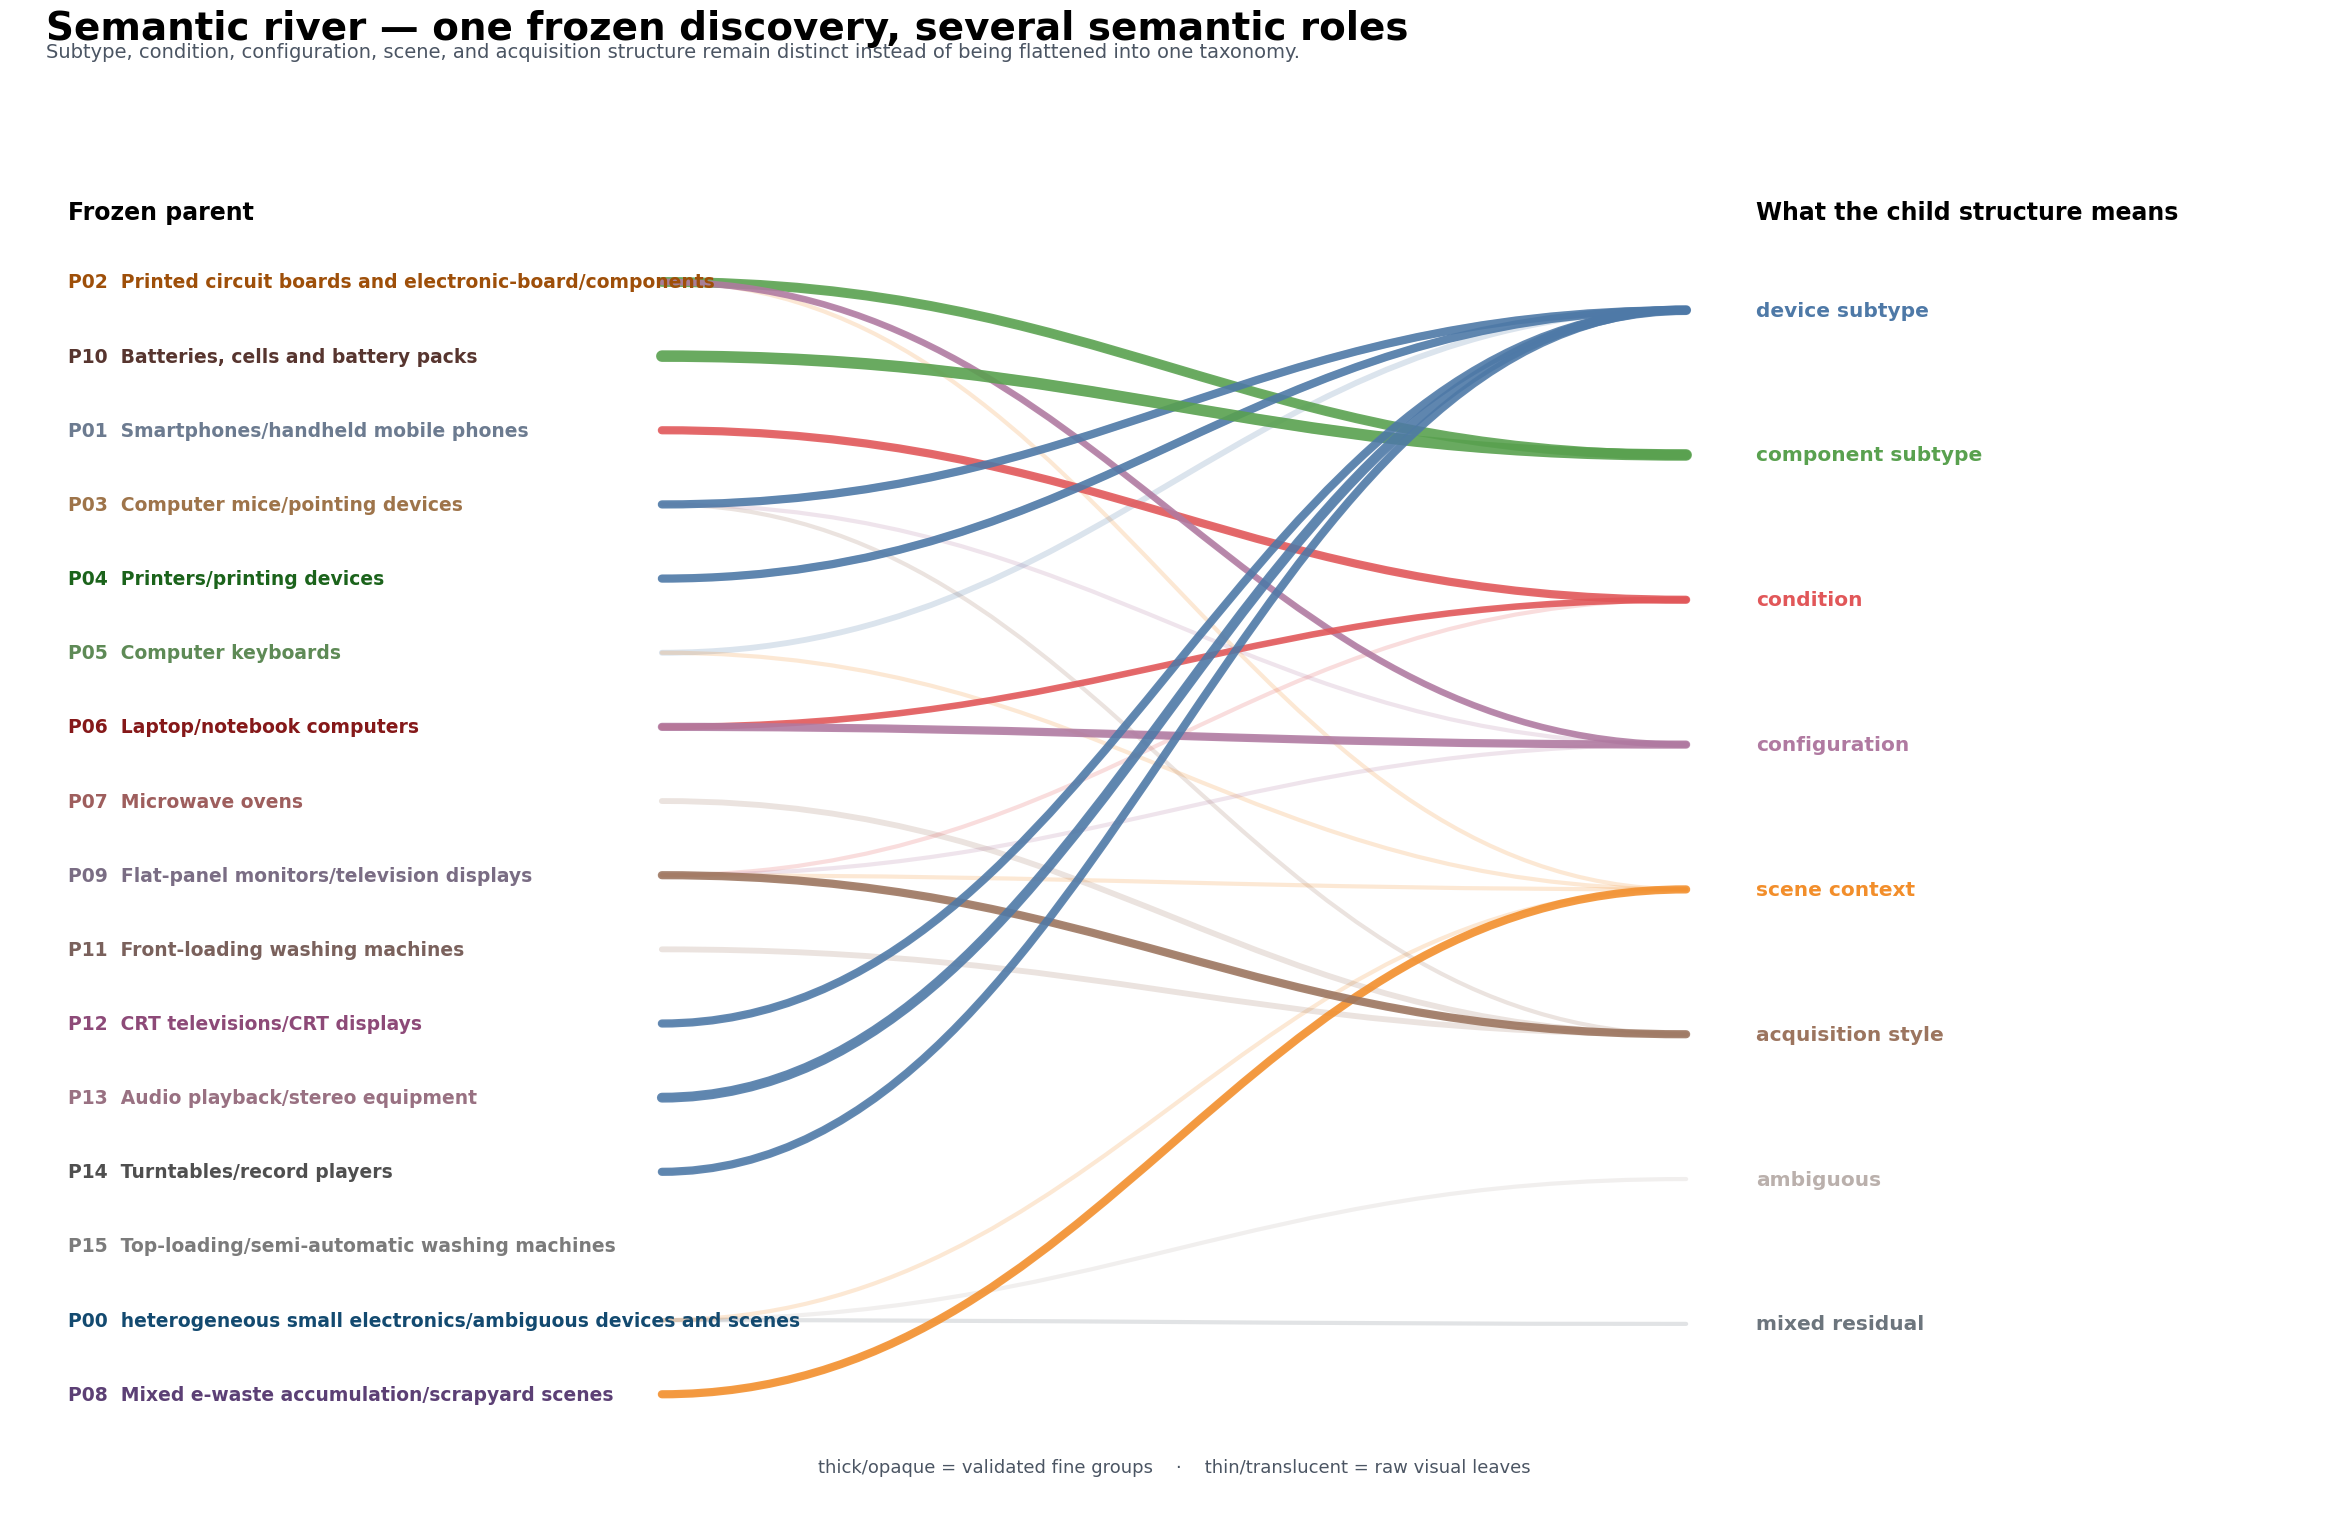

In [11]:
# 6A. Semantic river: frozen parent -> meaning of child structure
role_order=['device_subtype','component_subtype','condition','configuration','scene_context','acquisition_style','viewpoint','ambiguous','mixed_residual']
role_set=set(FINE_DF.role)|set(RAW_VISUAL_DF.role)
roles=[r for r in role_order if r in role_set]

fig,ax=plt.subplots(figsize=(24,16))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
order=list(PARENT_DF.sort_values(['role','parent_id']).parent_id)
py={pid:0.88-i*(0.79/(len(order)-1)) for i,pid in enumerate(order)}
ry={role:0.86-i*(0.72/(max(1,len(roles)-1))) for i,role in enumerate(roles)}

def ribbon(x0,y0,x1,y1,color,alpha,lw):
    path=MplPath([(x0,y0),(x0+.19,y0),(x1-.19,y1),(x1,y1)],
                 [MplPath.MOVETO,MplPath.CURVE4,MplPath.CURVE4,MplPath.CURVE4])
    ax.add_patch(PathPatch(path,facecolor='none',edgecolor=color,lw=lw,alpha=alpha,capstyle='round'))

for df,alpha,base in [(RAW_VISUAL_DF,0.20,1.8),(FINE_DF,0.88,3.5)]:
    counts=df.groupby(['parent_id','role']).size().reset_index(name='n')
    for _,r in counts.iterrows():
        if r.role in ry:
            ribbon(.28,py[int(r.parent_id)],.72,ry[r.role],ROLE_COLOR.get(r.role,'#777'),alpha,base+1.2*r.n)

for pid,y in py.items():
    ax.text(.025,y,f'P{pid:02d}  {SHORT[pid]}',ha='left',va='center',fontsize=13.5,fontweight='bold',
            color=PARENT_TEXT_COLOR[pid])
for role,y in ry.items():
    ax.text(.75,y,role.replace('_',' '),ha='left',va='center',fontsize=14.5,fontweight='bold',
            color=ROLE_COLOR.get(role,'#333'))
ax.text(.025,.925,'Frozen parent',fontsize=17,fontweight='bold')
ax.text(.75,.925,'What the child structure means',fontsize=17,fontweight='bold')
ax.text(.50,.035,'thick/opaque = validated fine groups    ·    thin/translucent = raw visual leaves',
        ha='center',fontsize=13,color='#4b5563')
fig.suptitle('Semantic river — one frozen discovery, several semantic roles',x=.035,y=.985,ha='left',fontsize=28,fontweight='bold')
fig.text(.035,.955,'Subtype, condition, configuration, scene, and acquisition structure remain distinct instead of being flattened into one taxonomy.',
         fontsize=14,color='#4b5563')
fig.subplots_adjust(left=.02,right=.99,bottom=.04,top=.92)
savefig(fig,'01_semantic_river')


### 6B. Parent semantic atlas

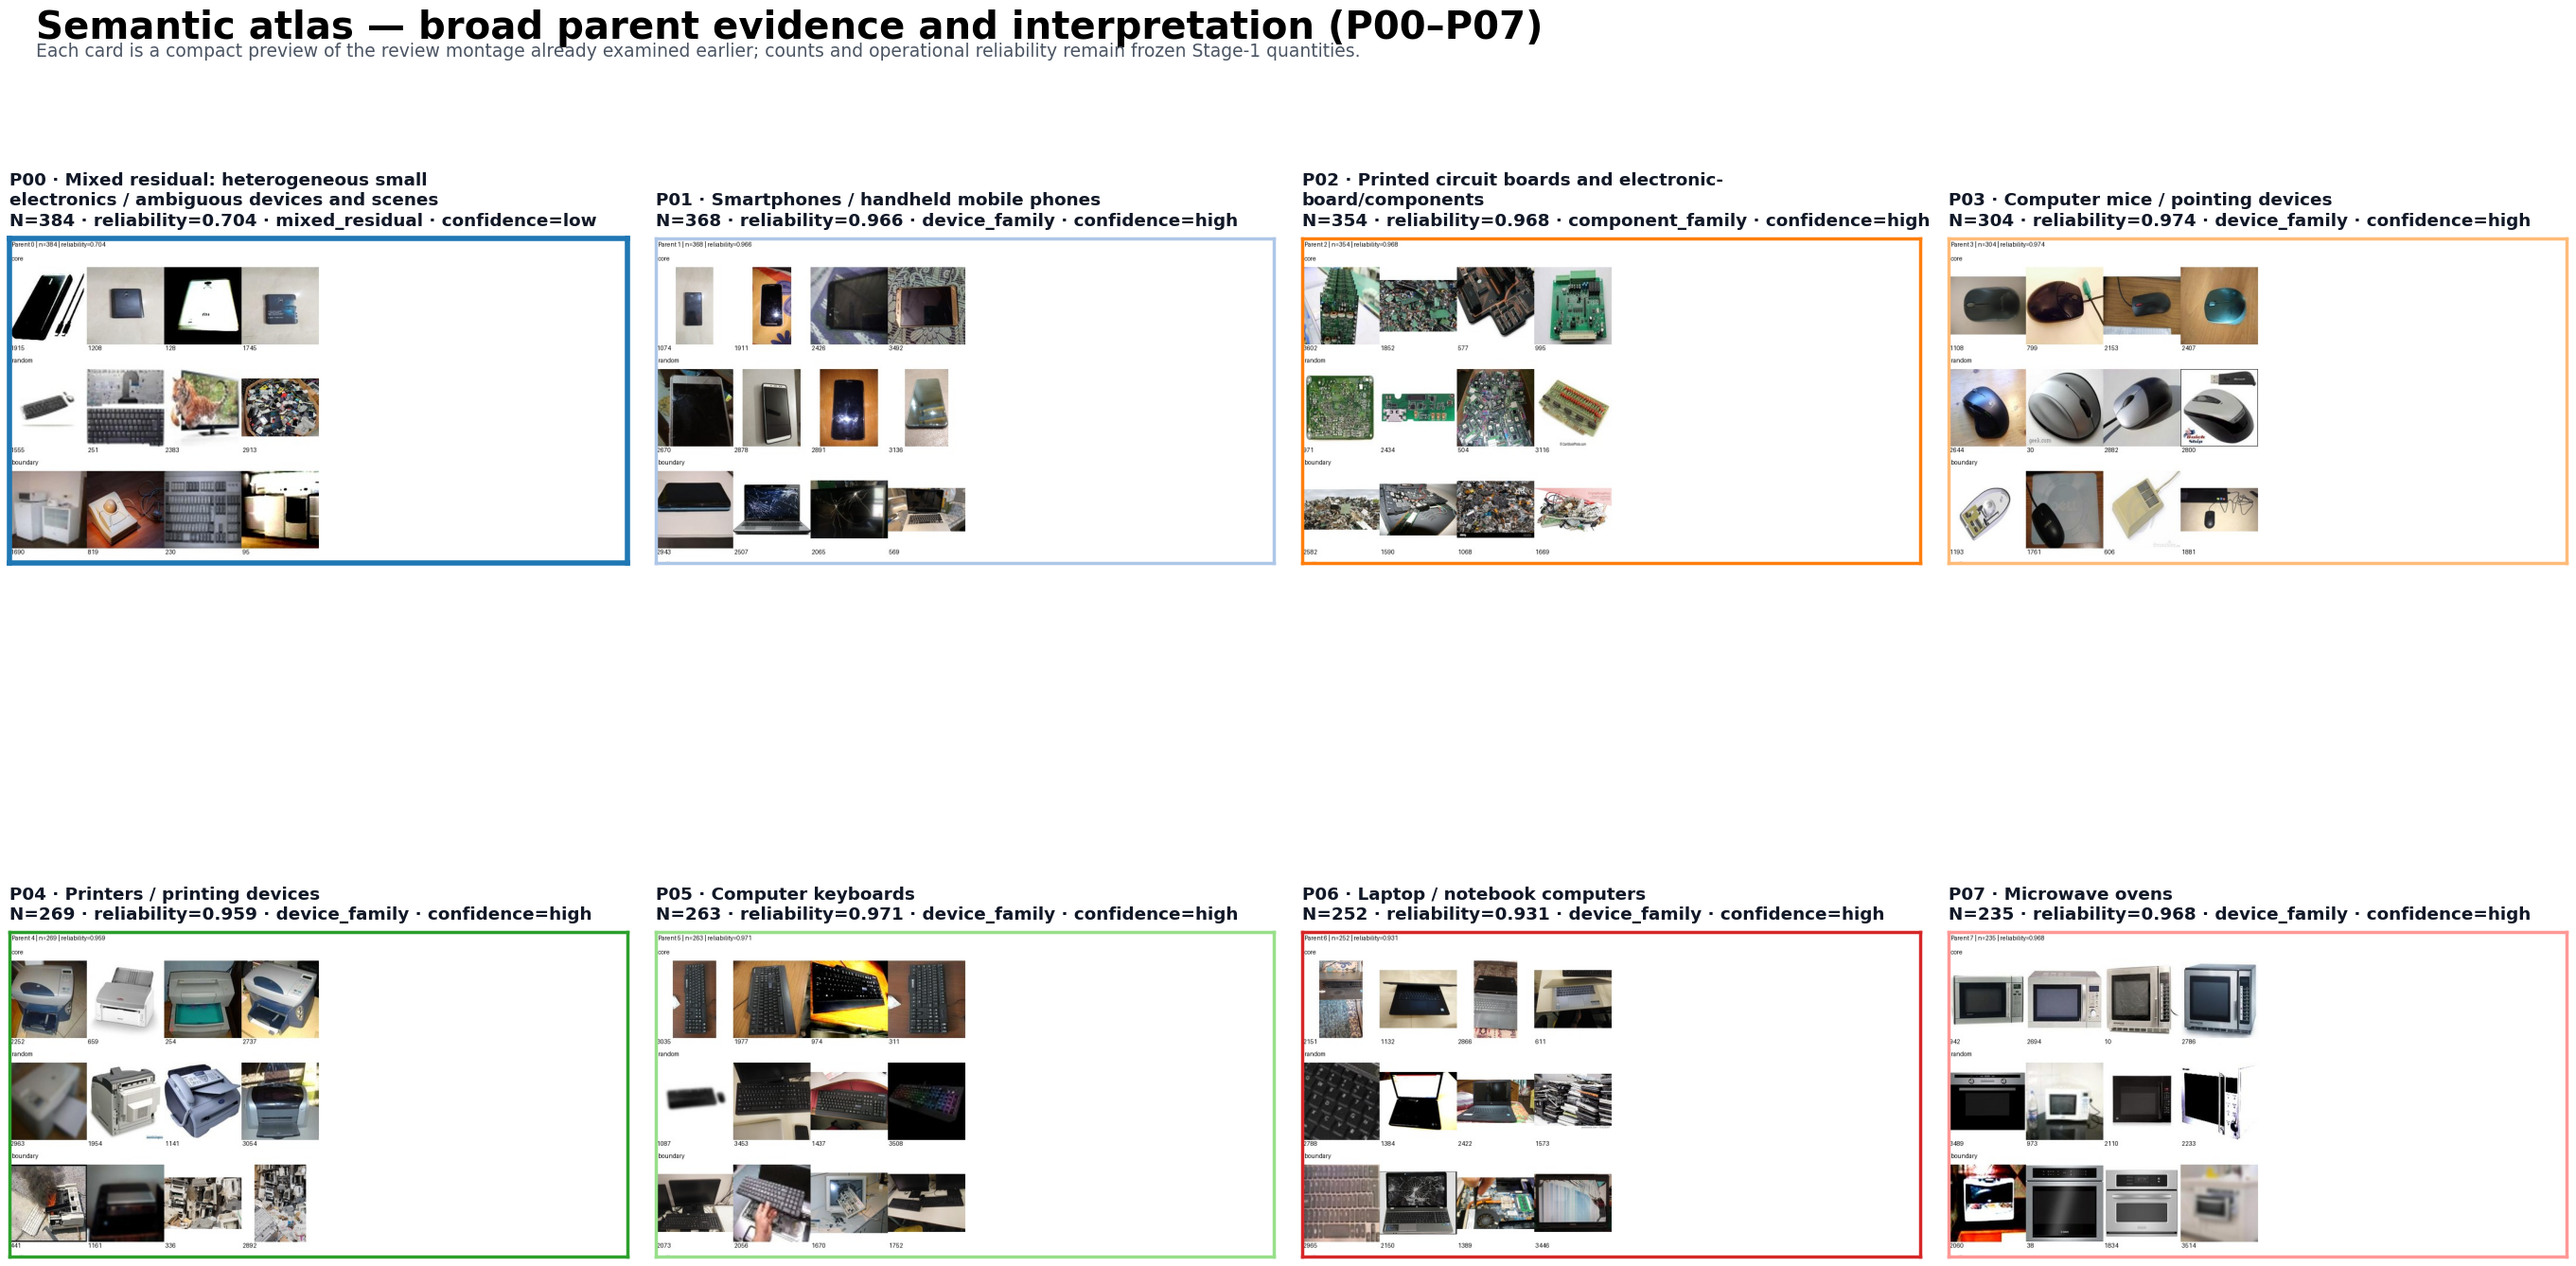

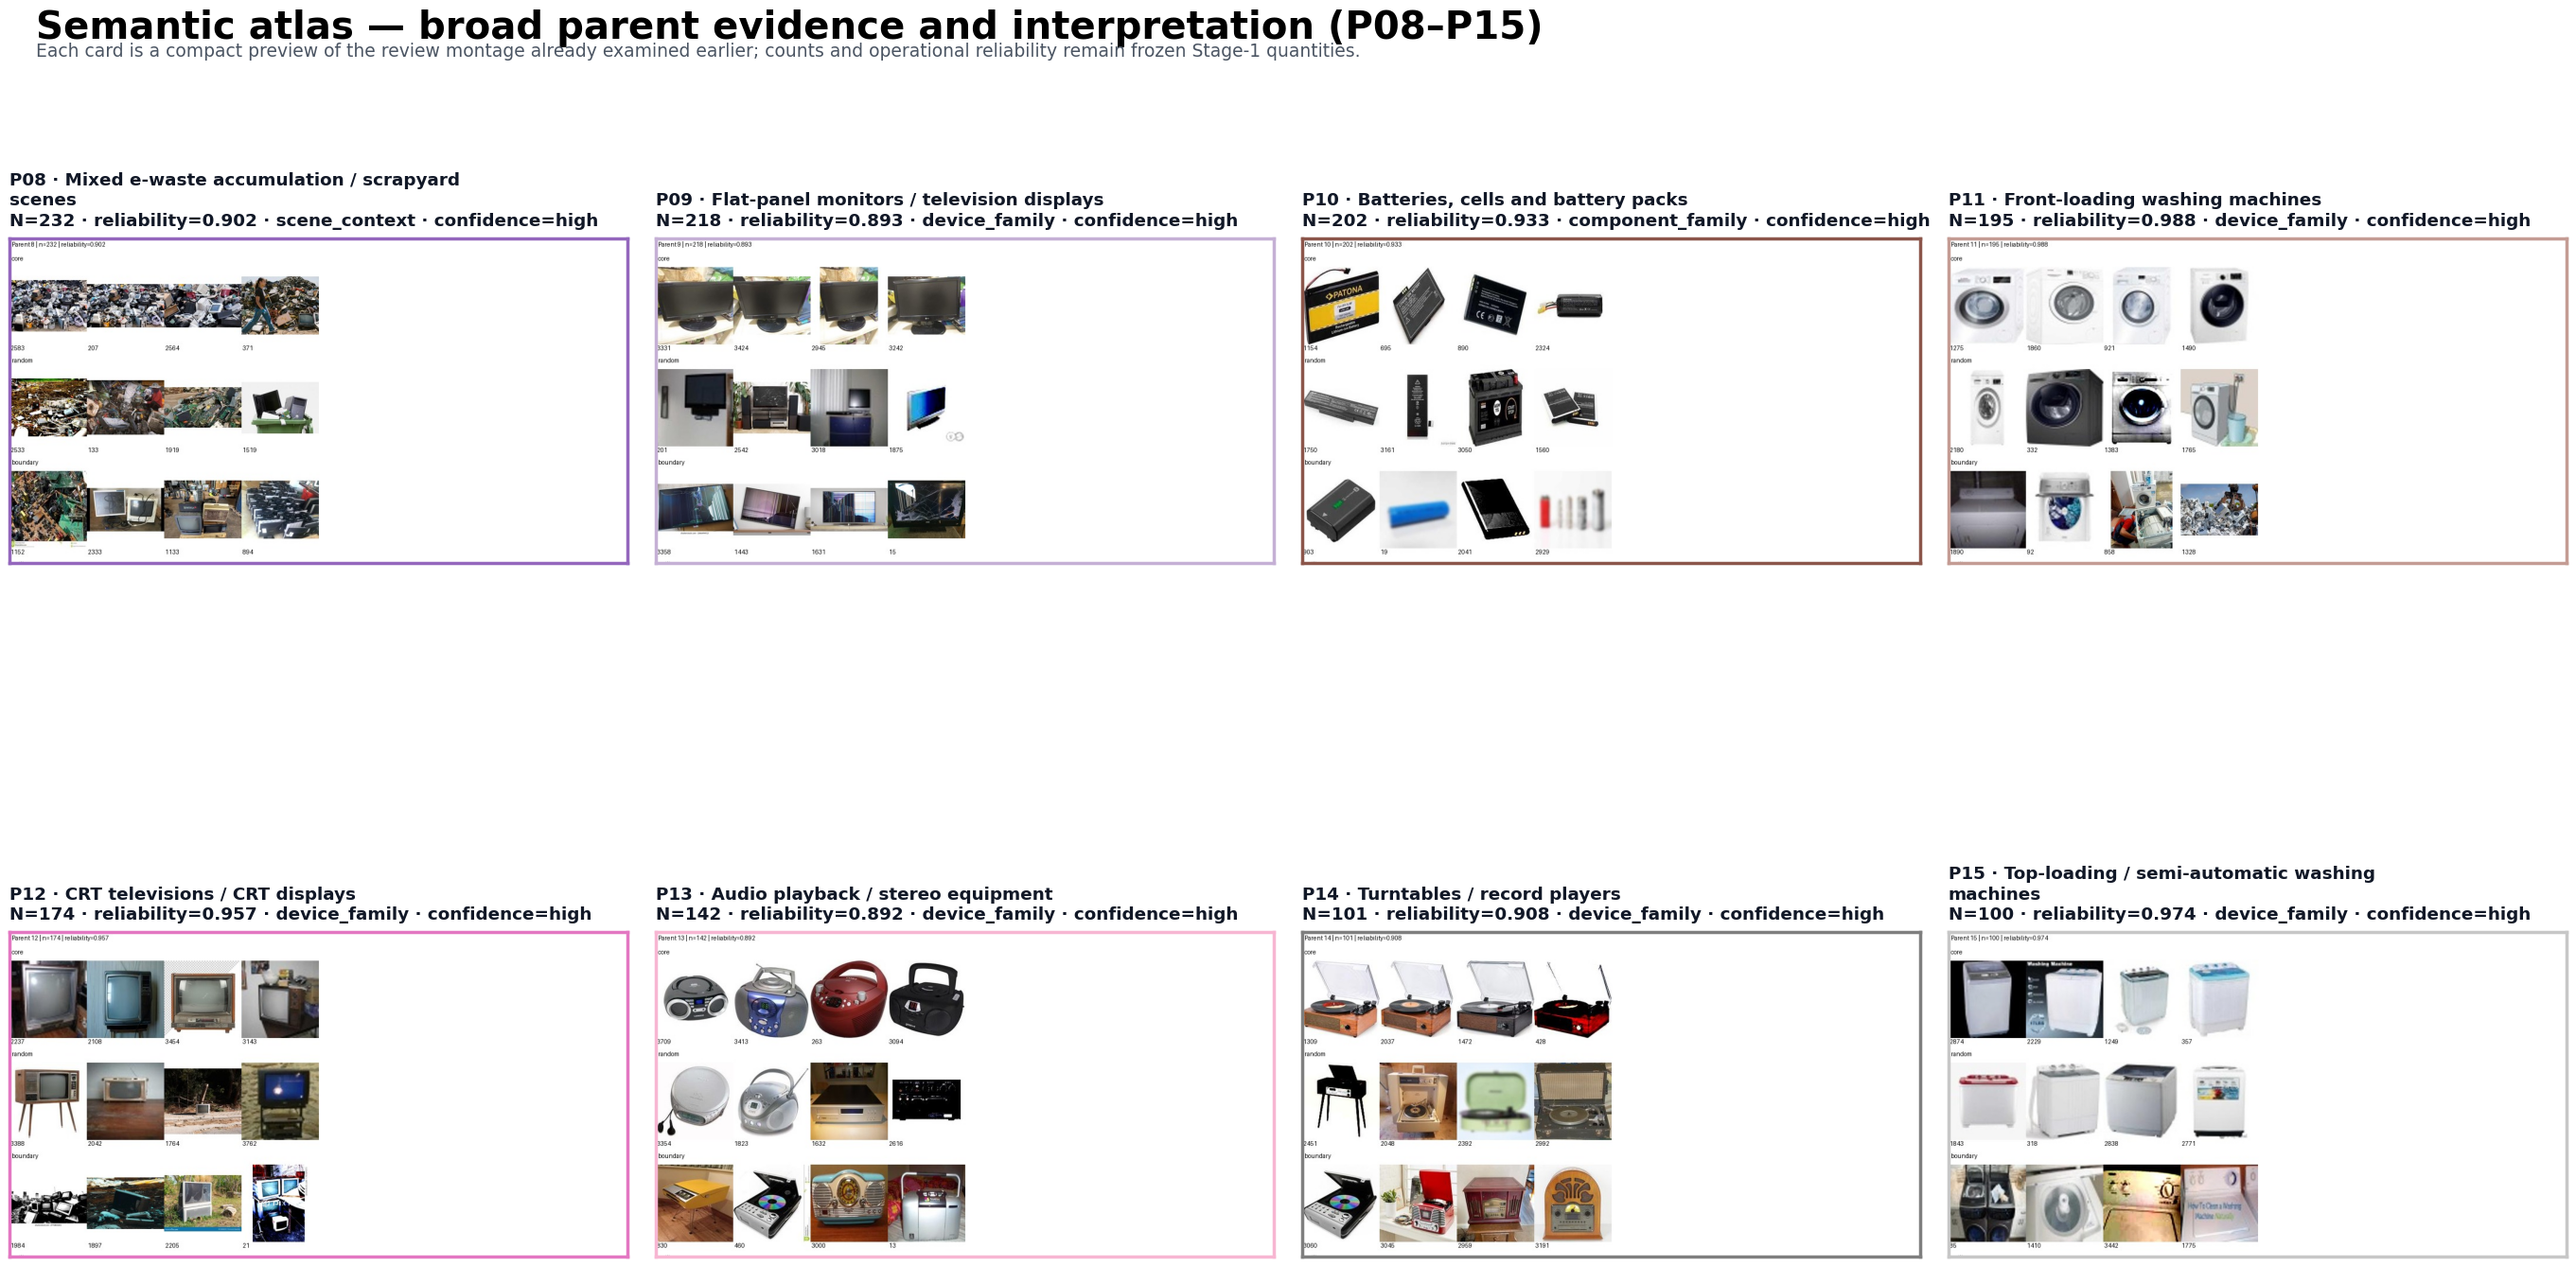

In [12]:
# 6B. Semantic parent atlas — two readable pages
# Individual parent montages were already shown at full resolution in Section 2A.
# These pages retain the visual evidence while keeping titles and reliability annotations legible.
parent_index=PARENT_DF.set_index('parent_id')
rel_index=PARENT_REL.set_index('parent_id')

for page_no, pids in enumerate([list(range(0,8)), list(range(8,16))], start=1):
    fig,axes=plt.subplots(2,4,figsize=(28,15))
    for pid,ax in zip(pids,axes.flat):
        r=parent_index.loc[pid]
        crop=montage_preview(FROZEN/f'review/parents/parent_{pid:02d}.jpg', crop_fraction=.62, max_width=1400)
        ax.imshow(crop)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_linewidth(4 if pid==0 else 2.5)
            sp.set_color(PARENT_COLOR[pid])
        rel=float(rel_index.loc[pid,'operational_reliability'])
        label=textwrap.fill(str(r.label), width=42)
        ax.set_title(
            f"P{pid:02d} · {label}\nN={COUNTS.get(pid,0):,} · reliability={rel:.3f} · {r.role} · confidence={r.confidence}",
            fontsize=13.2,fontweight='bold',loc='left',pad=10,color='#111827',linespacing=1.25
        )
    fig.suptitle(
        f'Semantic atlas — broad parent evidence and interpretation (P{pids[0]:02d}–P{pids[-1]:02d})',
        fontsize=29,fontweight='bold',x=.035,y=.988,ha='left'
    )
    fig.text(.035,.955,
             'Each card is a compact preview of the review montage already examined earlier; counts and operational reliability remain frozen Stage-1 quantities.',
             fontsize=13.5,color='#4b5563')
    fig.subplots_adjust(left=.025,right=.99,bottom=.035,top=.90,wspace=.045,hspace=.30)
    savefig(fig,f'02{chr(96+page_no)}_semantic_parent_atlas_P{pids[0]:02d}_P{pids[-1]:02d}',dpi=260,svg=False)


### 6C. Frozen PCA parent geometry

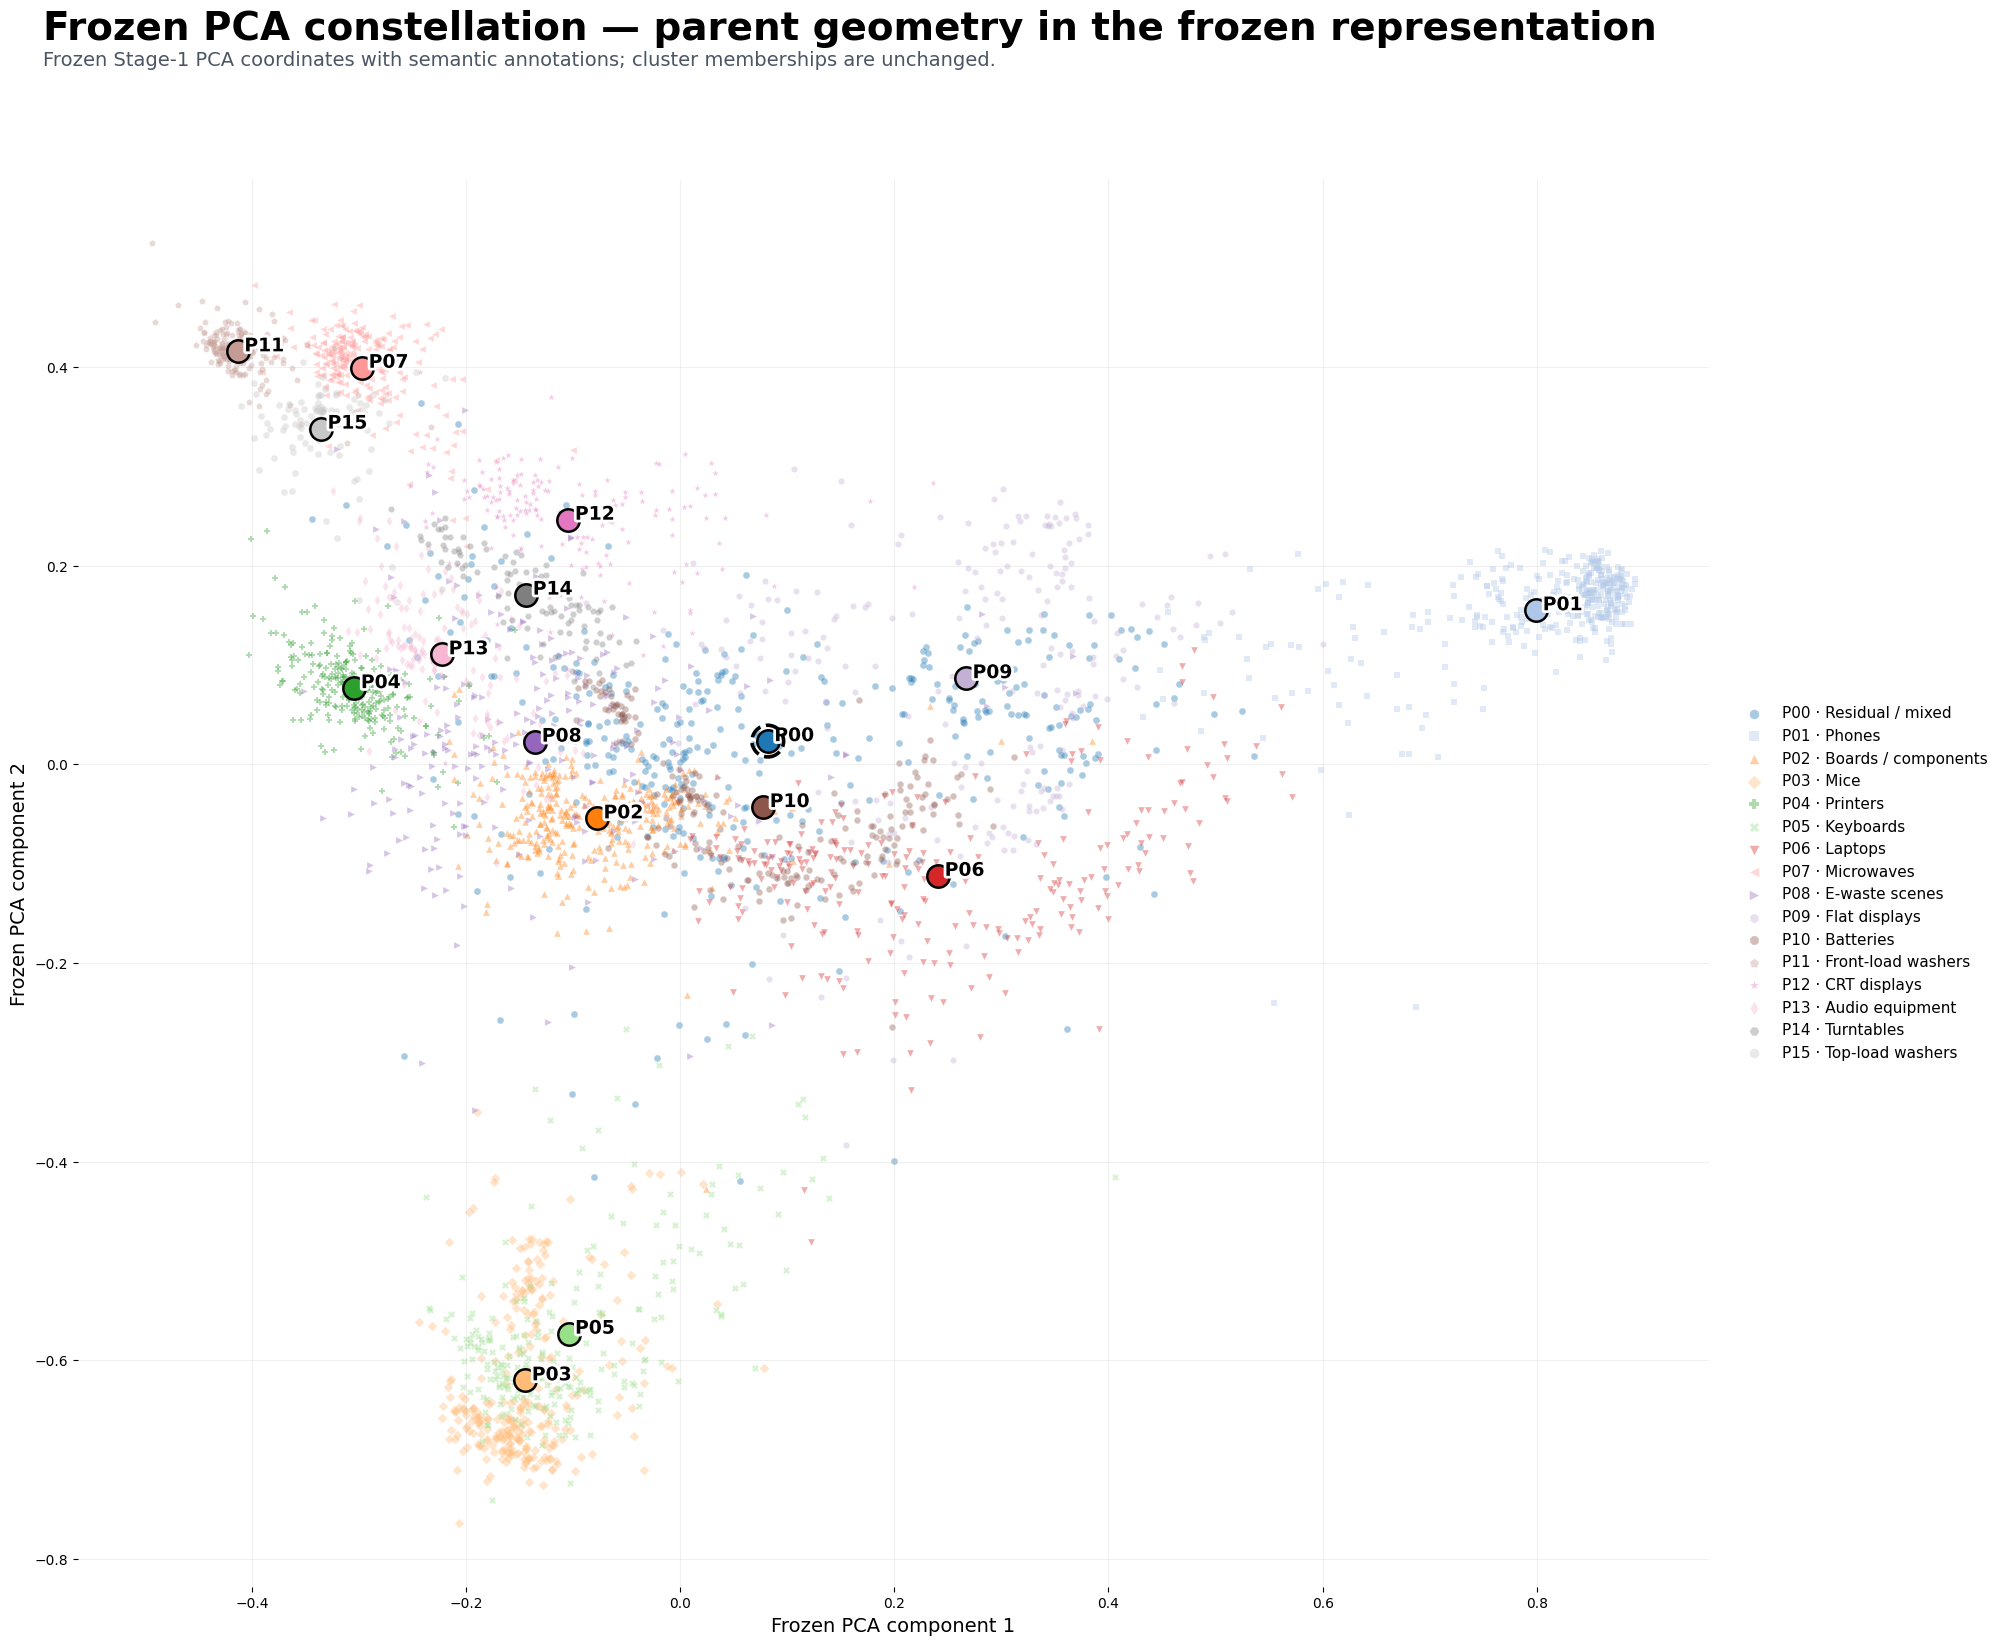

In [13]:
# 6C. Frozen PCA constellation
fig,ax=plt.subplots(figsize=(24,17))
ids=PER.raw_parent_id.to_numpy()
markers=['o','s','^','D','P','X','v','<','>','h','8','p','*','d','H','o']
for pid in range(16):
    m=ids==pid
    pts=PCA2[m]
    col=PARENT_COLOR[pid]
    ax.scatter(pts[:,0],pts[:,1],s=24,alpha=.38,c=[col],marker=markers[pid],
               linewidths=.15,edgecolors='white',label=f'P{pid:02d} · {PARENT_DISPLAY[pid]}',rasterized=True)
    mu=pts.mean(0)
    ax.scatter(*mu,s=260,c=[col],edgecolors='black',linewidths=1.8,zorder=6)
    txt=ax.text(mu[0],mu[1],f' P{pid:02d}',fontsize=13.5,fontweight='bold',color='black',zorder=7)
    txt.set_path_effects([pe.withStroke(linewidth=4,foreground='white')])
# residual ring
mu=PCA2[ids==0].mean(0)
ax.scatter(*mu,s=520,facecolors='none',edgecolors='black',linewidths=2.6,linestyle='--',zorder=8)
ax.set_xlabel('Frozen PCA component 1',fontsize=14); ax.set_ylabel('Frozen PCA component 2',fontsize=14)
fig.suptitle('Frozen PCA constellation — parent geometry in the frozen representation',x=.04,y=.985,ha='left',fontsize=28,fontweight='bold')
fig.text(.04,.952,'Frozen Stage-1 PCA coordinates with semantic annotations; cluster memberships are unchanged.',fontsize=14,color='#4b5563')
ax.grid(alpha=.18,linewidth=.8)
for s in ax.spines.values(): s.set_visible(False)
ax.legend(loc='center left',bbox_to_anchor=(1.01,.5),frameon=False,fontsize=11,ncol=1,markerscale=1.4)
fig.tight_layout(rect=[0.02,0.02,0.86,0.925])
savefig(fig,'03_frozen_pca_constellation')


### 6D. Proyeksi t-SNE (supplementary)

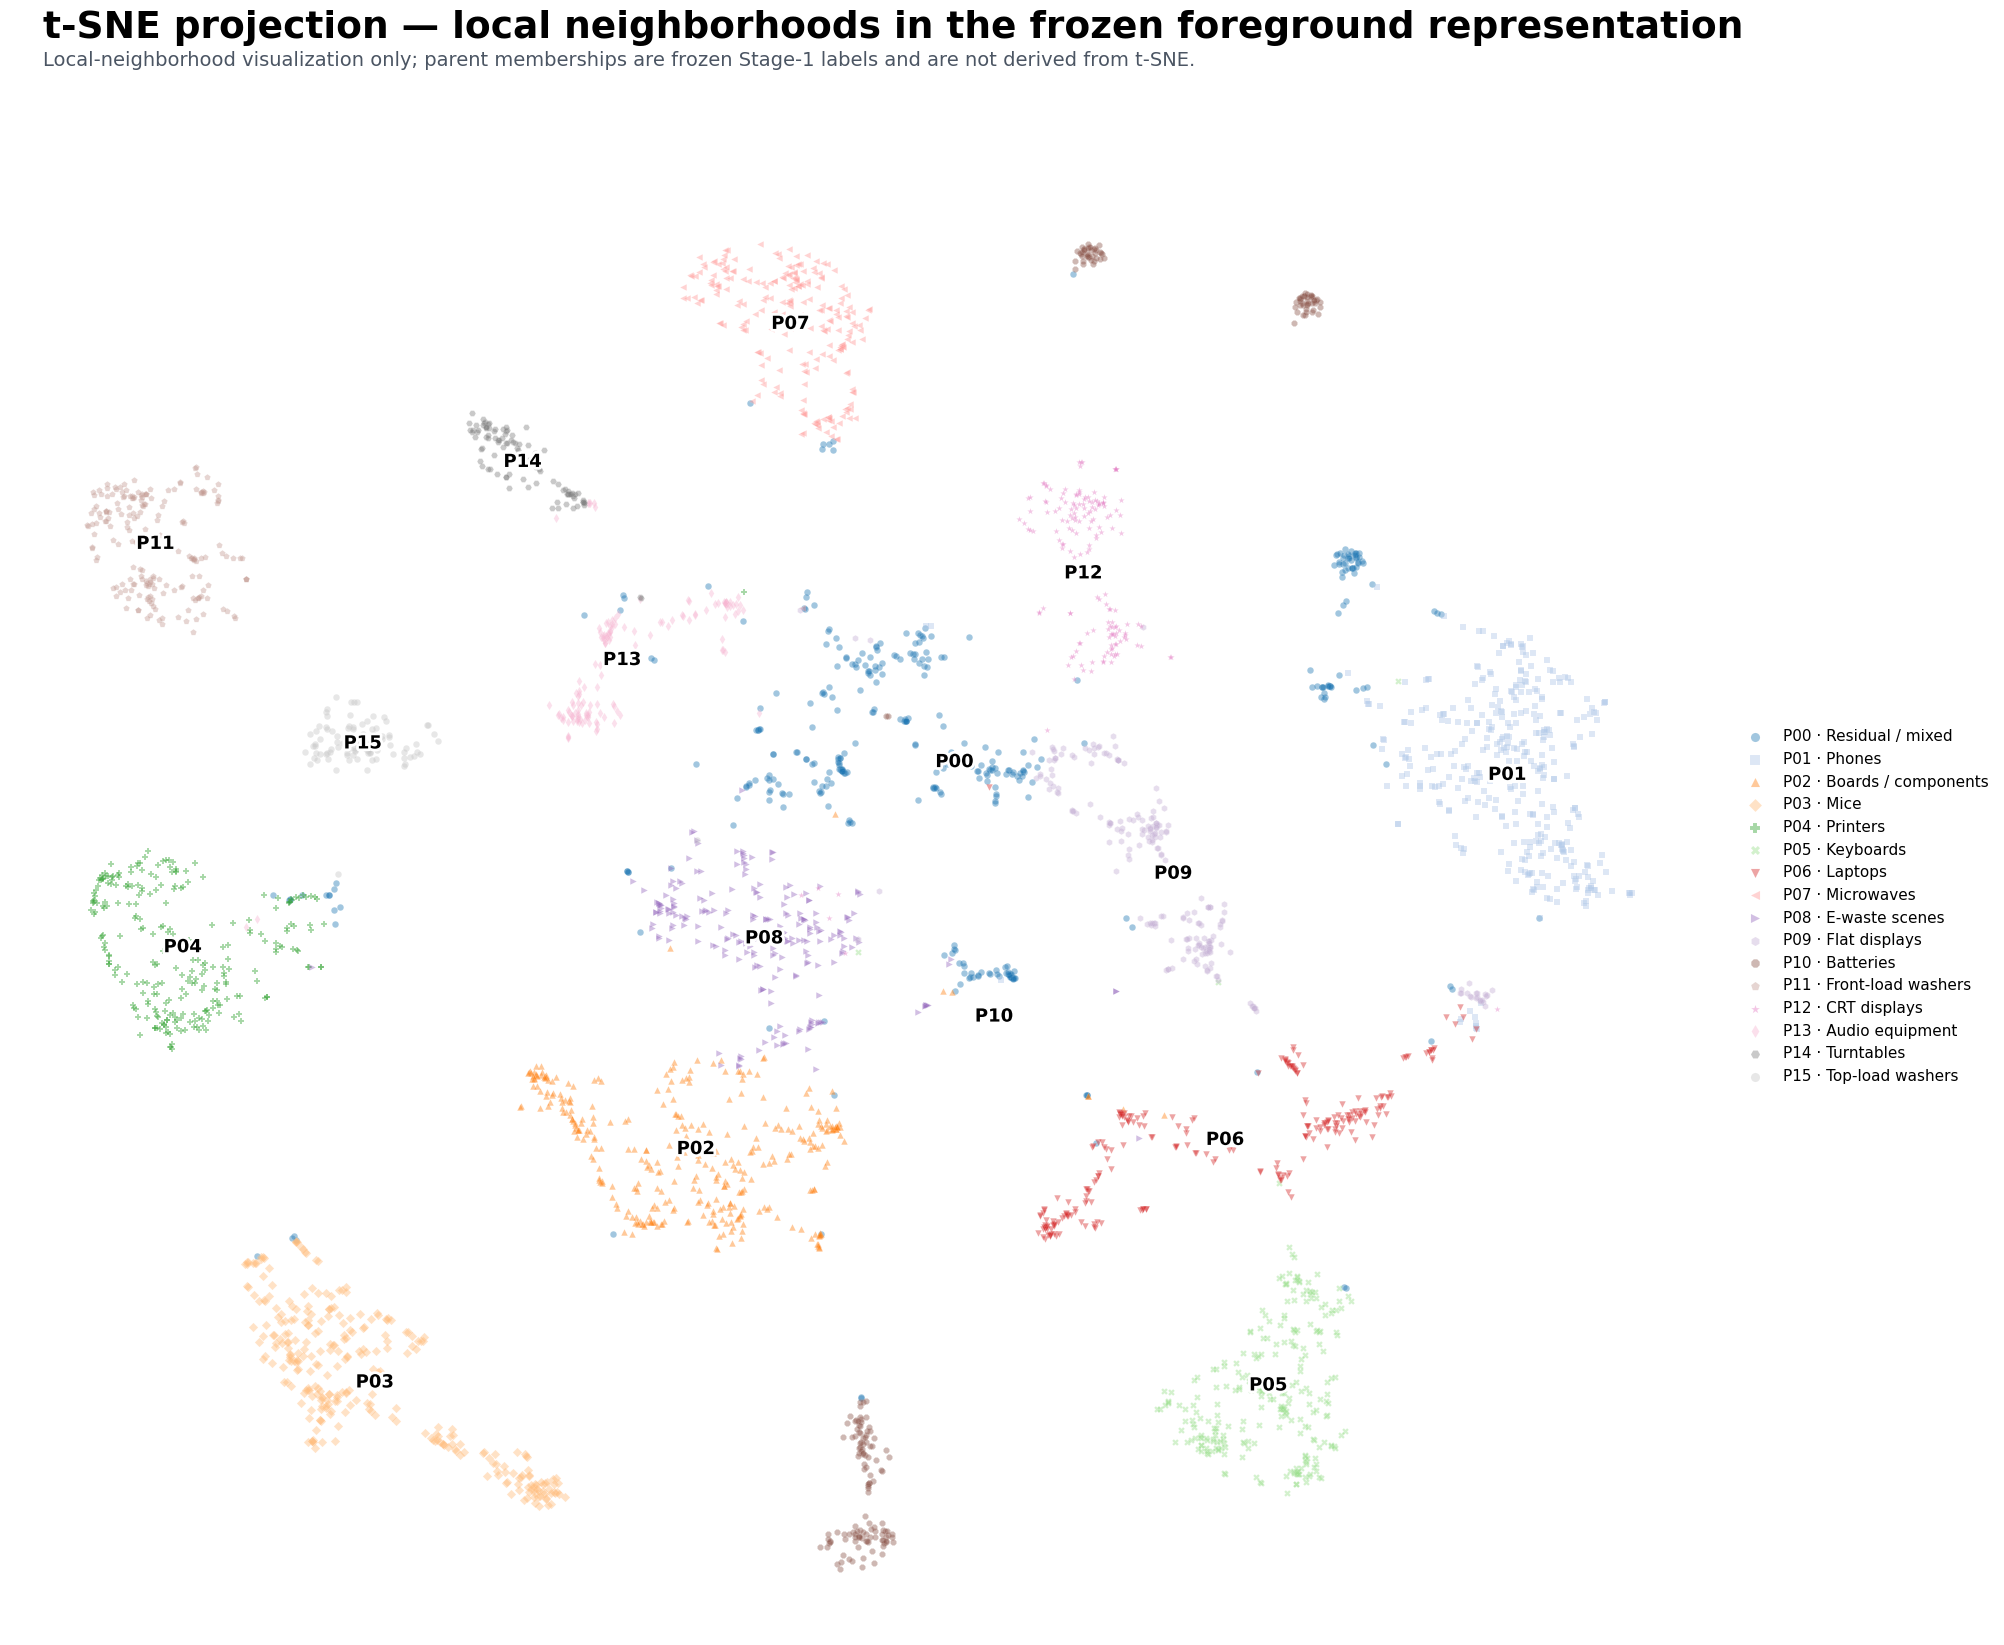

In [14]:
# 6D. Supplementary t-SNE projection of the frozen foreground representation
# This is NOT used to create, validate, merge, or change any cluster.
X=np.asarray(G_FOREGROUND,dtype=np.float32)
X50=SKPCA(n_components=min(50,X.shape[1]),random_state=42,svd_solver='auto').fit_transform(X)

# sklearn renamed n_iter -> max_iter in newer releases. Keep the notebook portable.
_tsne_kwargs=dict(
    n_components=2, perplexity=40, learning_rate='auto', init='pca',
    random_state=42, metric='euclidean', method='barnes_hut', angle=.5
)
try:
    _tsne=TSNE(max_iter=700, **_tsne_kwargs)
except TypeError:
    _tsne=TSNE(n_iter=700, **_tsne_kwargs)
TSNE2=_tsne.fit_transform(X50)

fig,ax=plt.subplots(figsize=(24,17))
for pid in range(16):
    m=ids==pid
    ax.scatter(TSNE2[m,0],TSNE2[m,1],s=22,alpha=.42,c=[PARENT_COLOR[pid]],marker=markers[pid],
               linewidths=.12,edgecolors='white',label=f'P{pid:02d} · {PARENT_DISPLAY[pid]}',rasterized=True)
    mu=TSNE2[m].mean(0)
    txt=ax.text(mu[0],mu[1],f'P{pid:02d}',fontsize=13,fontweight='bold',ha='center',va='center')
    txt.set_path_effects([pe.withStroke(linewidth=4,foreground='white')])
fig.suptitle('t-SNE projection — local neighborhoods in the frozen foreground representation',x=.04,y=.985,ha='left',fontsize=27,fontweight='bold')
fig.text(.04,.952,'Local-neighborhood visualization only; parent memberships are frozen Stage-1 labels and are not derived from t-SNE.',fontsize=14,color='#4b5563')
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
ax.legend(loc='center left',bbox_to_anchor=(1.01,.5),frameon=False,fontsize=11,markerscale=1.4)
fig.tight_layout(rect=[0.02,0.02,0.86,0.925])
savefig(fig,'04_tsne_frozen_representation')
np.save(OUT/'exports/tsne2_communication_only.npy',TSNE2)


### 6E. Parent-centroid hierarchy

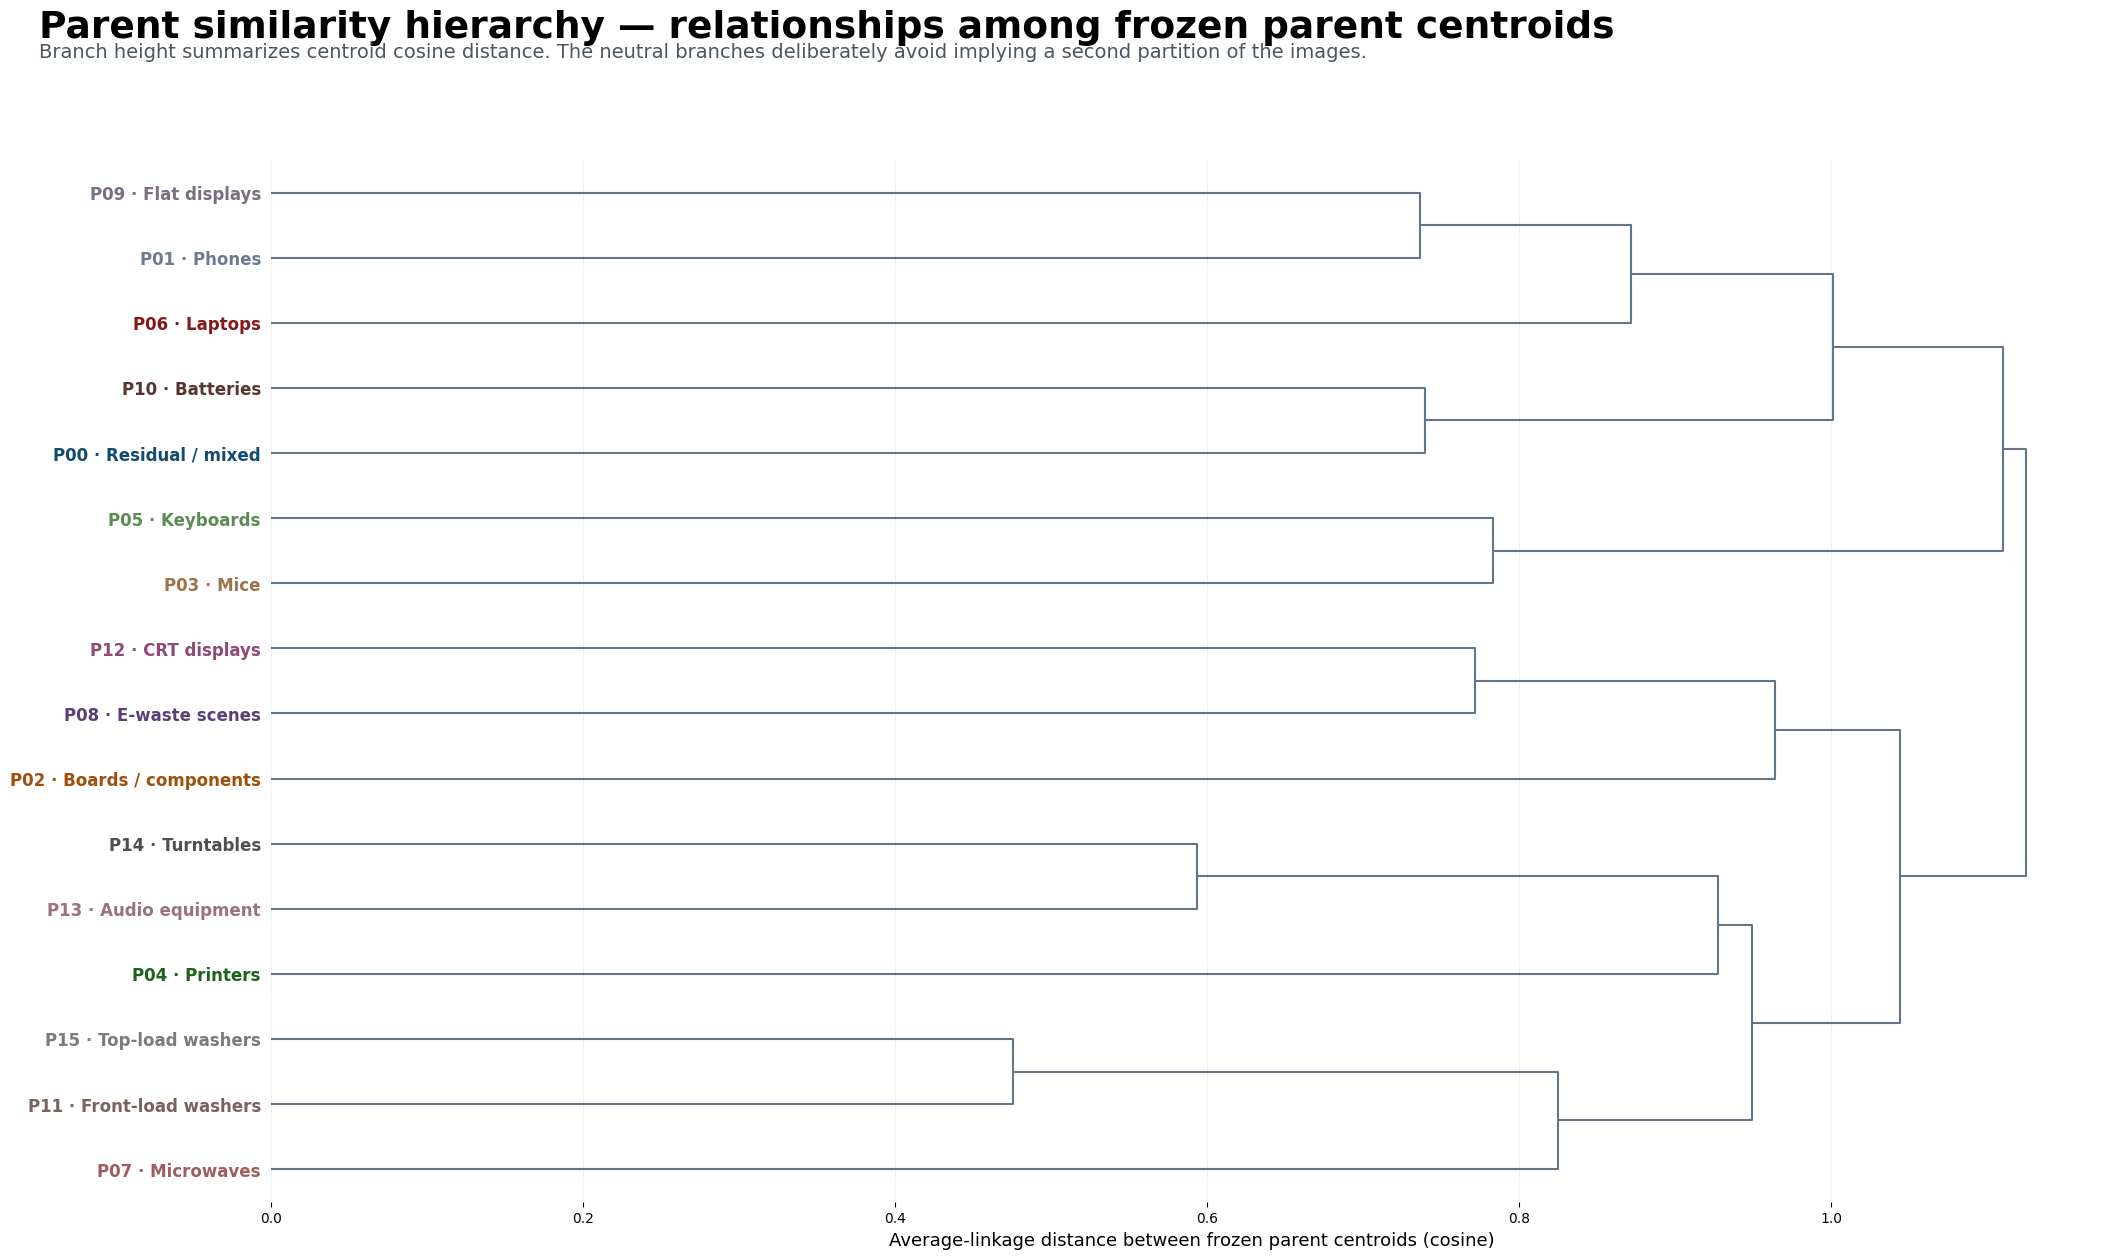

In [15]:
# 6E. Parent-centroid hierarchy in the frozen foreground representation
# This is a similarity visualization only: linkage is applied to 16 already-frozen parent centroids.
centroids=np.vstack([X[ids==pid].mean(axis=0) for pid in range(16)])
centroids_norm=centroids/(np.linalg.norm(centroids,axis=1,keepdims=True)+1e-12)
D=pdist(centroids_norm,metric='cosine')
Z=linkage(D,method='average')

fig,ax=plt.subplots(figsize=(22,13))
labels=[f'P{pid:02d} · {PARENT_DISPLAY[pid]}' for pid in range(16)]
den=dendrogram(
    Z, labels=labels, orientation='right', leaf_font_size=12, ax=ax,
    color_threshold=0, above_threshold_color='#64748b', link_color_func=lambda _: '#64748b'
)
for tick in ax.get_yticklabels():
    m=re.match(r'P(\d+)',tick.get_text())
    if m:
        pid=int(m.group(1)); tick.set_color(PARENT_TEXT_COLOR[pid]); tick.set_fontweight('bold')
ax.set_xlabel('Average-linkage distance between frozen parent centroids (cosine)',fontsize=13)
fig.suptitle('Parent similarity hierarchy — relationships among frozen parent centroids',x=.04,y=.985,ha='left',fontsize=27,fontweight='bold')
fig.text(.04,.948,'Branch height summarizes centroid cosine distance. The neutral branches deliberately avoid implying a second partition of the images.',fontsize=14,color='#4b5563')
ax.grid(axis='x',alpha=.18)
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(rect=[0.02,0.02,0.99,0.92])
savefig(fig,'06_parent_centroid_hierarchy')


### 6F. Parent-centroid similarity matrix

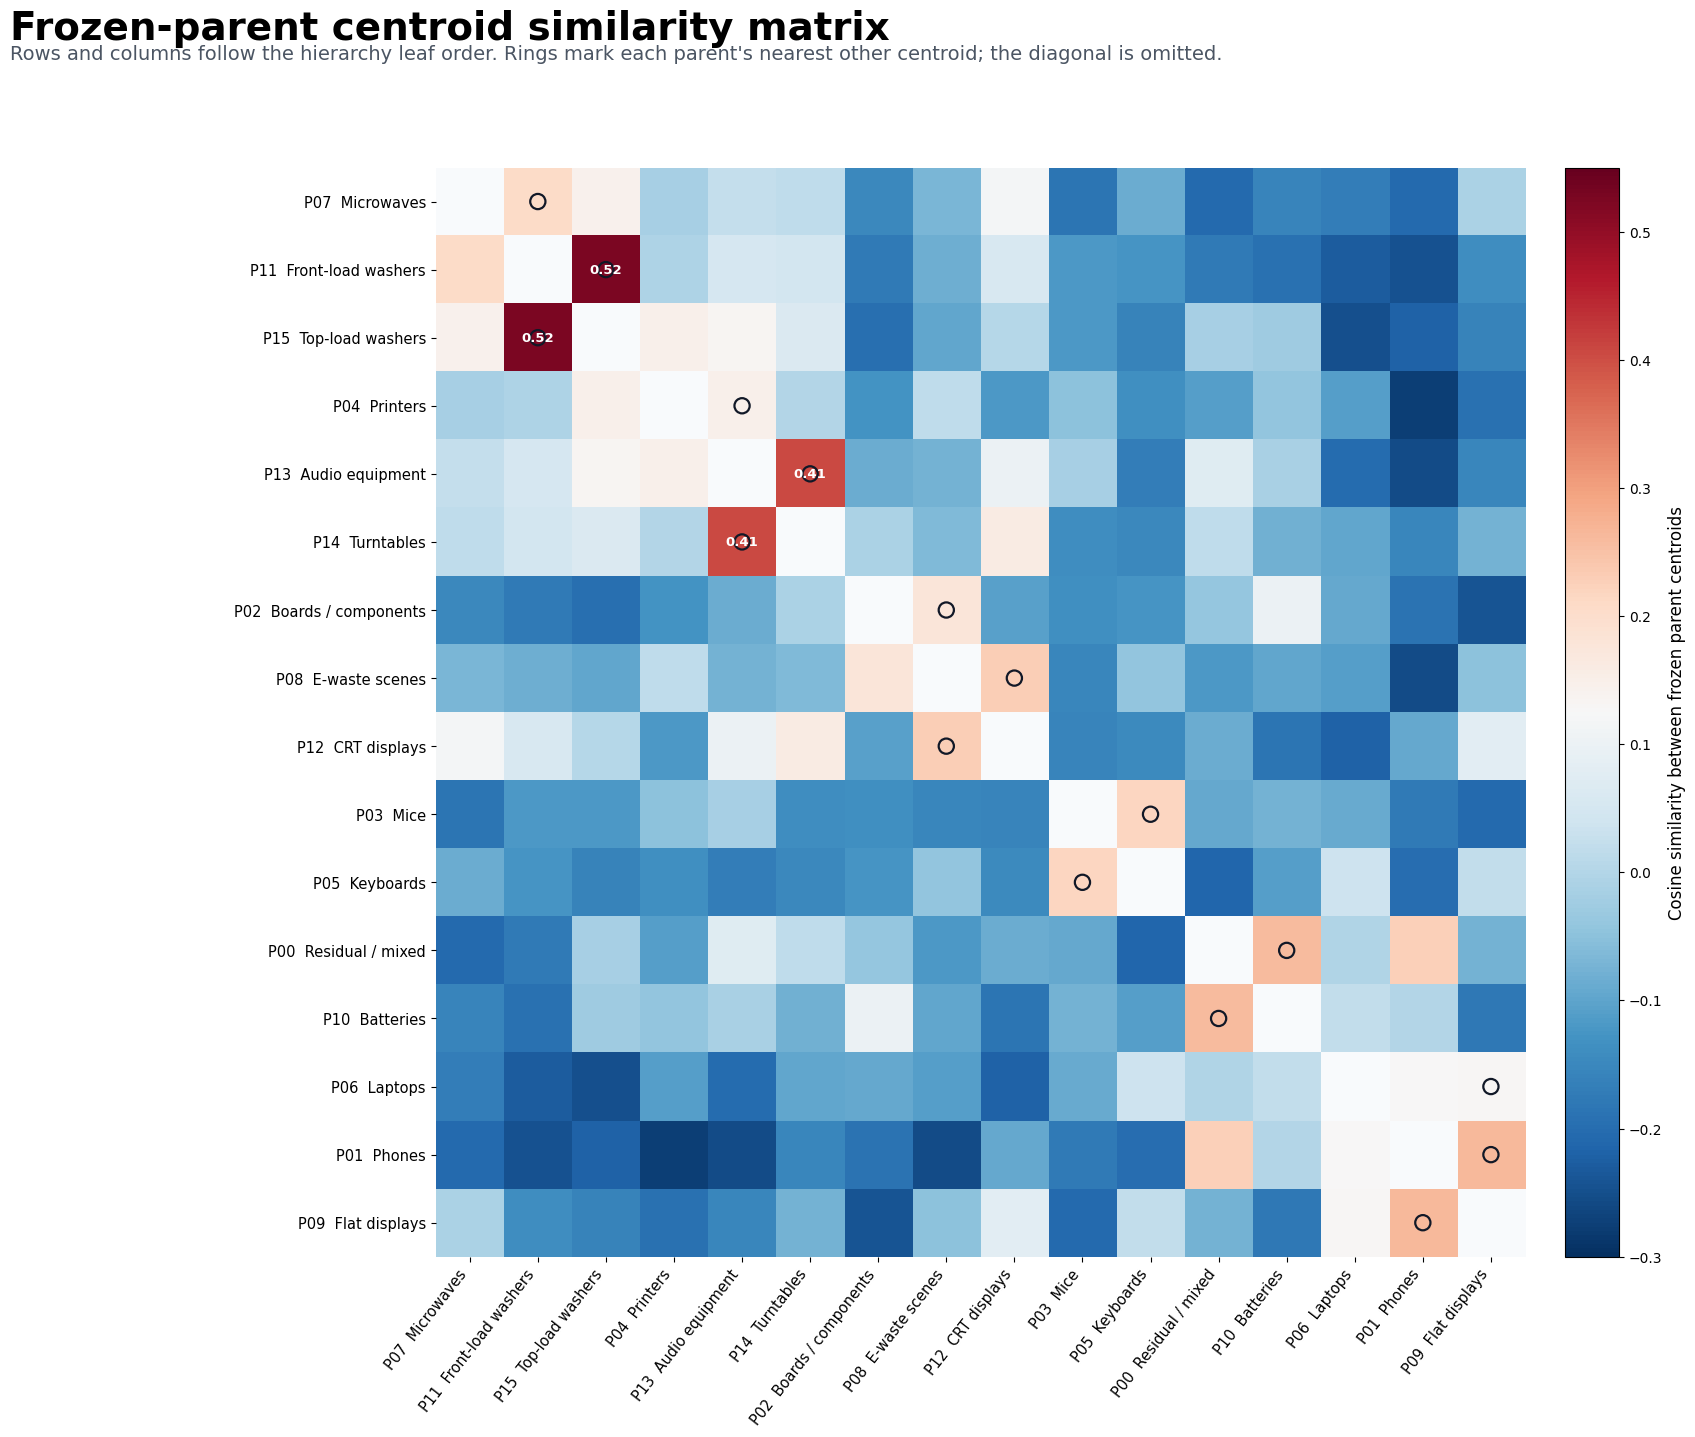

In [16]:
# 6F. Frozen-parent centroid similarity matrix
S=cosine_similarity(centroids_norm)
hier_order=list(den['leaves'])
S_ord=S[np.ix_(hier_order,hier_order)].copy()
np.fill_diagonal(S_ord,np.nan)
labels=[f'P{pid:02d}  {PARENT_DISPLAY[pid]}' for pid in hier_order]

fig,ax=plt.subplots(figsize=(18,15))
cmap=plt.get_cmap('RdBu_r').copy()
cmap.set_bad('#f8fafc')
im=ax.imshow(S_ord,cmap=cmap,vmin=-.30,vmax=.55,aspect='equal')
ax.set_xticks(range(16),labels,rotation=52,ha='right',fontsize=10.5)
ax.set_yticks(range(16),labels,fontsize=10.5)

# Mark each row's nearest other parent; annotate only stronger positive relationships.
pos_in_order={pid:i for i,pid in enumerate(hier_order)}
for row_i,pid in enumerate(hier_order):
    vals=S[pid].copy(); vals[pid]=-np.inf
    nbr=int(np.argmax(vals)); col_i=pos_in_order[nbr]
    ax.scatter(col_i,row_i,s=120,facecolors='none',edgecolors='#111827',linewidths=1.6)
for i in range(16):
    for j in range(16):
        if i!=j and np.isfinite(S_ord[i,j]) and S_ord[i,j] >= .30:
            ax.text(j,i,f'{S_ord[i,j]:.2f}',ha='center',va='center',fontsize=9.5,
                    color='black' if S_ord[i,j] < .38 else 'white',fontweight='bold')

cbar=fig.colorbar(im,ax=ax,fraction=.035,pad=.025)
cbar.set_label('Cosine similarity between frozen parent centroids',fontsize=12)
fig.suptitle('Frozen-parent centroid similarity matrix',x=.04,y=.985,ha='left',fontsize=28,fontweight='bold')
fig.text(.04,.952,"Rows and columns follow the hierarchy leaf order. Rings mark each parent's nearest other centroid; the diagonal is omitted.",fontsize=14,color='#4b5563')
for s in ax.spines.values(): s.set_visible(False)
fig.tight_layout(rect=[0.02,0.03,0.98,0.925])
savefig(fig,'07_parent_centroid_similarity_matrix')


### 6G. Ringkasan raw visual grammar

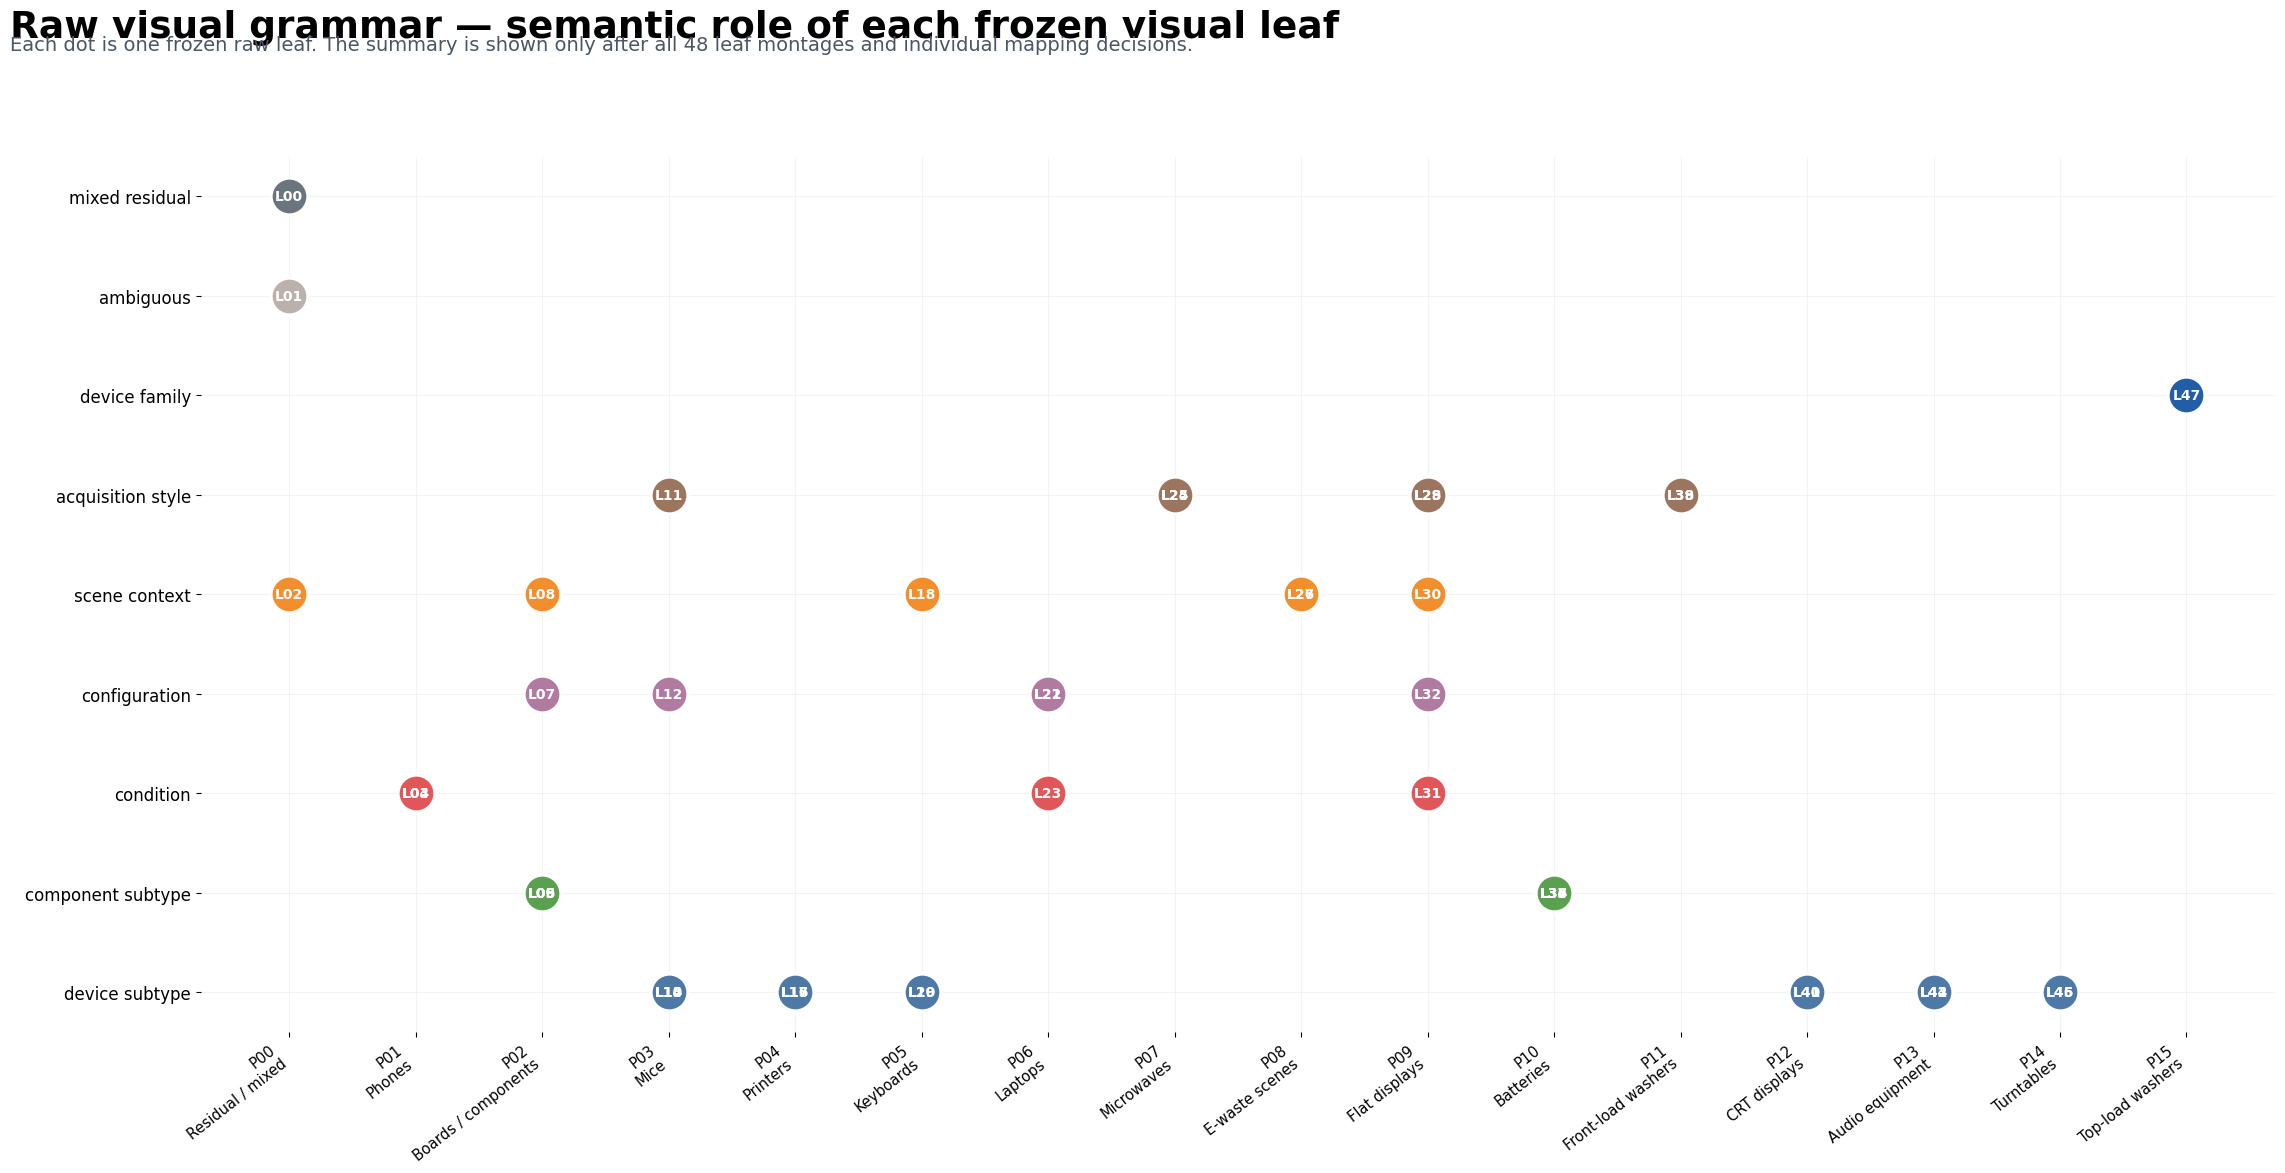

In [17]:
# 6G. Raw-visual grammar matrix — concise summary after all 48 leaves were individually reviewed
preferred_roles=['device_subtype','component_subtype','condition','configuration','scene_context','acquisition_style','device_family','ambiguous','mixed_residual']
role_set=set(RAW_VISUAL_DF.role)
roles=[r for r in preferred_roles if r in role_set] + sorted(role_set-set(preferred_roles))
role_to_y={r:i for i,r in enumerate(roles)}

fig,ax=plt.subplots(figsize=(24,12.5))
for _,r in RAW_VISUAL_DF.iterrows():
    pid=int(r.parent_id); lid=int(r.leaf_id); y=role_to_y[r.role]
    ax.scatter(pid,y,s=700,c=[ROLE_COLOR.get(r.role,'#777')],edgecolors='white',linewidths=2.2,zorder=3)
    ax.text(pid,y,f'L{lid:02d}',ha='center',va='center',fontsize=10,fontweight='bold',color='white',zorder=4)

ax.set_xticks(range(16),[f'P{i:02d}\n{PARENT_DISPLAY[i]}' for i in range(16)],rotation=38,ha='right',fontsize=10.5)
ax.set_yticks(range(len(roles)),[r.replace('_',' ') for r in roles],fontsize=12)
ax.set_xlim(-.7,15.7)
ax.grid(alpha=.14,zorder=0)
for s in ax.spines.values(): s.set_visible(False)
fig.suptitle('Raw visual grammar — semantic role of each frozen visual leaf',x=.04,y=.985,ha='left',fontsize=27,fontweight='bold')
fig.text(.04,.952,'Each dot is one frozen raw leaf. The summary is shown only after all 48 leaf montages and individual mapping decisions.',fontsize=14,color='#4b5563')
fig.tight_layout(rect=[0.04,0.05,0.99,0.92])
savefig(fig,'08_raw_visual_role_matrix')


### 6H. Ringkasan interpretasi global ICA

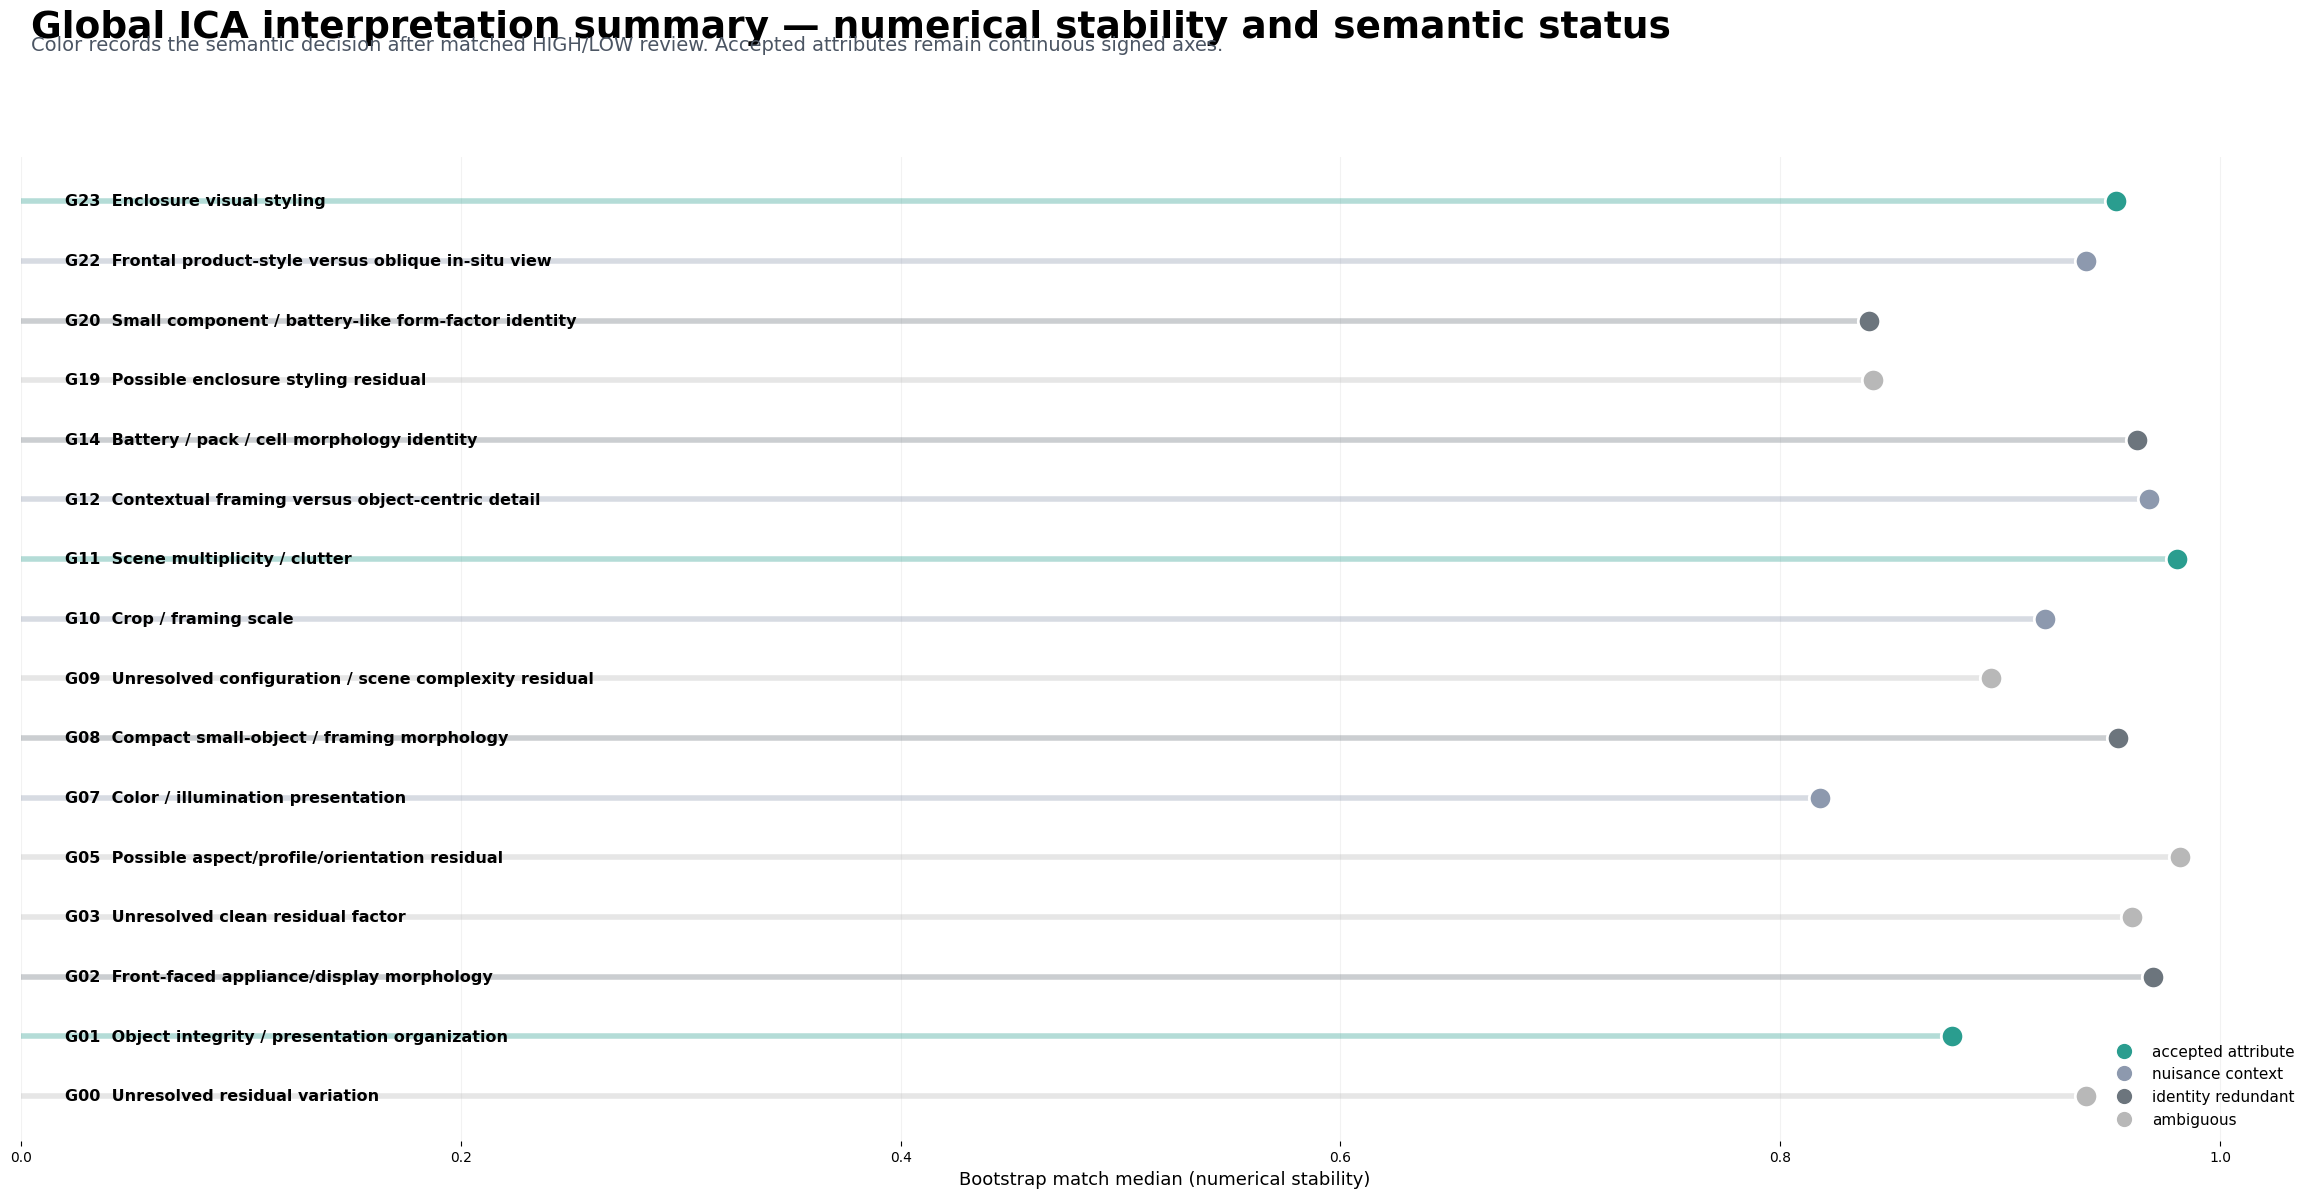

In [18]:
# 6H. Global ICA interpretation summary
gm=GLOBAL_FACTOR_DF.merge(GLOBAL_MET[['factor','bootstrap_match_median','eta2_parent','eta2_raw_visual','nuisance_r2']],
                          left_on='factor_id',right_on='factor',how='left')
status_order=['accepted_attribute','nuisance_context','identity_redundant','ambiguous']
status_color={'accepted_attribute':'#2a9d8f','nuisance_context':'#8d99ae','identity_redundant':'#6c757d','ambiguous':'#b8b8b8'}
fig,ax=plt.subplots(figsize=(24,12.5))
y=np.arange(len(gm))
for i,r in gm.reset_index(drop=True).iterrows():
    ax.scatter(r.bootstrap_match_median,i,s=260,c=status_color[r.status],edgecolors='white',linewidths=2,zorder=3)
    ax.plot([0,r.bootstrap_match_median],[i,i],color=status_color[r.status],alpha=.35,lw=4,zorder=2)
    ax.text(.02,i,f"G{int(r.factor_id):02d}  {r.axis_name}",va='center',fontsize=11.5,fontweight='bold')
ax.set_xlim(0,1.04); ax.set_yticks([])
ax.set_xlabel('Bootstrap match median (numerical stability)',fontsize=13)
legend=[Line2D([0],[0],marker='o',color='w',markerfacecolor=status_color[s],markersize=12,label=s.replace('_',' ')) for s in status_order]
ax.legend(handles=legend,loc='lower right',frameon=False,fontsize=11)
ax.grid(axis='x',alpha=.16)
for s in ax.spines.values(): s.set_visible(False)
fig.suptitle('Global ICA interpretation summary — numerical stability and semantic status',x=.035,y=.985,ha='left',fontsize=27,fontweight='bold')
fig.text(.035,.952,'Color records the semantic decision after matched HIGH/LOW review. Accepted attributes remain continuous signed axes.',fontsize=14,color='#4b5563')
fig.tight_layout(rect=[0.02,0.03,0.99,0.92])
savefig(fig,'09_global_factor_decision_lens')


### 6I. Coverage dan komposisi semantik

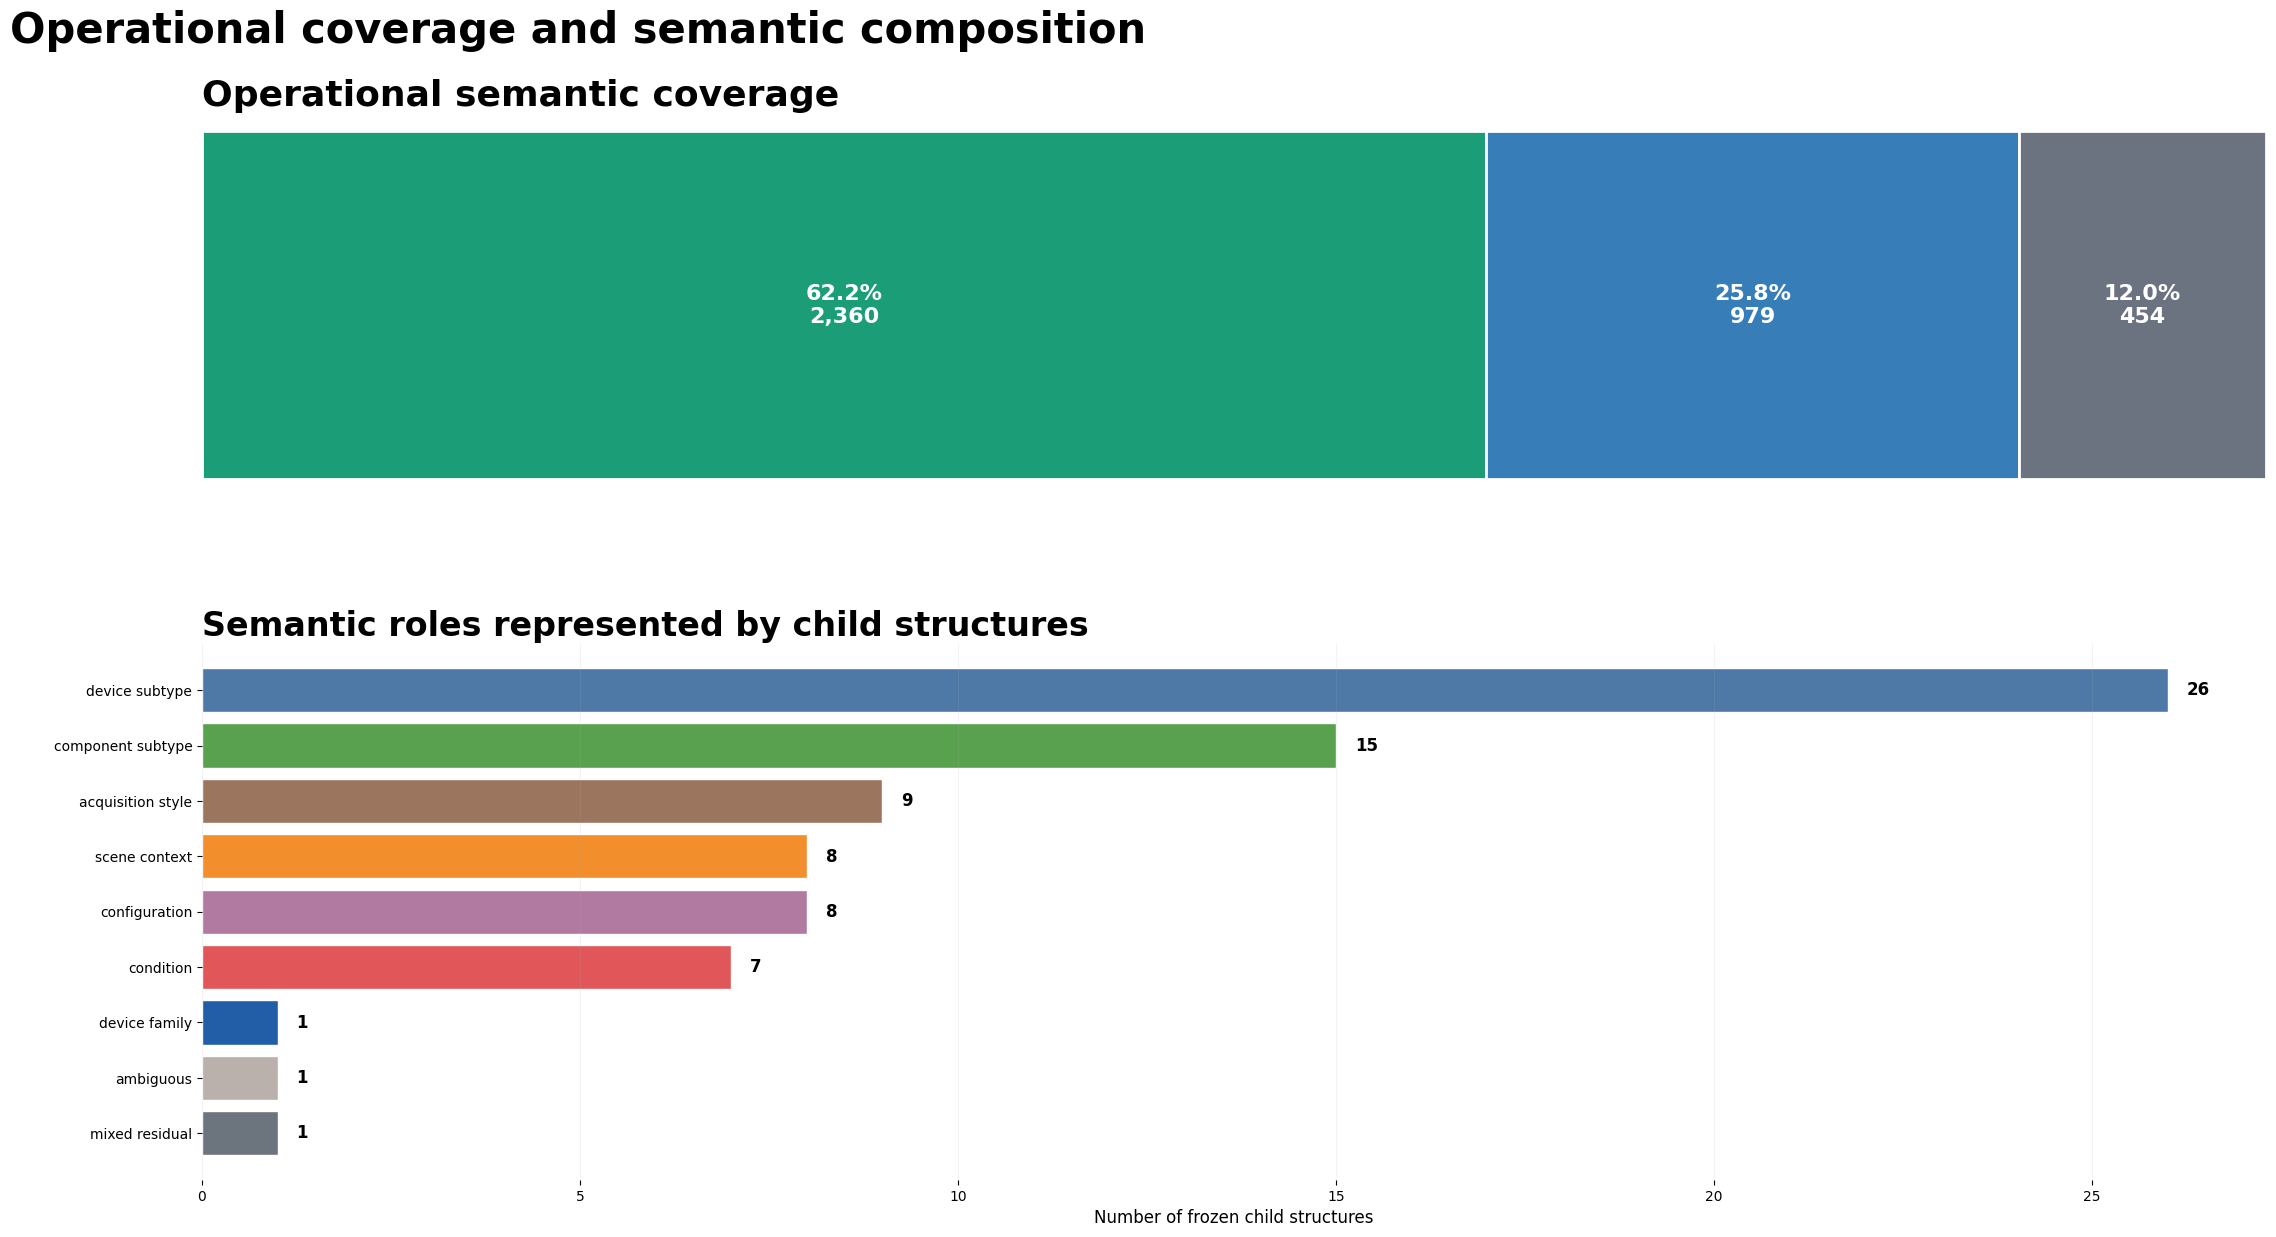

In [19]:
# 6I. Operational coverage + semantic role composition
vc=SEM.discovery_status.value_counts()
status_order=['reliable_parent_and_fine_group','reliable_parent_only','unknown_mixed']
status_colors=['#1b9e77','#377eb8','#6b7280']
fig=plt.figure(figsize=(24,13))
gs=fig.add_gridspec(2,1,height_ratios=[1,1.4],hspace=.32)
ax=fig.add_subplot(gs[0])
left=0
for s,c in zip(status_order,status_colors):
    n=int(vc.get(s,0)); frac=n/len(SEM)
    ax.barh([0],[frac],left=left,height=.55,color=c,edgecolor='white',linewidth=2)
    ax.text(left+frac/2,0,f'{frac*100:.1f}%\n{n:,}',ha='center',va='center',fontsize=16,fontweight='bold',color='white')
    left+=frac
ax.set_xlim(0,1); ax.set_yticks([]); ax.set_xticks([])
ax.set_title('Operational semantic coverage',loc='left',fontsize=26,fontweight='bold')
for s in ax.spines.values(): s.set_visible(False)

ax2=fig.add_subplot(gs[1])
role_counts=pd.concat([FINE_DF[['role']],RAW_VISUAL_DF[['role']]]).role.value_counts().sort_values()
ax2.barh(role_counts.index.str.replace('_',' '),role_counts.values,
         color=[ROLE_COLOR.get(r,'#777') for r in role_counts.index],edgecolor='white')
for i,v in enumerate(role_counts.values): ax2.text(v+.25,i,str(v),va='center',fontsize=12,fontweight='bold')
ax2.set_xlabel('Number of frozen child structures',fontsize=12)
ax2.set_title('Semantic roles represented by child structures',loc='left',fontsize=24,fontweight='bold')
ax2.grid(axis='x',alpha=.15)
for s in ax2.spines.values(): s.set_visible(False)
fig.suptitle('Operational coverage and semantic composition',fontsize=30,fontweight='bold',x=.04,ha='left')
fig.subplots_adjust(left=.12,right=.98,bottom=.08,top=.90,hspace=.38)
savefig(fig,'10_coverage_and_semantic_composition')


## 7. Validasi final dan handoff

In [20]:
# Validasi final, provenance, report, dan paket handoff Semantic Mapping.
if set(PARENT_DF.parent_id.astype(int)) != set(PER.raw_parent_id.astype(int).unique()):
    raise ValueError('Parent IDs pada registry tidak lengkap.')
if set(FINE_DF.fine_id.astype(int)) != set(FINE_ASSOC.validated_fine_group_id.astype(int)):
    raise ValueError('Fine IDs pada registry tidak lengkap.')
if set(RAW_VISUAL_DF.leaf_id.astype(int)) != set(RAW_ASSOC.raw_visual_leaf_id.astype(int)):
    raise ValueError('Raw visual IDs pada registry tidak lengkap.')
if set(GLOBAL_FACTOR_DF.factor_id.astype(int)) != set(GLOBAL_MET.loc[GLOBAL_MET.candidate_for_interpretation, 'factor'].astype(int)):
    raise ValueError('Global ICA registry tidak sesuai dengan kandidat aktif.')
if set(map(tuple, FAMILY_FACTOR_DF[['parent_id', 'factor_id']].astype(int).to_numpy())) != set(
    map(tuple, FAMILY_MET.loc[FAMILY_MET.candidate_for_interpretation, ['parent', 'factor']].astype(int).to_numpy())
):
    raise ValueError('Family ICA registry tidak sesuai dengan kandidat aktif.')
if set(PATCH_DF.parent_id.astype(int)) != set(PER.raw_parent_id.astype(int).unique()):
    raise ValueError('Patch semantic registry tidak lengkap.')

SEM2 = pd.read_csv(OUT / 'exports/per_image_semantic_discovery.csv')
for column in PER.columns:
    upstream = PER[column]
    exported = SEM2[column]
    if pd.api.types.is_numeric_dtype(upstream):
        if not np.allclose(upstream.to_numpy(), exported.to_numpy(), equal_nan=True):
            raise ValueError(f'Kolom numerik Discovery berubah saat semantic join: {column}')
    elif not upstream.fillna('').astype(str).equals(exported.fillna('').astype(str)):
        raise ValueError(f'Kolom Discovery berubah saat semantic join: {column}')

manifest = {
    'mapping_version': 'stage2-semantic-mapping-v3',
    'notebook_revision': 'semantic-mapping-2026-09-28',
    'created_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'source_discovery_pipeline': FREEZE.get('pipeline_version'),
    'source_discovery_zip_sha256': observed_zip_sha,
    'source_discovery_freeze_sha256': file_sha256(FROZEN / 'handoff/FINAL_DISCOVERY_FREEZE.json'),
    'source_cohort_fp': FREEZE.get('cohort_fp'),
    'source_feature_fp': FREEZE.get('feature_fp'),
    'semantic_source': 'reviewed semantic decisions encoded in the final semantic registry',
    'numerical_memberships_changed': False,
    'communication_only_views': [
        'frozen_pca2', 'tsne2', 'parent_centroid_hierarchy', 'parent_centroid_similarity_matrix'
    ],
    'counts': {
        'parents': len(PARENT_DF),
        'validated_fine_groups': len(FINE_DF),
        'raw_visual_leaves': len(RAW_VISUAL_DF),
        'global_ica_candidates': len(GLOBAL_FACTOR_DF),
        'family_ica_candidates': len(FAMILY_FACTOR_DF),
        'patch_families': len(PATCH_DF),
        'canonical_images': len(PER),
        'raw_images': len(RAWPER),
    },
}

# Manifest tidak memasukkan hash dirinya sendiri agar validasi tidak bersifat sirkular.
mapping_files = sorted(p for p in (OUT / 'mapping').glob('*') if p.name != 'semantic_mapping_manifest.json')
ontology_files = sorted((OUT / 'ontology').glob('*'))
manifest['mapping_hashes'] = {p.name: file_sha256(p) for p in mapping_files}
manifest['ontology_hashes'] = {p.name: file_sha256(p) for p in ontology_files}
(OUT / 'mapping/semantic_mapping_manifest.json').write_text(json.dumps(manifest, indent=2))

figure_files = sorted((OUT / 'figures').glob('*'))
pd.DataFrame([
    {'figure': p.name, 'sha256': file_sha256(p)} for p in figure_files
]).to_csv(OUT / 'report/figure_manifest.csv', index=False)

report = f"""# CIRCL-E Stage 2 — Semantic Mapping

## Metode
Keputusan semantik menggunakan struktur Discovery yang telah dibekukan. Registry memuat keputusan untuk broad parent, validated fine group, raw visual leaf, global/family ICA, dan patch atypicality. Evidence montage dapat dirender ulang secara opsional tanpa mengubah registry.

## Struktur Discovery yang dipertahankan
- canonical images: {len(PER):,}
- raw images: {len(RAWPER):,}
- parents / fine groups / raw leaves: {len(PARENT_DF)} / {len(FINE_DF)} / {len(RAW_VISUAL_DF)}
- global / family ICA candidates: {len(GLOBAL_FACTOR_DF)} / {len(FAMILY_FACTOR_DF)}
- numerical memberships changed: **no**

## Batas operasional
- `unknown_mixed` tetap abstain
- `reliable_parent_only` tidak menerima fine semantics
- raw visual leaves bersifat deskriptif dan tidak menaikkan status operasional
- patch atypicality bukan probabilitas kerusakan
- PCA, t-SNE, hierarchy, dan similarity matrix hanya digunakan untuk komunikasi
"""
(OUT / 'report/stage2_semantic_report.md').write_text(report)

integrity = pd.DataFrame([
    {'check': 'Discovery columns preserved', 'status': 'PASS'},
    {'check': '16 parent mappings available', 'status': 'PASS'},
    {'check': '28 fine mappings available', 'status': 'PASS'},
    {'check': '48 raw visual mappings available', 'status': 'PASS'},
    {'check': '16 global ICA decisions available', 'status': 'PASS'},
    {'check': '24 family ICA decisions available', 'status': 'PASS'},
    {'check': '16 patch-family decisions available', 'status': 'PASS'},
    {'check': 'unknown_mixed remains abstained', 'status': 'PASS'},
    {'check': 'raw visual leaves remain descriptive', 'status': 'PASS'},
])
display(integrity)

HANDOFF_ZIP = PROJECT_ROOT / 'CIRCL_E_Semantic_Mapping_Handoff.zip'
if HANDOFF_ZIP.exists():
    HANDOFF_ZIP.unlink()
with zipfile.ZipFile(HANDOFF_ZIP, 'w', zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(OUT.rglob('*')):
        if path.is_file():
            archive.write(path, Path(OUT.name) / path.relative_to(OUT))

print('Output Stage-2:', OUT)
print('Semantic Mapping handoff:', HANDOFF_ZIP)
print('SHA-256:', file_sha256(HANDOFF_ZIP))


,check,status
0,Discovery columns preserved,PASS
1,16 parent mappings available,PASS
2,28 fine mappings available,PASS
3,48 raw visual mappings available,PASS
4,16 global ICA decisions available,PASS
5,24 family ICA decisions available,PASS
6,16 patch-family decisions available,PASS
7,unknown_mixed remains abstained,PASS
8,raw visual leaves remain descriptive,PASS


Output Stage-2: /home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/CIRCL_E/CIRCL_E_STAGE2_EVIDENCE_FIRST_ARTIFACTS
Semantic Mapping handoff: /home/DSLearning_WSL/SatDat/BDC_2026_Semifinal/CIRCL_E/CIRCL_E_Semantic_Mapping_Handoff.zip
SHA-256: a0fc8c82c4fa44f1efb9ce27f7566c2ca7e459e40d57d0085940f6b81a1dd280


## Ringkasan

Stage-2 mempertahankan struktur numerik dari Discovery, menambahkan interpretasi semantik yang dapat diaudit, lalu mengekspor mapping dan ontology untuk Post-Mapping. Seluruh keputusan final berada pada registry eksplisit di notebook ini; montage dapat dirender ulang jika diperlukan tetapi bukan sumber data tambahan bagi membership.
